## This is an evaluation notebook

In [1]:
import numpy as np
from PIL import Image   
import matplotlib.pyplot as plt
import tqdm
from os.path import join as opj
import glob
from transformers import AutoProcessor, CLIPModel
import torch
import tqdm
import numpy as np
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
# subjs = ["subj01","subj02","subj05","subj07"]
subjs = ["subj01","subj02","subj05","subj07"]
difference_pairs=[("man","woman"),("indoor scene","outdoor scene"),("day","night"),("summer","winter"),("sad","happy"),("cat","dog"), ("still", "moving"), ("left","right"), ("top","down"), ("crowded","empty")]


In [3]:
sub = subjs[0]
## Load the training images
base_path="/home/matteo/brain-diffuser/data"
timeseries_path=opj(base_path,"nsddata_timeseries")
betas_path=opj(base_path,"nsddata_betas")

stimuli_path=opj(base_path,"nsddata_stimuli","stimuli","nsd")
stim_file_path=opj(stimuli_path,"nsd_stimuli.hdf5")
mod="func1pt8mm"
subj_data_path=opj(timeseries_path,"ppdata",sub,mod,"timeseries")
subj_betas_path=opj(betas_path,"ppdata",sub,mod,"betas_assumehrf")

subj_betas_roi_extracted_path=opj(base_path,"processed_roi",sub,mod)

stim_order_path=opj(base_path,"nsddata","experiments","nsd","nsd_expdesign.mat")
stim_info_path=opj(base_path,"nsddata","experiments","nsd","nsd_stim_info_merged.csv")
stim_captions_train_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_train2017.json")
stim_captions_val_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_val2017.json")

processed_data=opj(base_path,"processed_data",sub)
sub_idx=int(sub.split("0")[-1])



train_imgs=np.load(opj(processed_data,f"nsd_train_stim_sub{sub_idx}.npy")).astype(np.uint8)
# train_fmri= np.load(fmri_train_data)


train_imgs=np.load(opj(processed_data,f"nsd_train_stim_sub{sub_idx}.npy")).astype(np.uint8)


In [4]:

# all_results_sub = {}
# for sub in subjs:
#     print("sub",sub)
#     # sub = "subj05"

#     results_dir = f"models_noseed/{sub}" ### PAY ATTENTION 

#     thrs = [0,25,50,75,90,95]
#     original_coords = (1550, 150, 1760,410)
#     stim_coords = (370, 150, 370+210 ,410)
#     minus_seven = (605, 150, 605+210 ,410)
#     minus_five = (840, 150, 840+210 ,410)
#     minus_three = (1075, 150, 1075+210 ,410)
#     minus_one = (1315, 150, 1315+210 ,410)
#     plus_one = (1790, 150, 1790+210 ,410)
#     plus_three = (2025, 150, 2025+210 ,410)
#     plus_five = (2260, 150, 2260+210 ,410)
#     plus_seven = (2495, 150, 2495+210 ,410)


#     all_results={}
#     for thr in thrs:
#         print("Threshold: ", thr)
#         all_results[thr] = dict()
#         for pair in tqdm.tqdm(difference_pairs):
#             all_results[thr][pair] = dict()

#             algebra_dir = f"{results_dir}/encoding/algebra_l2_thr_{thr}/fmri/{pair[0]}-{pair[1]}_thr_{thr}"
#             images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(100)]

#             ## crop all images and fill the dict with list of images
#             all_results[thr][pair]["original"] = [img.crop(original_coords) for img in images]
#             all_results[thr][pair]["stim"] = [img.crop(stim_coords) for img in images]
#             all_results[thr][pair]["minus_seven"] = [img.crop(minus_seven) for img in images]
#             all_results[thr][pair]["minus_five"] = [img.crop(minus_five) for img in images]
#             all_results[thr][pair]["minus_three"] = [img.crop(minus_three) for img in images]
#             all_results[thr][pair]["minus_one"] = [img.crop(minus_one) for img in images]
#             all_results[thr][pair]["plus_one"] = [img.crop(plus_one) for img in images]
#             all_results[thr][pair]["plus_three"] = [img.crop(plus_three) for img in images]
#             all_results[thr][pair]["plus_five"] = [img.crop(plus_five) for img in images]
#             all_results[thr][pair]["plus_seven"] = [img.crop(plus_seven) for img in images]

#     all_results_sub[sub]=all_results
        




In [5]:
unrolled_concepts=  [item for pair in difference_pairs for item in pair]


In [6]:
from PIL import Image
from transformers import AutoProcessor, CLIPModel
import torch
import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and processor
discriminator = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")


all_results_sub={}
results_dir = f"models_noseed/{sub}" ### PAY ATTENTION 


for sub in subjs:
    # Thresholds and coordinate values
    thrs = [0, 25, 50, 75, 90, 95]
    original_coords = (1550, 150, 1760, 410)
    stim_coords = (370, 150, 370+210, 410)
    coords_list = {
        "minus_seven": (605, 150, 605+210, 410),
        "minus_five": (840, 150, 840+210, 410),
        "minus_three": (1075, 150, 1075+210, 410),
        "minus_one": (1315, 150, 1315+210, 410),
        "original": original_coords,  # Include original coordinates
        "plus_one": (1790, 150, 1790+210, 410),
        "plus_three": (2025, 150, 2025+210, 410),
        "plus_five": (2260, 150, 2260+210, 410),
        "plus_seven": (2495, 150, 2495+210, 410)
    }

    T = 0.1 

    # Initialize results dictionary
    all_results = {}
    with torch.no_grad():
        for thr in thrs:
            print(f"Processing threshold: {thr}")
            all_results[thr] = dict()
            for pair in unrolled_concepts:  # You should have this defined with your concept pairs
                print(pair)
                all_results[thr][pair] = dict()

                algebra_dir = f"{results_dir}/encoding/algebra_l2_SINGLE_thr_{thr}/fmri/{pair}_thr_{thr}"
                images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(len(glob.glob(opj(algebra_dir,"*.png")))-1)]

                # Encode the original image
                original_img = images[0].crop(original_coords)
                inputs = processor(images=[original_img], return_tensors="pt", padding=True)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                original_img_embeds = discriminator.get_image_features(inputs["pixel_values"]).cpu()
                original_img_embeds_norm = torch.nn.functional.normalize(original_img_embeds, p=2, dim=1)

                # Crop and process images for each coordinate, including the original
                for key, coords in coords_list.items():
                    cropped_images = [img.crop(coords) for img in images]

                    # Encode images with CLIP
                    img_embeds = []
                    BS = 128
                    with torch.no_grad():
                        for batch_idx in tqdm.trange(0, len(cropped_images)//BS+1, 1):
                            batch = cropped_images[batch_idx*BS:(batch_idx+1)*BS]
                            inputs = processor(images=batch, return_tensors="pt", padding=True)
                            inputs = {k: v.to(device) for k, v in inputs.items()}
                            emb = discriminator.get_image_features(inputs["pixel_values"]).cpu()
                            img_embeds.append(emb)

                    img_embeds = torch.cat(img_embeds, 0)
                    all_results[thr][pair][key] = img_embeds

                # Compute text embeddings
                inputs = processor(text=[pair], return_tensors="pt", padding=True)
                txt_embeds = discriminator.get_text_features(inputs["input_ids"].to(device)).cpu()

                # Calculate similarities and store results
                for key in coords_list.keys():
                    img_embeds = all_results[thr][pair][key]

                    # Normalize the embeddings
                    img_embeds_norm = torch.nn.functional.normalize(img_embeds, p=2, dim=1)
                    txt_embeds_norm = torch.nn.functional.normalize(txt_embeds, p=2, dim=1)

                    # Compute cosine similarity with text
                    cosine_sim = img_embeds_norm @ txt_embeds_norm.T

                    # Compute cosine similarity with the original image
                    original_img_cosine_sim = img_embeds_norm @ original_img_embeds_norm.T

                    # Concatenate similarities horizontally
                    combined_cosine_sim = torch.cat((cosine_sim, original_img_cosine_sim), dim=1)

                    # Apply softmax to obtain probabilities
                    # probs = torch.nn.functional.softmax(combined_cosine_sim/T, dim=1)

                    all_results[thr][pair][key] = combined_cosine_sim.numpy()

                    
    all_results_sub[sub] = all_results


/home/matteo/anaconda3/envs/huggingface_v2/lib/python3.11/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/matteo/anaconda3/envs/huggingface_v2/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Processing threshold: 0
man


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.98it/s]


woman


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.94it/s]


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.16it/s]


crowded


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.06it/s]


empty


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.70it/s]


In [7]:
# all_results_sub

In [8]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Updated plotting results
# scaling_values = [-7, -5, -3, -1, 0, 1, 3, 5, 7]  # Corresponding scaling values
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original", "plus_one", "plus_three", "plus_five", "plus_seven"]

# for pair in difference_pairs:
#     fig, axs = plt.subplots(len(thrs), 1, figsize=(10, 5*len(thrs)), sharex=True)
#     fig.suptitle(f"Similarity vs. Scaling for {pair}")

#     for idx, thr in enumerate(thrs):
#         y1_means = []
#         y2_means = []
#         y1_stds = []
#         y2_stds = []

#         for key in all_keys:
#             if key == "original":
#                 img_embeds = all_results[thr][pair]["original"]
#             else:
#                 img_embeds = all_results[thr][pair][key]

#             y1_means.append(img_embeds[:, 0].mean())
#             y2_means.append(img_embeds[:, 1].mean())
#             y1_stds.append(img_embeds[:, 0].std())
#             y2_stds.append(img_embeds[:, 1].std())

#         # Plot mean and fill area for standard deviation
#         axs[idx].plot(scaling_values, y1_means, label=f"{pair[0]} similarity")
#         axs[idx].fill_between(scaling_values, 
#                               np.array(y1_means) - np.array(y1_stds), 
#                               np.array(y1_means) + np.array(y1_stds), alpha=0.2)

#         axs[idx].plot(scaling_values, y2_means, label=f"{pair[1]} similarity")
#         axs[idx].fill_between(scaling_values, 
#                               np.array(y2_means) - np.array(y2_stds), 
#                               np.array(y2_means) + np.array(y2_stds), alpha=0.2)

#         axs[idx].set_ylabel("Similarity")
#         axs[idx].set_title(f"Threshold {thr}")
#         axs[idx].legend()

#     axs[-1].set_xlabel("Scaling Value")
#     plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
#     plt.show()


In [10]:
# break


## Do Group Plots

In [ ]:
# break

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os
# from os.path import join as opj


# for sub in subjs:
#     results_dir =f"results_group/{sub}"
#     os.makedirs(results_dir,exist_ok=True)
#     all_results = all_results_sub[sub]

#     # Updated plotting results
#     scaling_values = [-7, -5, -3, -1, 1, 3, 5, 7]  # Corresponding scaling values without "original"
#     all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "plus_one", "plus_three", "plus_five", "plus_seven"]

#     # Define the number of columns and rows for subplots
#     n_cols = 3
#     n_rows = 2

#     for pair in difference_pairs:
#         fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
#         fig.suptitle(f"Similarity vs. Scaling for {pair}")

#         for idx, thr in enumerate(thrs):
#             row = idx // n_cols
#             col = idx % n_cols

#             y1_means = []
#             y2_means = []
#             y1_stds = []
#             y2_stds = []

#             for key in all_keys:
#                 img_embeds = all_results[thr][pair][key]
#                 y1_means.append(img_embeds[:, 0].mean())
#                 y2_means.append(img_embeds[:, 1].mean())
#                 y1_stds.append(img_embeds[:, 0].std())
#                 y2_stds.append(img_embeds[:, 1].std())

#             # Plot mean and fill area for standard deviation
#             axs[row, col].plot(scaling_values, y1_means, label=f"{pair[0]} similarity")
#             axs[row, col].fill_between(scaling_values, 
#                                        np.array(y1_means) - np.array(y1_stds), 
#                                        np.array(y1_means) + np.array(y1_stds), alpha=0.2)

#             axs[row, col].plot(scaling_values, y2_means, label=f"{pair[1]} similarity")
#             axs[row, col].fill_between(scaling_values, 
#                                        np.array(y2_means) - np.array(y2_stds), 
#                                        np.array(y2_means) + np.array(y2_stds), alpha=0.2)

#             axs[row, col].set_ylabel("Similarity")
#             axs[row, col].set_title(f"Threshold {thr}")
#             axs[row, col].legend()

#             # Add arrows to indicate concept directions
#             center = 0  # Index of 0 on the x-axis
#             axs[row, col].annotate("", xy=(4, 0.5), xytext=(0, 0.5),
#                                    arrowprops=dict(arrowstyle="->",facecolor='black'),
#                                    horizontalalignment='center', verticalalignment='center',
#                                    fontsize=12, color='black')
#             axs[row, col].annotate(f"more {pair[0]}",xy = (2,0.45),  xytext=(2, 0.45),
#                                horizontalalignment='center', verticalalignment='center',
#                                fontsize=12, color='black')

#             axs[row, col].annotate(f"", xy=(0, 0.5), xytext=(-4, 0.5),
#                                    arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                                    horizontalalignment='center', verticalalignment='center',
#                                    fontsize=12, color='black')
#             axs[row, col].annotate(f"more {pair[1]}", xy=(-2, 0.45), xytext=(-2, 0.45),
#                            arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                            horizontalalignment='center', verticalalignment='center',
#                            fontsize=12, color='black')

#         # Set common x-axis label
#         for ax in axs.flat:
#             ax.label_outer()  # Hide inner labels to avoid clutter

#         axs[-1, 0].set_xlabel("Scaling Value")
#         axs[-1, 1].set_xlabel("Scaling Value")
#         axs[-1, 2].set_xlabel("Scaling Value")

#         plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
#         plt.savefig(opj(results_dir, f"Similarity vs. Scaling for {pair}.png"))
#         plt.show()




In [ ]:


# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

## INDICES 0: concept, 1: stimulus image

for pair in unrolled_concepts:
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}")

    for idx, thr in enumerate(thrs):
        row = idx // n_cols
        col = idx % n_cols

        y1_means = []
        y2_means = []
        y1_stds = []
        y2_stds = []

        for key in all_keys:
            img_embeds = all_results[thr][pair][key]  #similarity with concept!
            
            
            
            y1_means.append(img_embeds[:,0].mean())
            y2_means.append(img_embeds[:, 1].mean())
            y1_stds.append(img_embeds[:,0].std())
            y2_stds.append(img_embeds[:, 1].std())
            
        
        y1_means = np.array(y1_means)
        y2_means = np.array(y2_means)
        y1_stds = np.array(y1_stds)
        y2_stds = np.array(y2_stds)
        

In [12]:
all_results_sub["subj01"][0].keys()

dict_keys(['man', 'woman', 'indoor scene', 'outdoor scene', 'day', 'night', 'summer', 'winter', 'sad', 'happy', 'cat', 'dog', 'still', 'moving', 'left', 'right', 'top', 'down', 'crowded', 'empty'])

In [21]:
## encode all the images in batch with clip
BS=128

train_img_embeds=[]
with torch.no_grad():
    for batch_idx in tqdm.trange(0,len(train_imgs)//BS+1,1):
        batch = train_imgs[batch_idx*BS:(batch_idx+1)*BS]
        batch = [Image.fromarray(i) for i in batch]
        
        # apply processor
        inputs = processor(images=batch, return_tensors="pt", padding=True)
        inputs = {k:v.to(device) for k,v in inputs.items()}
        emb = discriminator.get_image_features(inputs["pixel_values"]).cpu()
        train_img_embeds.append(emb)
        
train_img_embeds = torch.cat(train_img_embeds,0)
        

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:34<00:00,  2.03it/s]


In [22]:
import random
indices = random.sample(range(len(train_img_embeds)), 100)
sampled_embeds = train_img_embeds[indices]

baselines = {}
base_thr= 0
with torch.no_grad():
    
    
    ## LAVORARE QUA, VOGLIO LA SIMILARITà MEDIA TRA OGNI IMMAGINE E 100 RANDOM IMAGES E PER OGNI CONCETTO CON 100 RANDOM CONCEPTS

        for pair in tqdm.tqdm(unrolled_concepts):  # You should have this defined with your concept pairs
            baselines[pair] = dict()

            algebra_dir = f"{results_dir}/encoding/algebra_l2_SINGLE_thr_{base_thr}/fmri/{pair}_thr_{base_thr}"
            images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(len(glob.glob(opj(algebra_dir,"*.png")))-1)]

            # Encode the original image
            original_img =  [img.crop(original_coords) for img in images]
            inputs = processor(images=original_img, return_tensors="pt", padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            original_img_embeds = discriminator.get_image_features(inputs["pixel_values"]).cpu()
            original_img_embeds_norm = torch.nn.functional.normalize(original_img_embeds, p=2, dim=1)
            
            ## sample 100 random images from train_img_embeds
            indices = random.sample(range(len(train_img_embeds)), 100)
            sampled_embeds = train_img_embeds[indices]
            sampled_embeds_norm = torch.nn.functional.normalize(sampled_embeds, p=2, dim=1)

            #just do cosine similarity
            baseline_sim = (original_img_embeds_norm@sampled_embeds_norm.T)
            baselines[pair]["baseline_img_similarities_mean"] = baseline_sim.mean(1)
            baselines[pair]["baseline_img_similarities_std"] = baseline_sim.std(1)
            
            # Compute text embeddings
            inputs = processor(text=[pair], return_tensors="pt", padding=True)
            txt_embeds = discriminator.get_text_features(inputs["input_ids"].to(device)).cpu()
            txt_embeds_norm = torch.nn.functional.normalize(txt_embeds, p=2, dim=1)
            
            #compute text sim with embeddings
            concept_sim = (txt_embeds_norm@sampled_embeds_norm.T)
            baselines[pair]["baseline_concept_similarities_mean"] = concept_sim.mean(1)
            baselines[pair]["baseline_concept_similarities_std"] = concept_sim.std(1)
            

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.11it/s]


## GROUP - Similarity of decoded vs original image


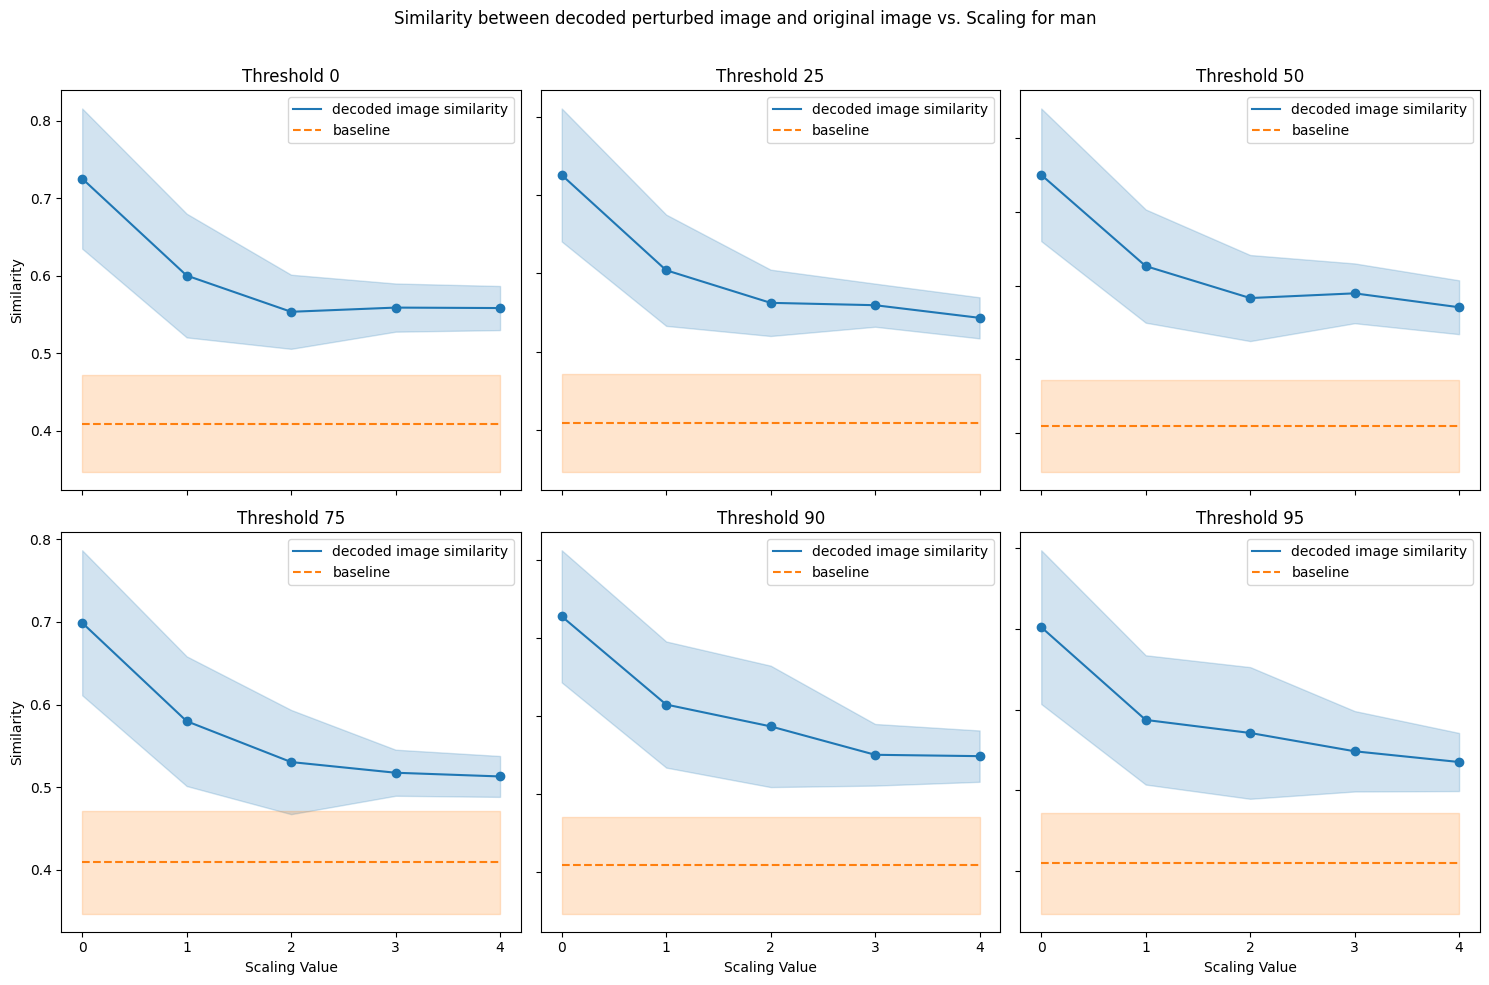

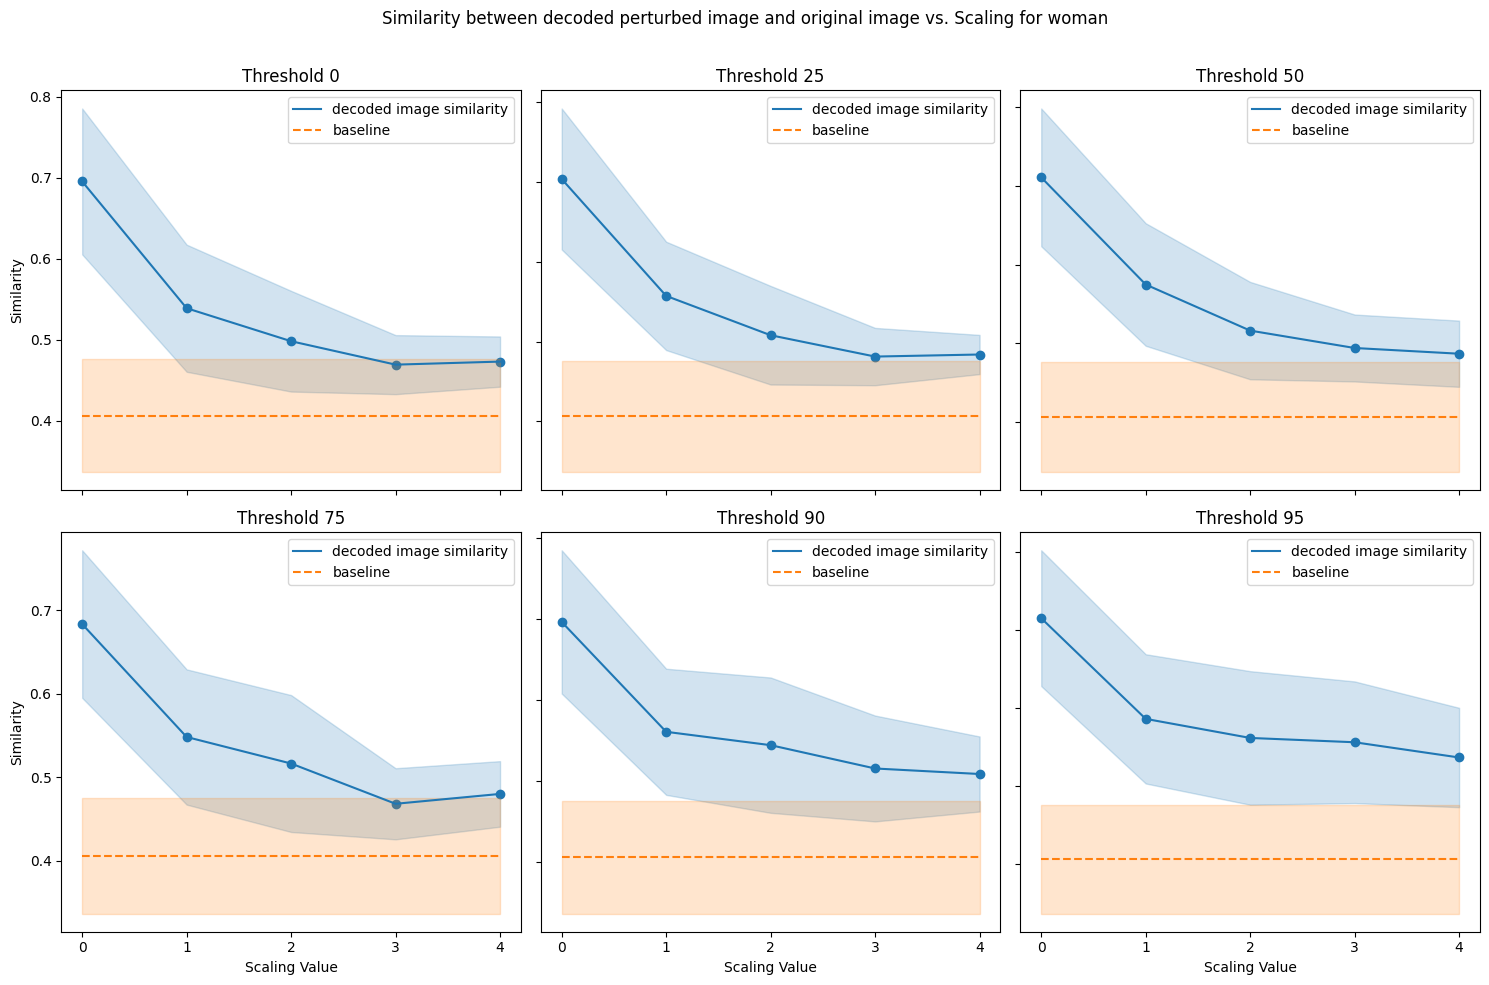

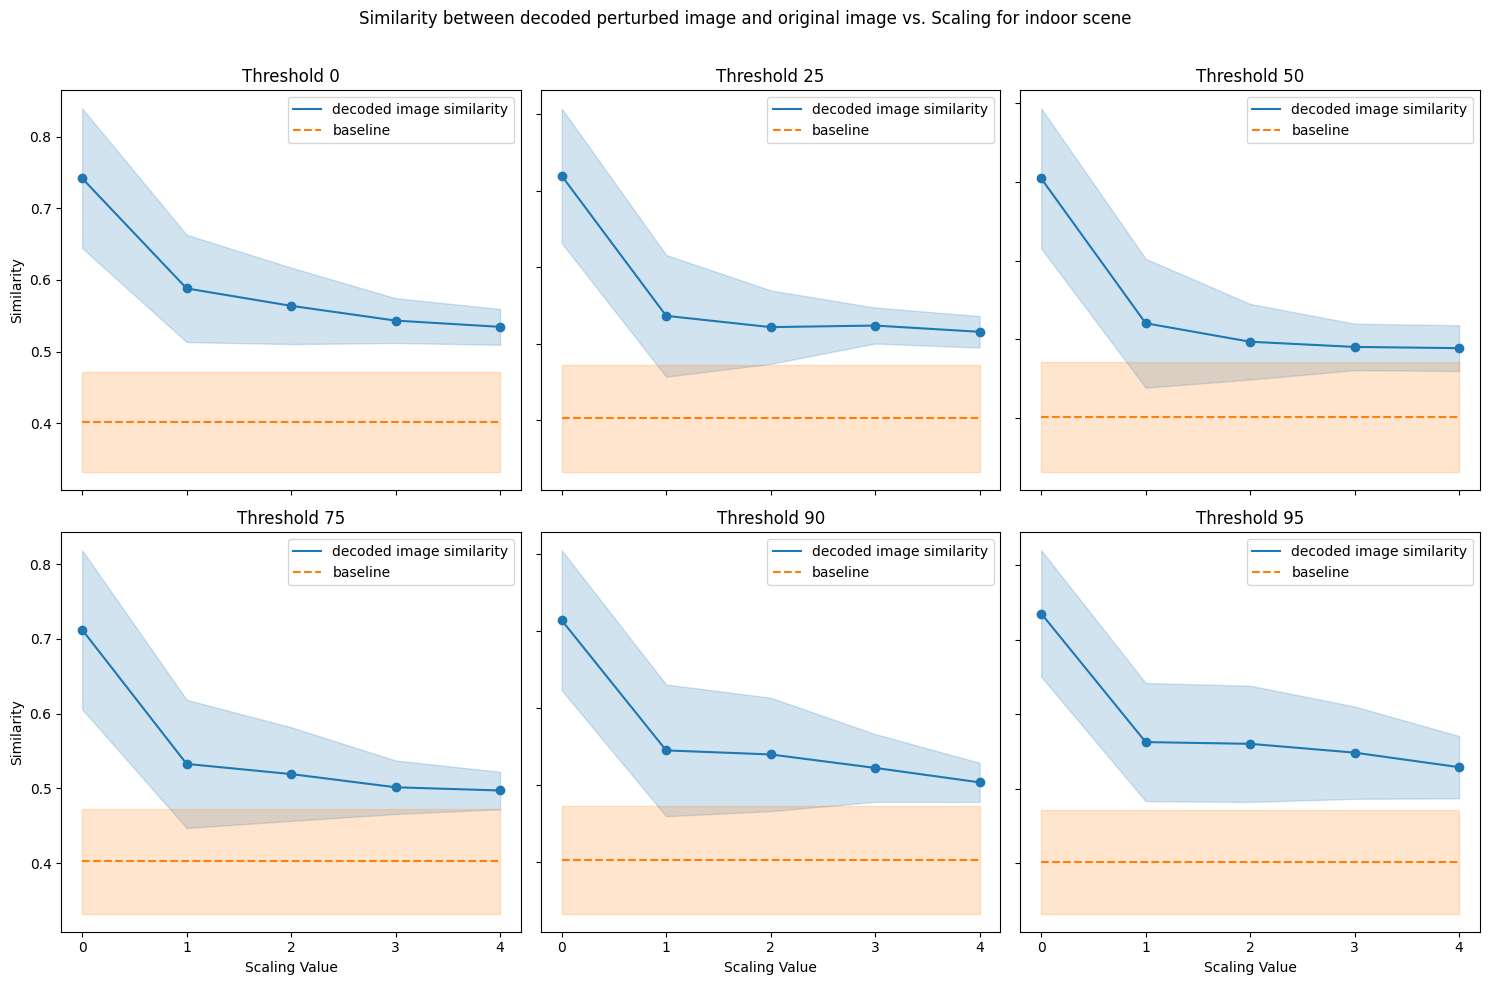

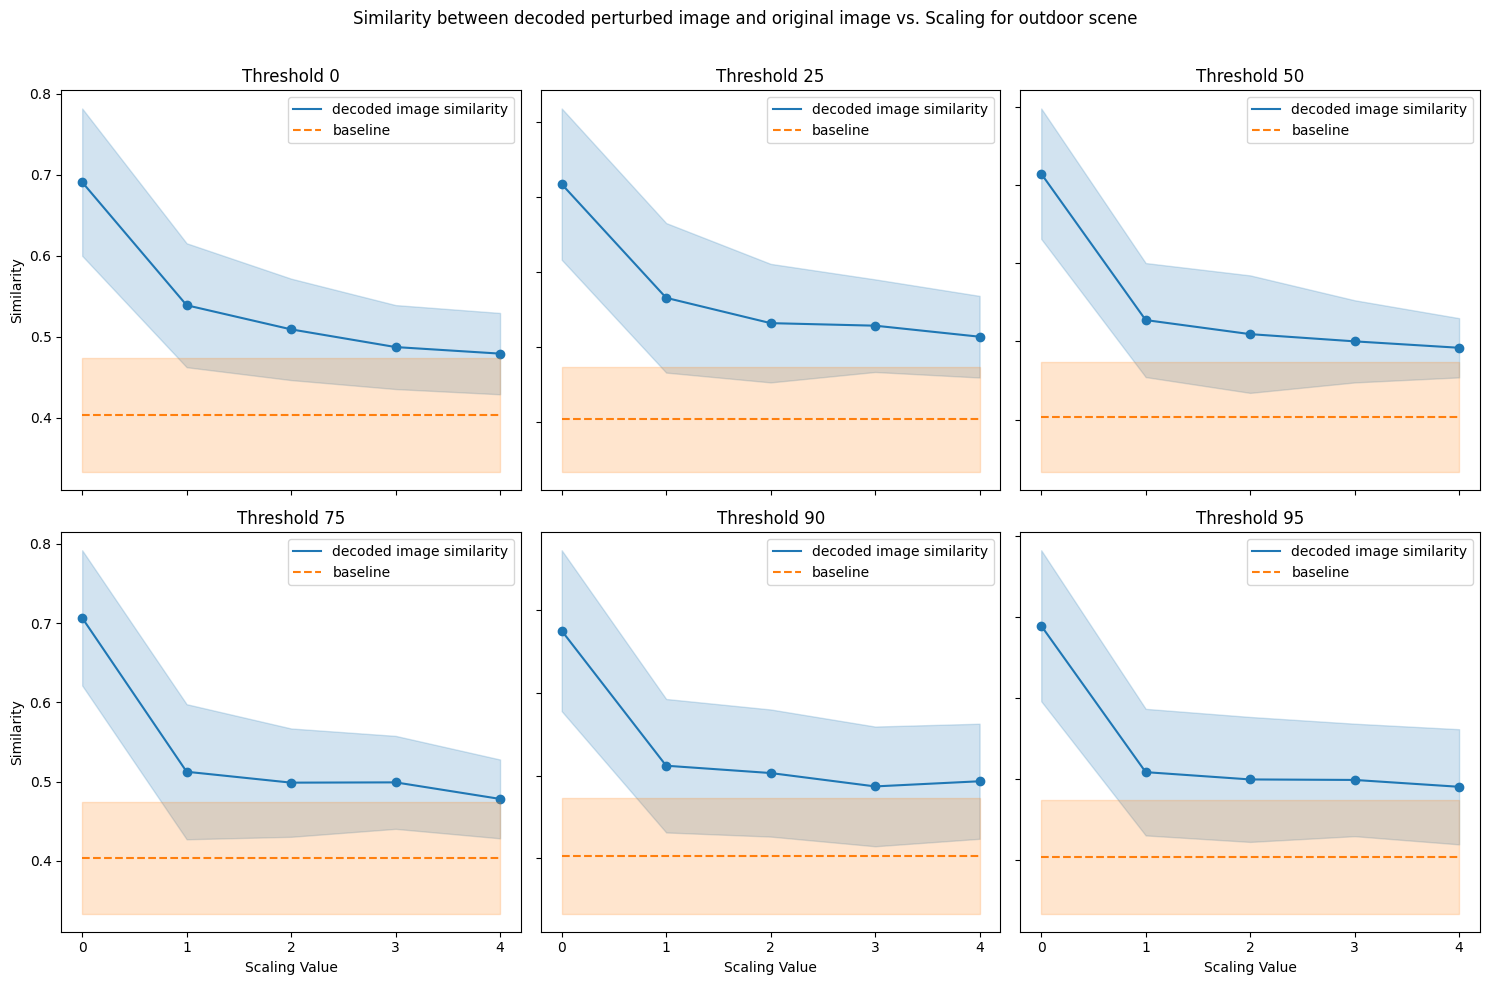

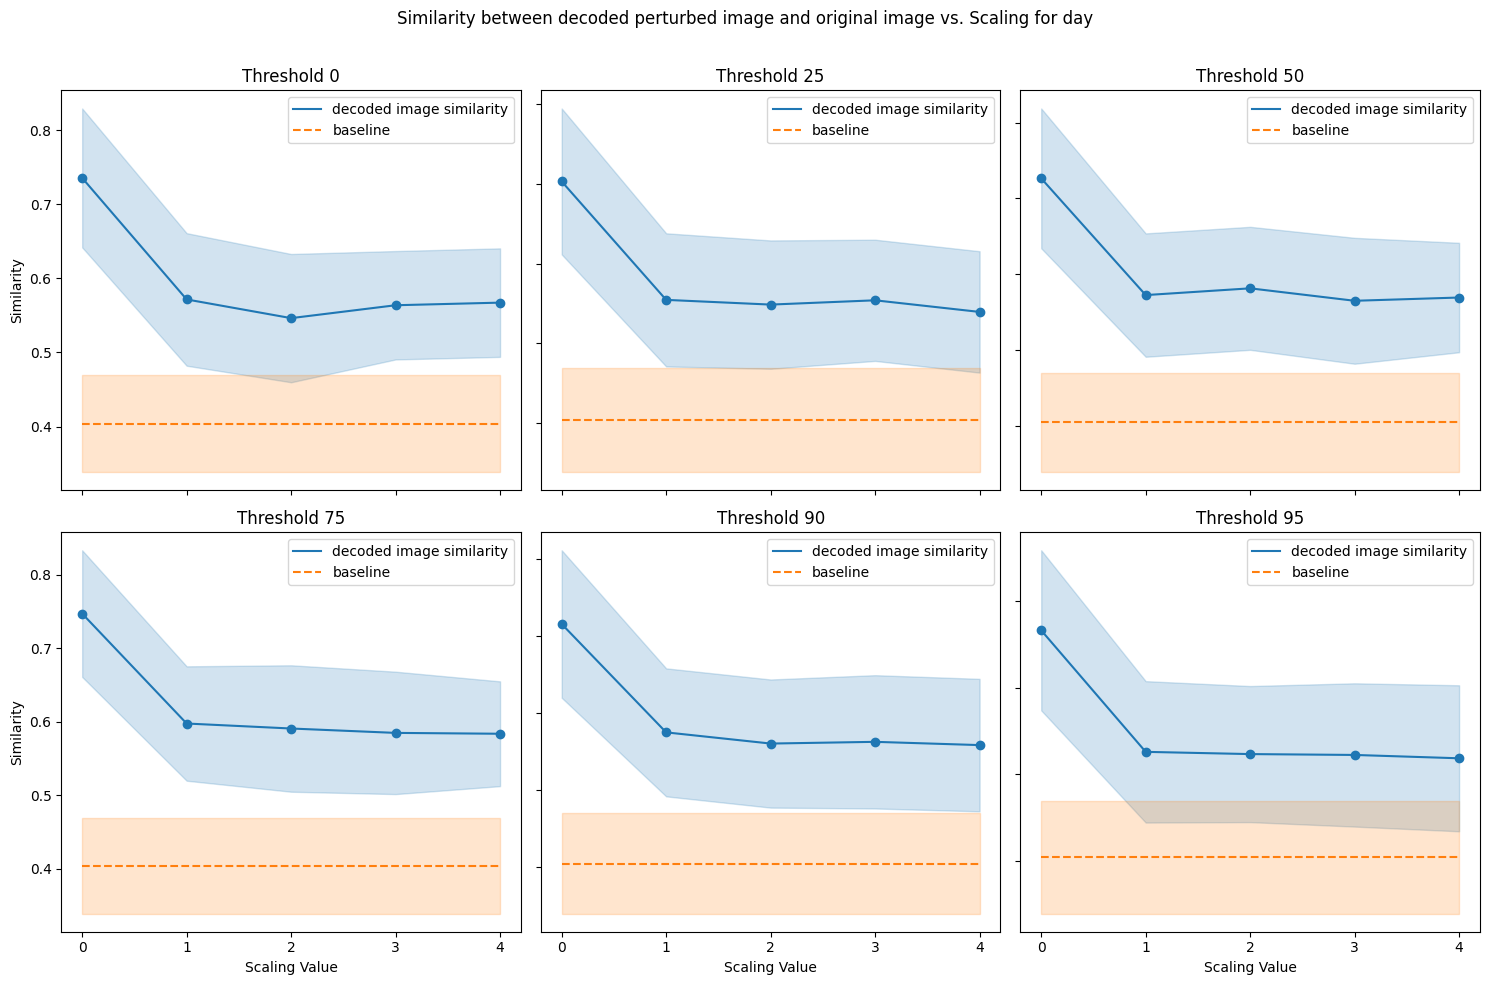

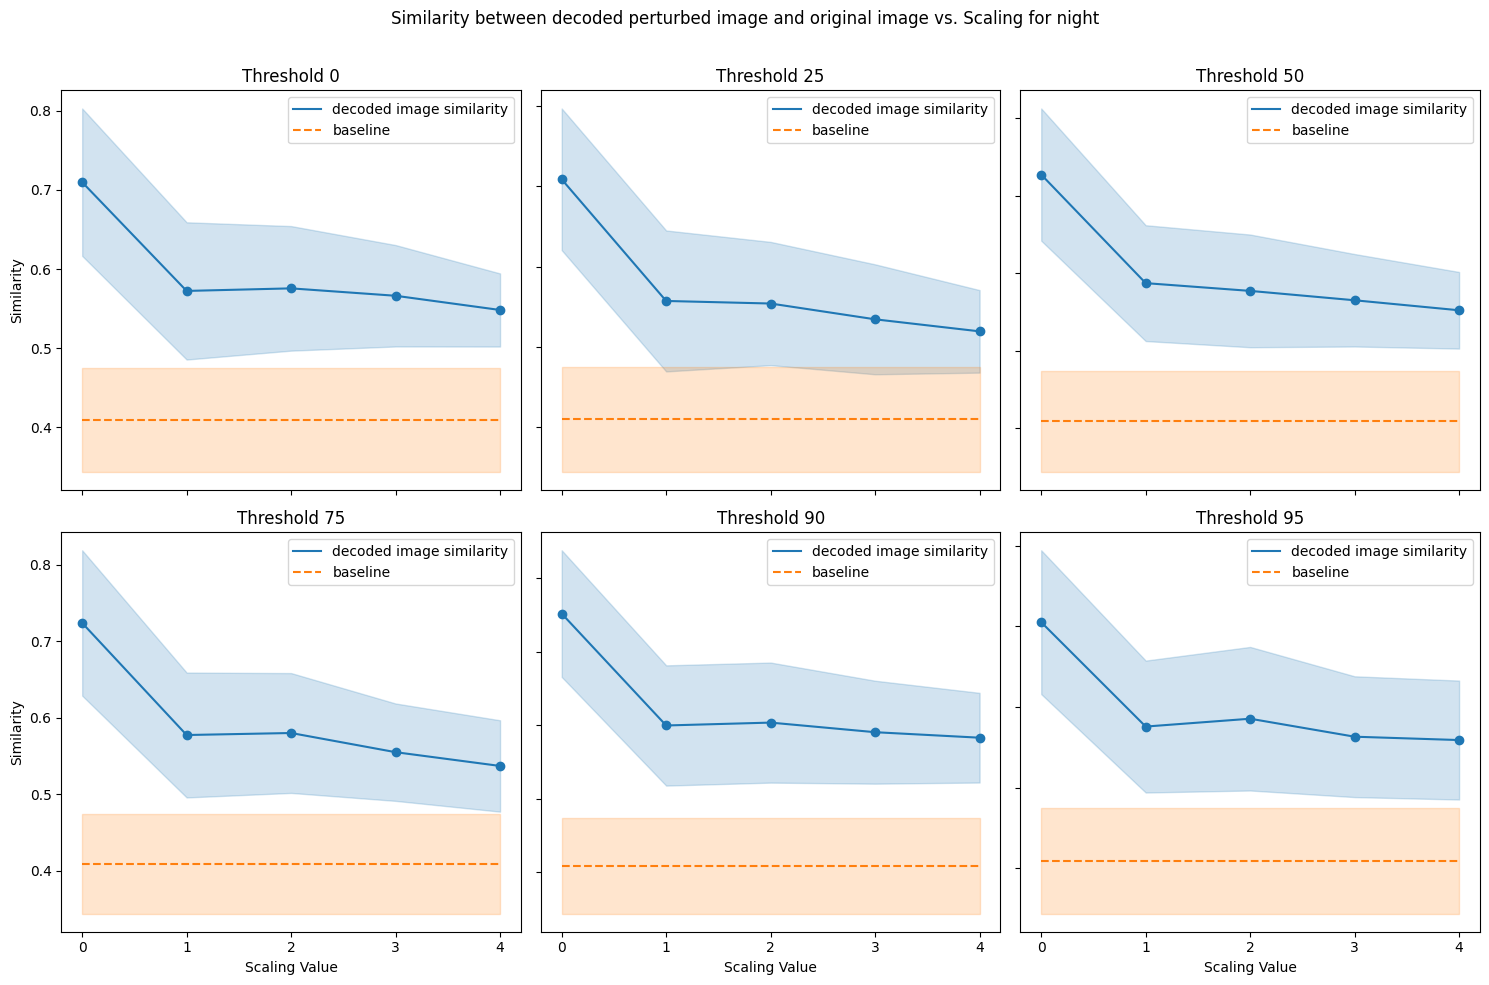

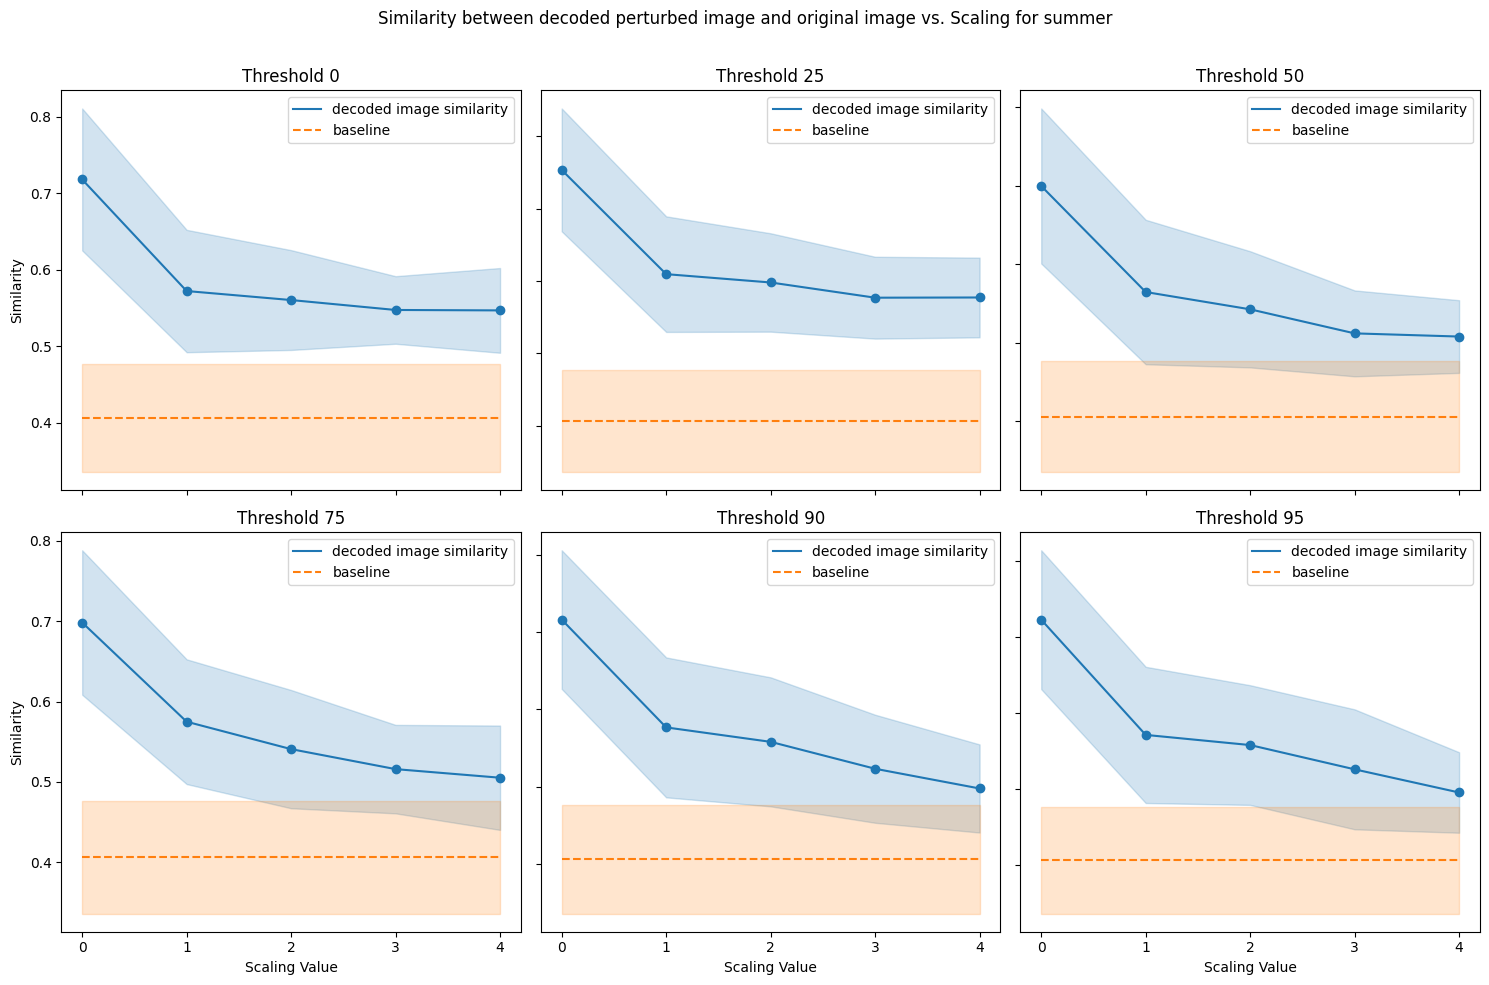

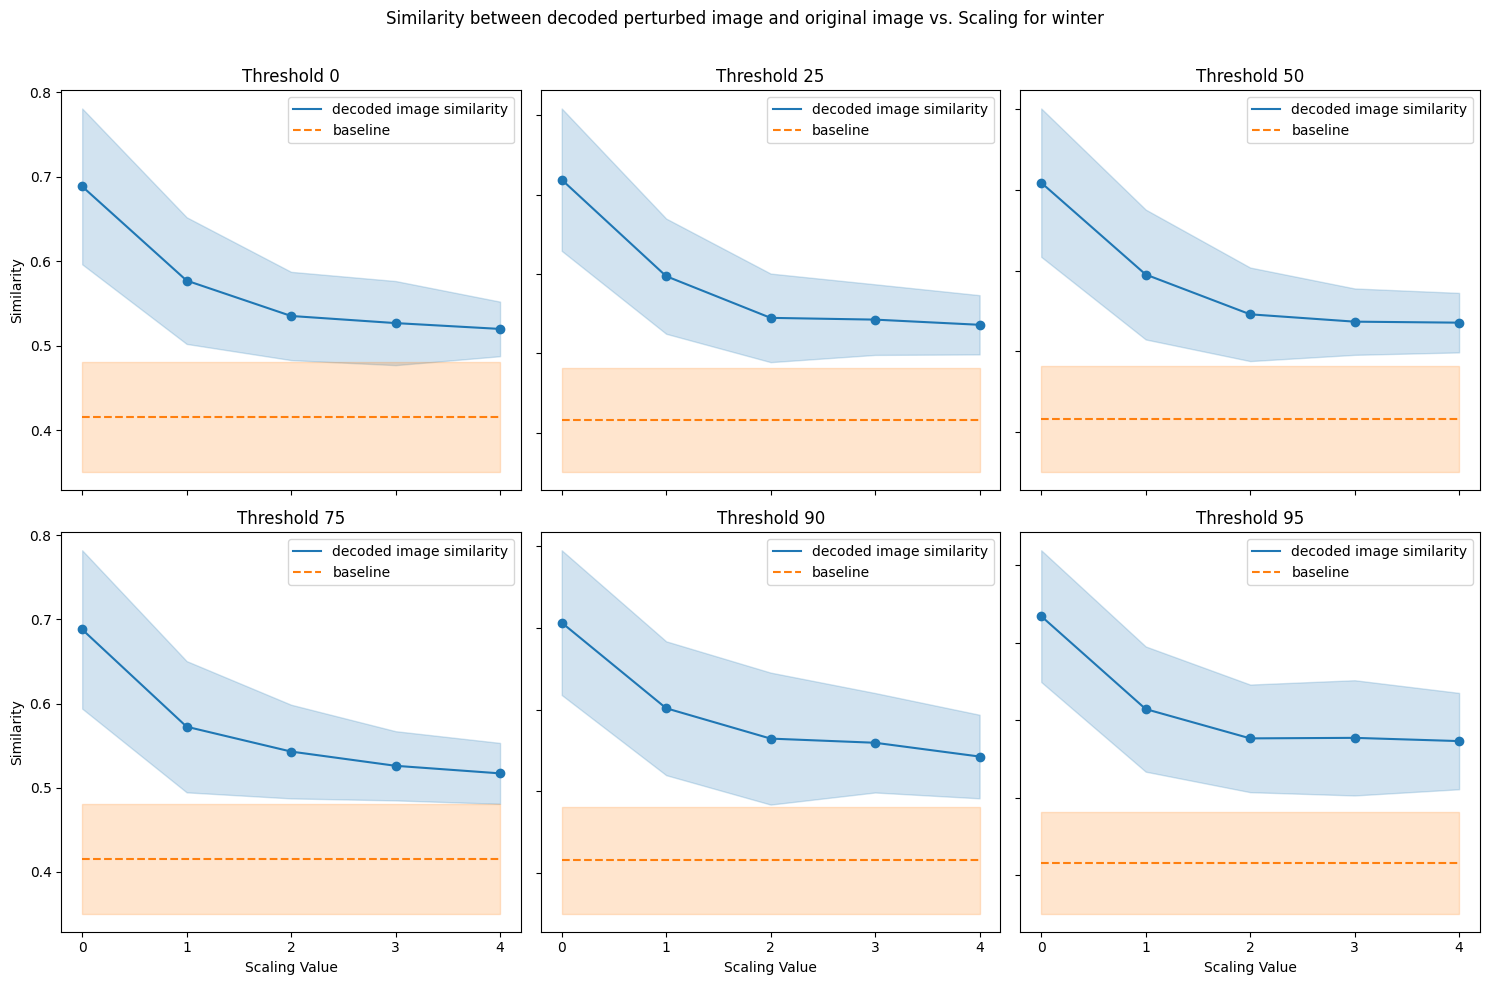

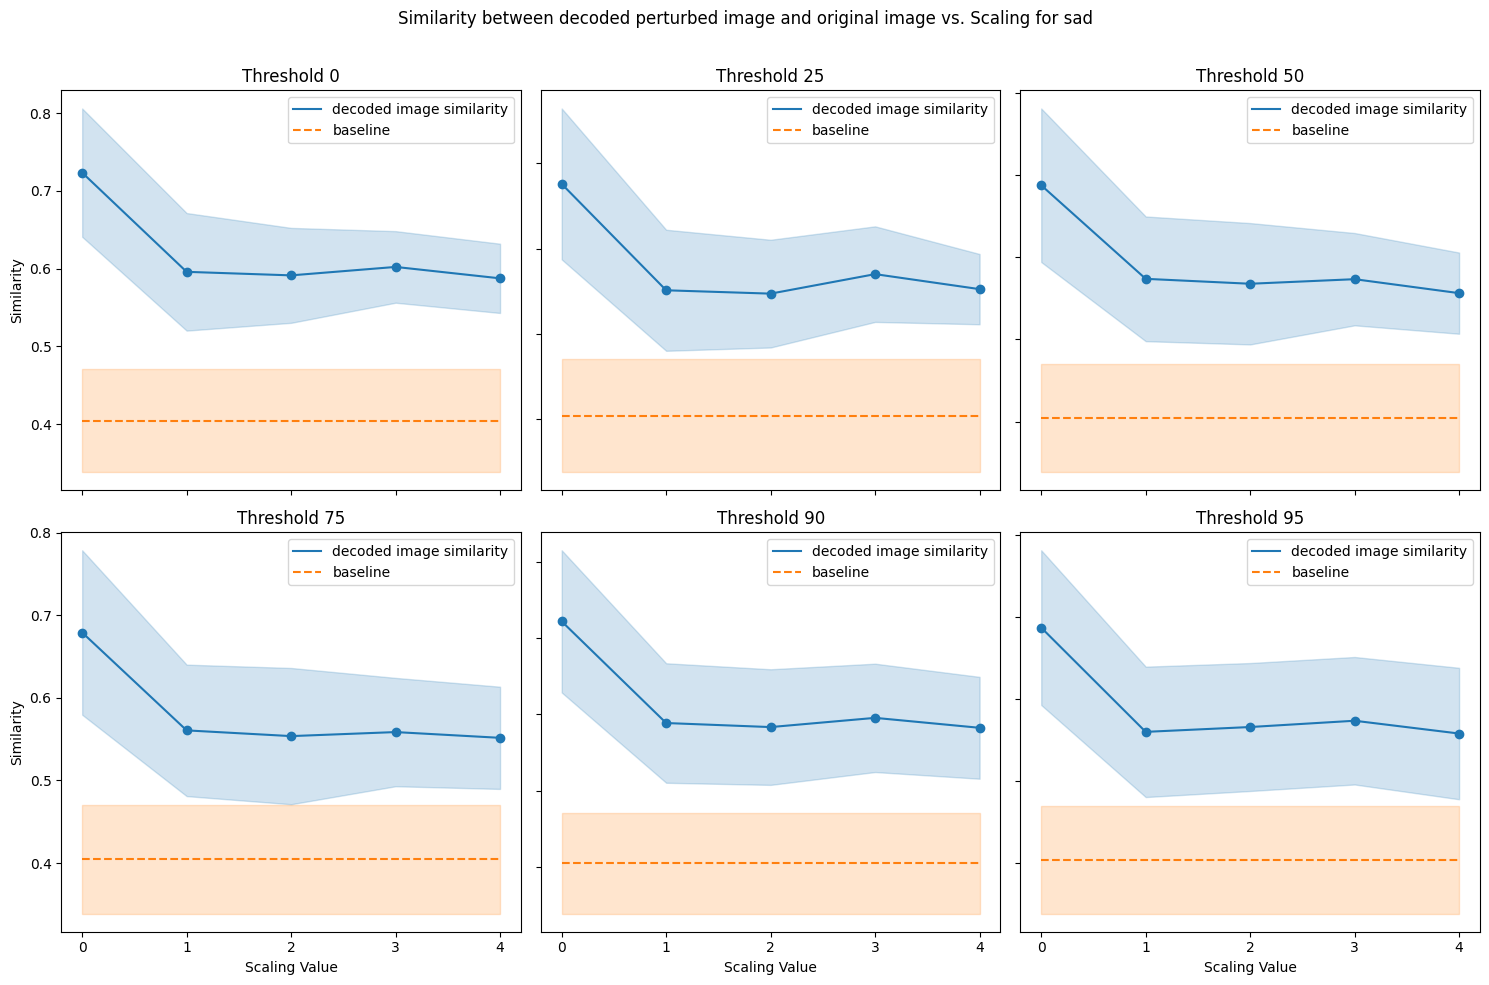

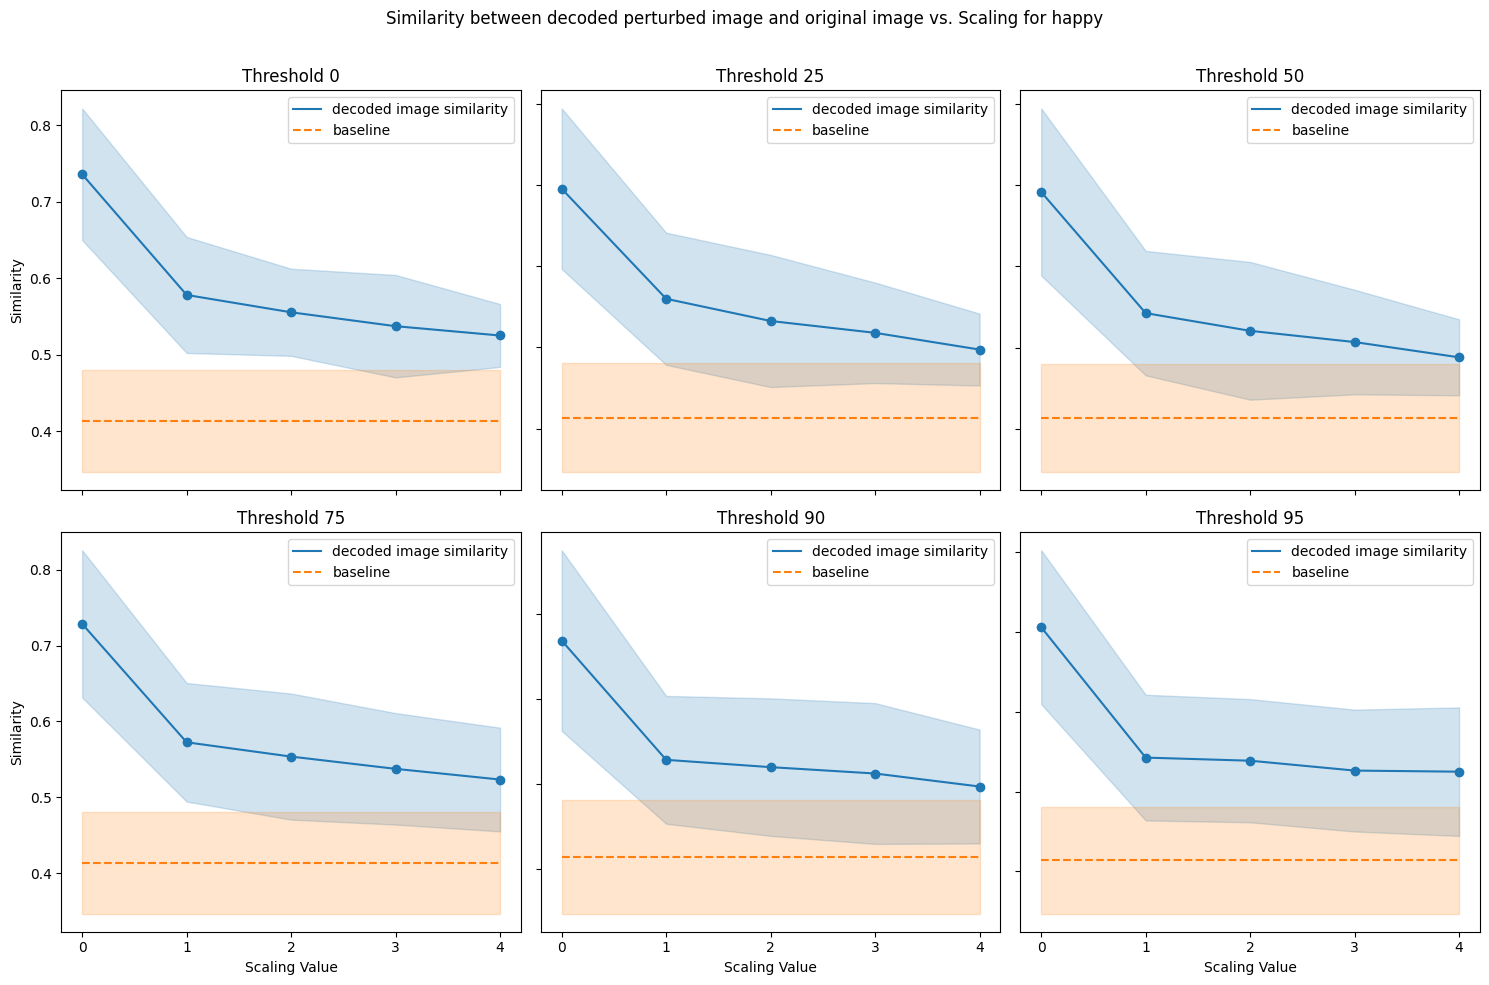

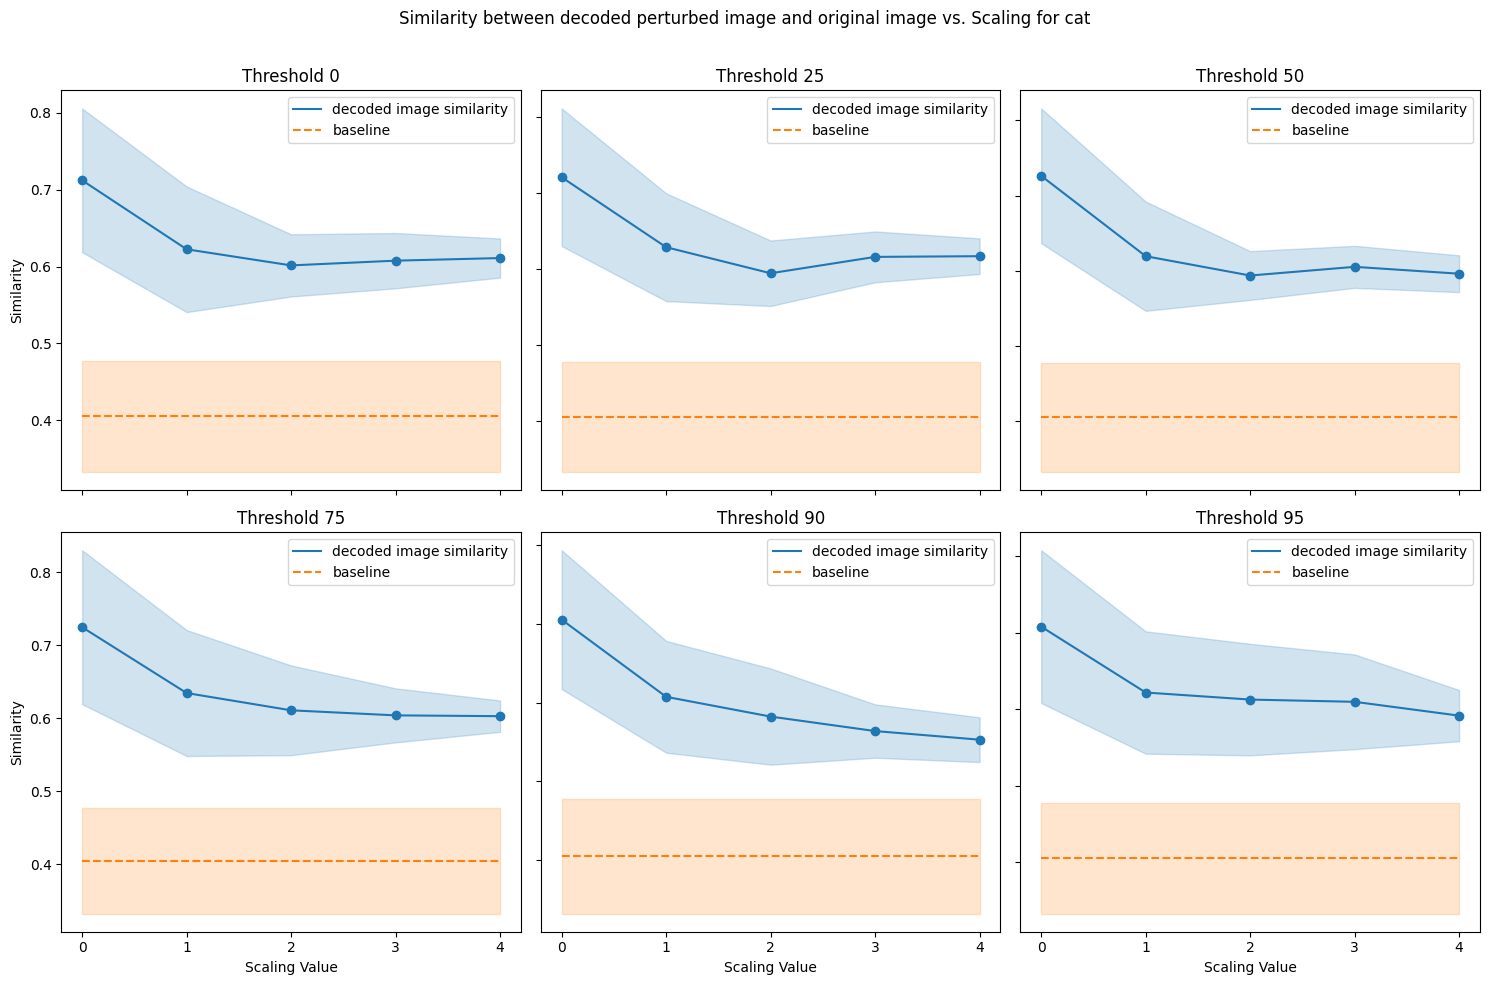

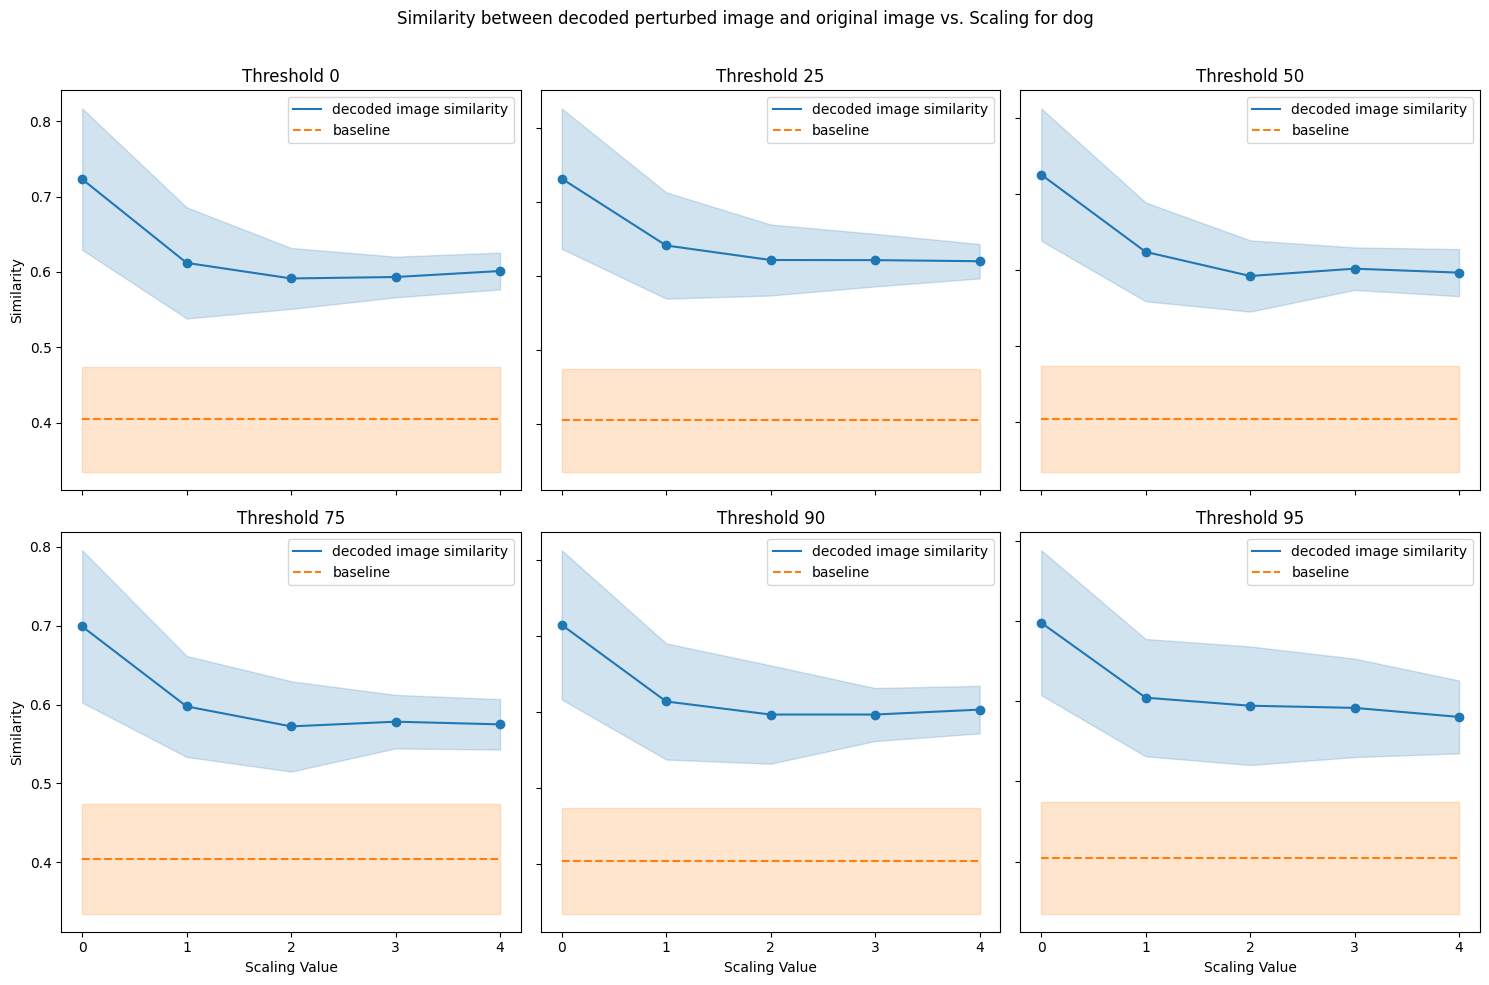

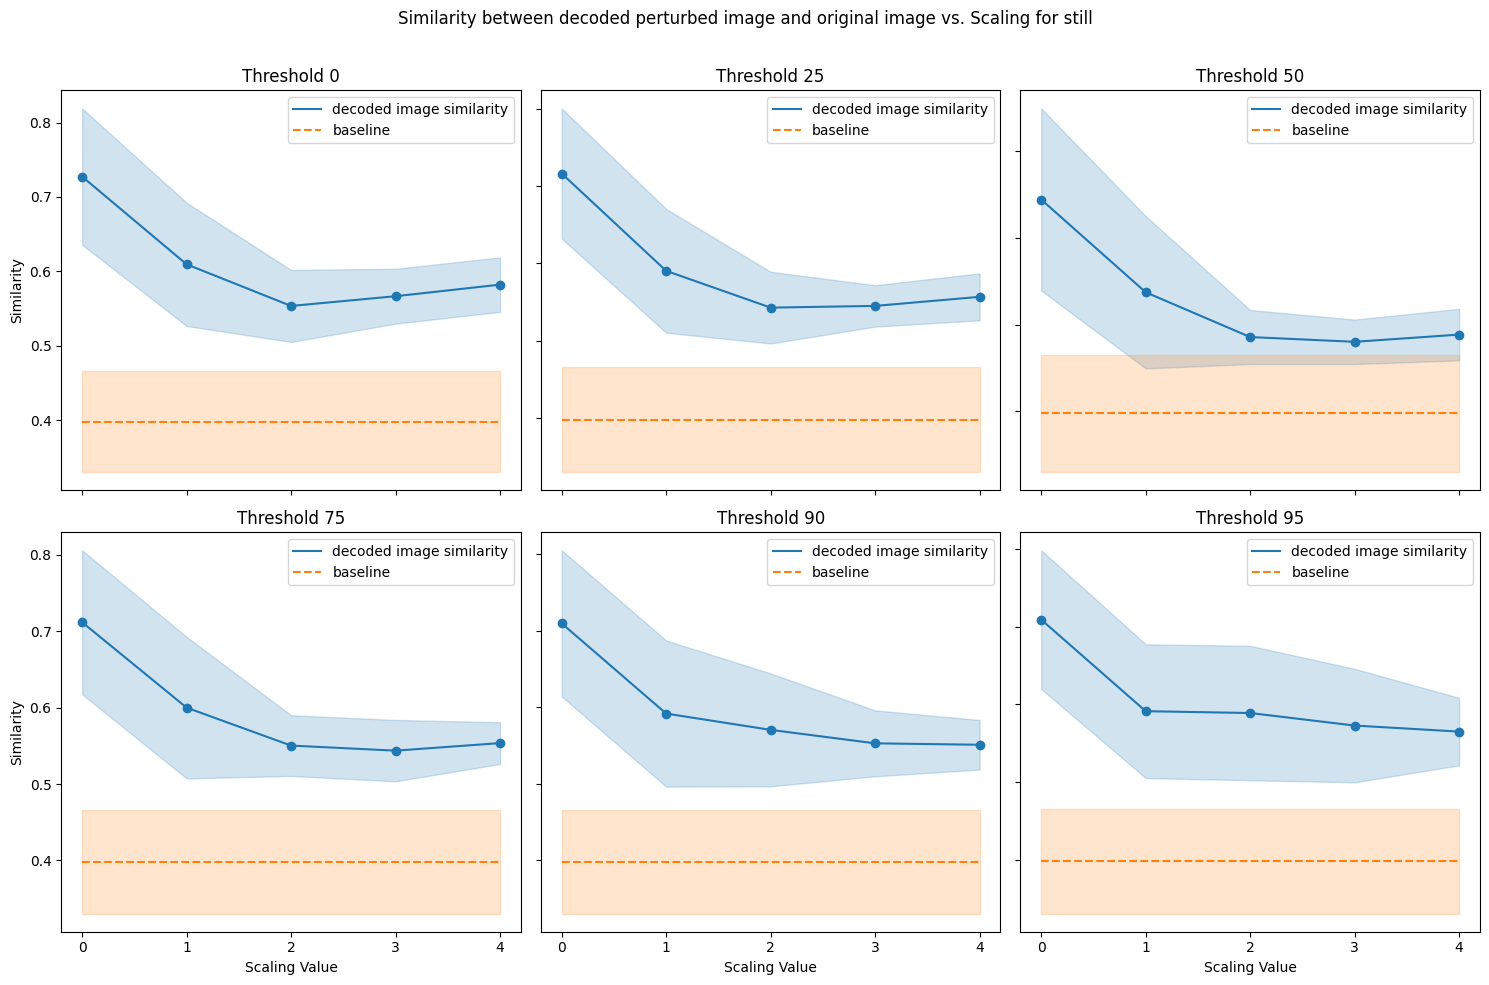

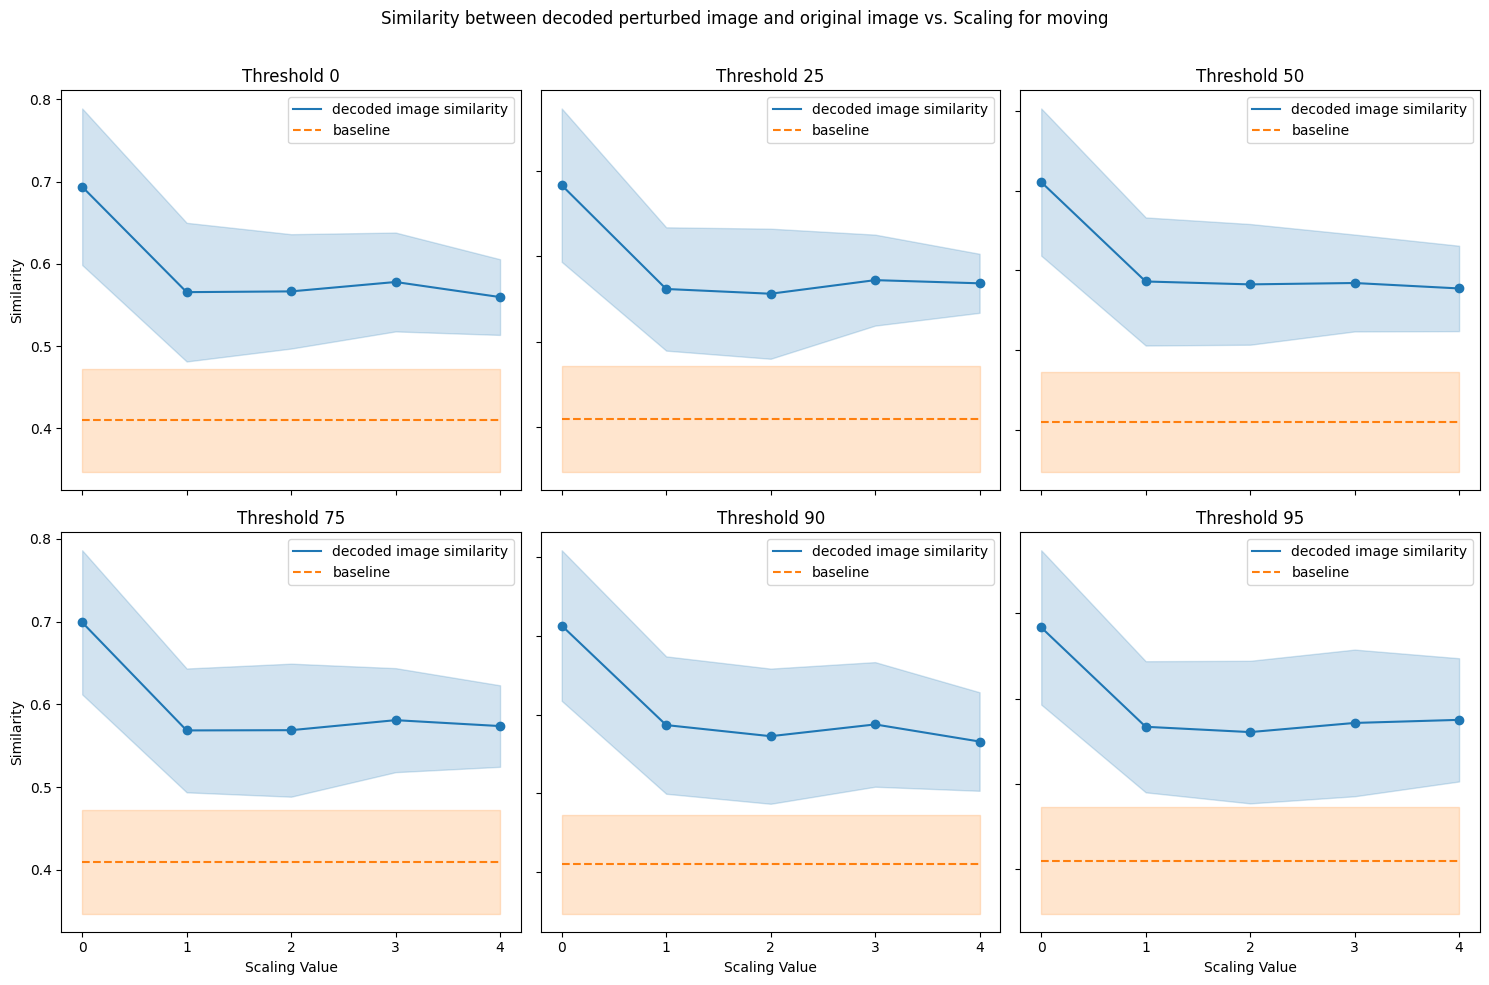

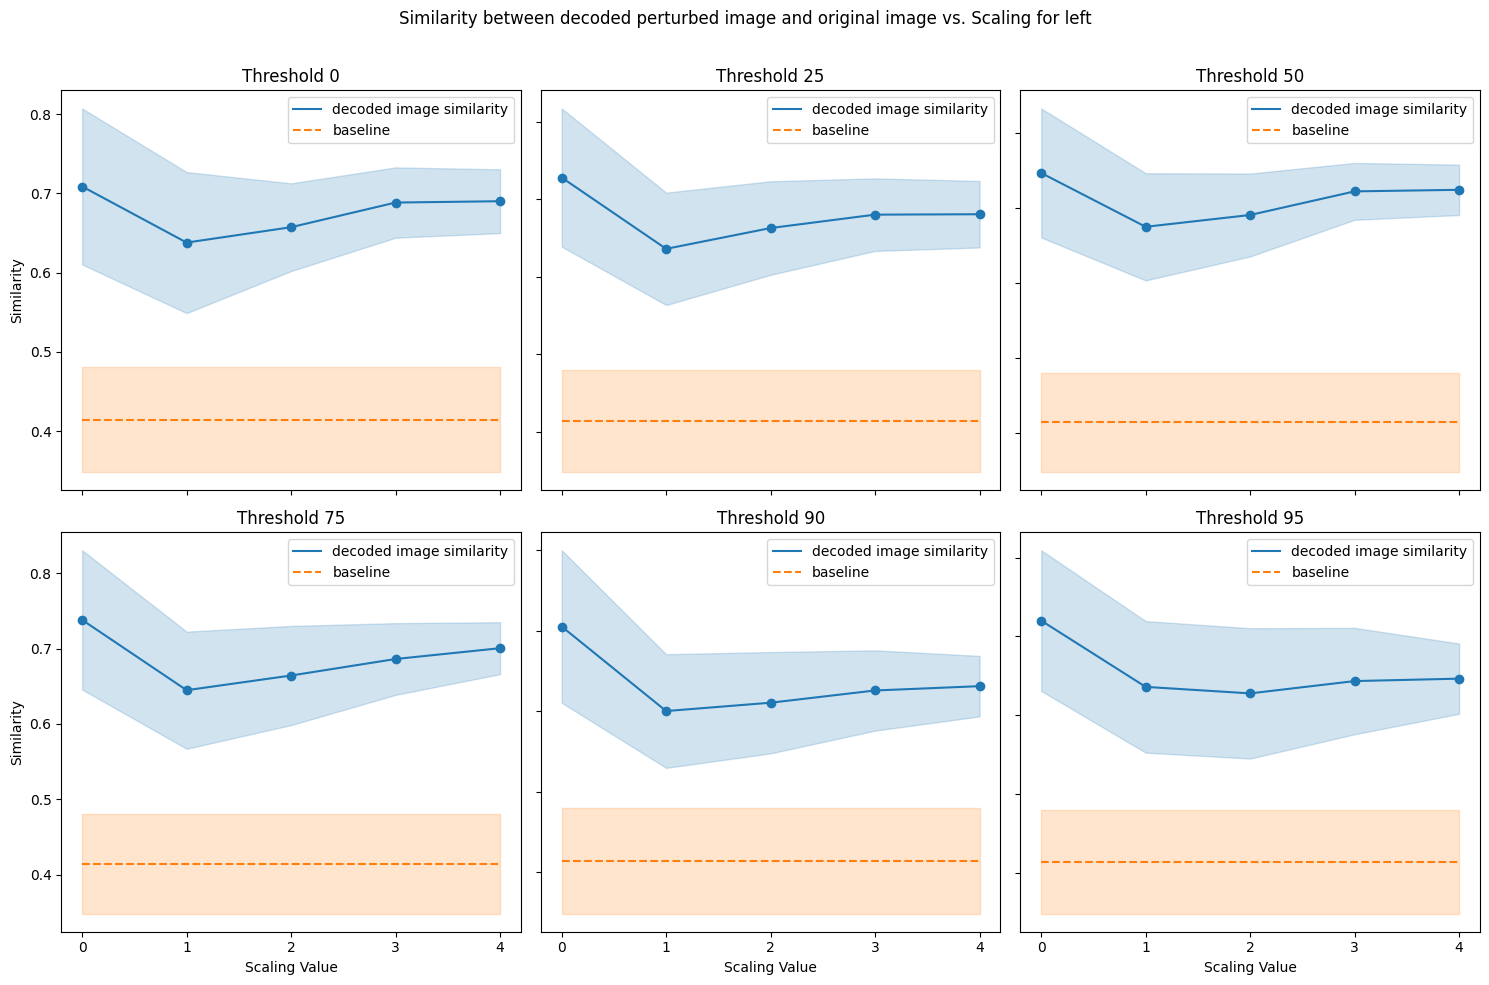

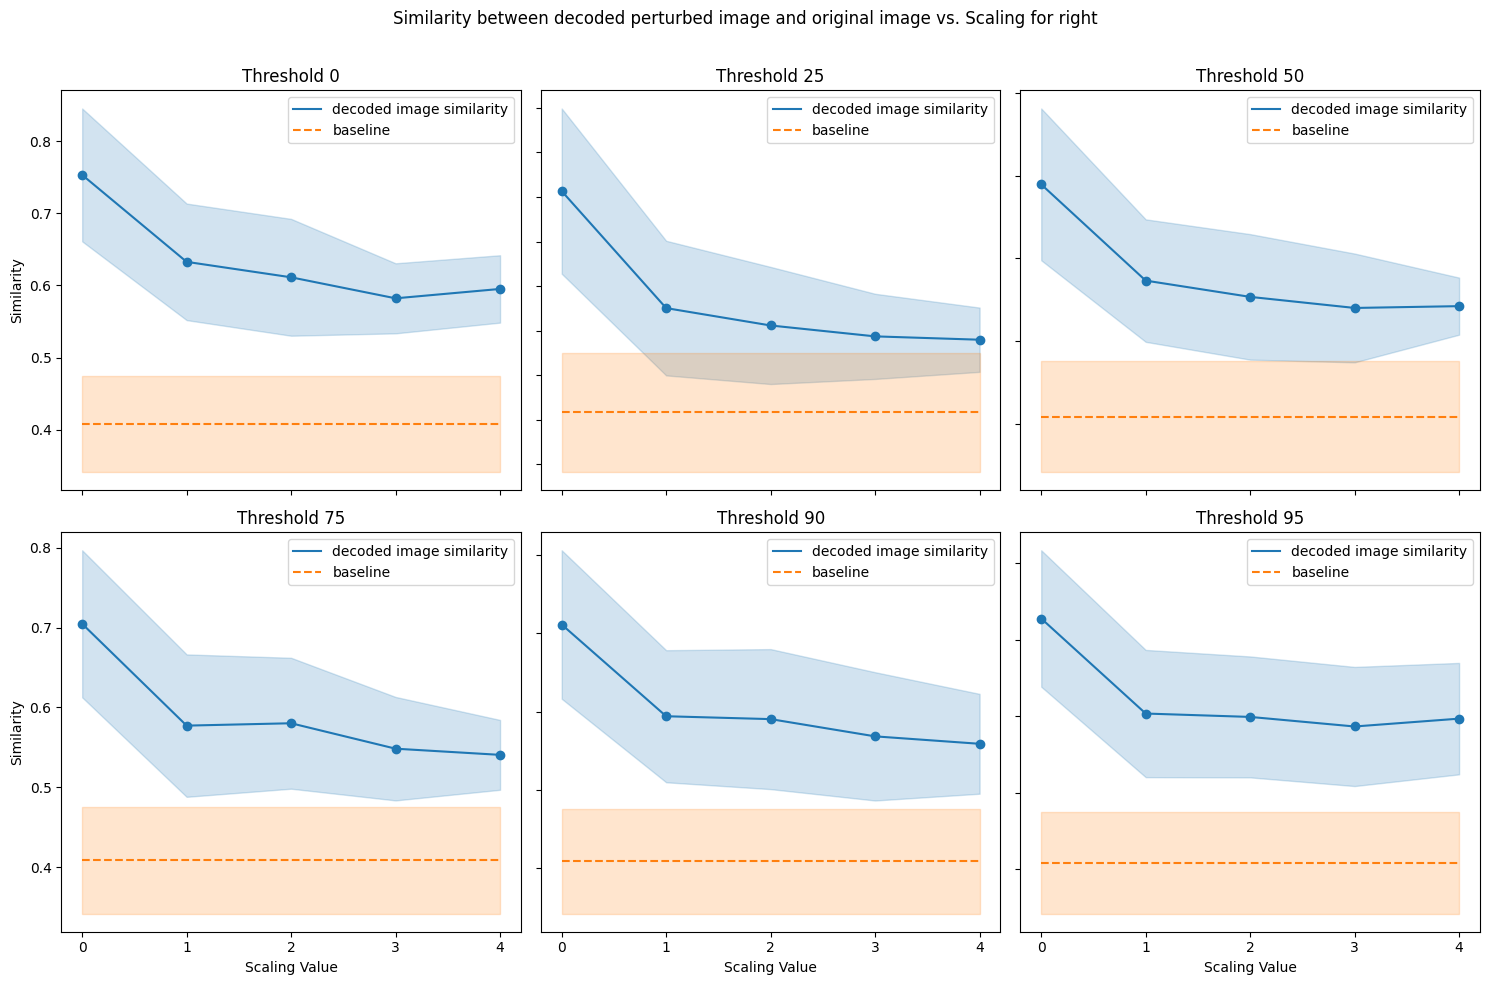

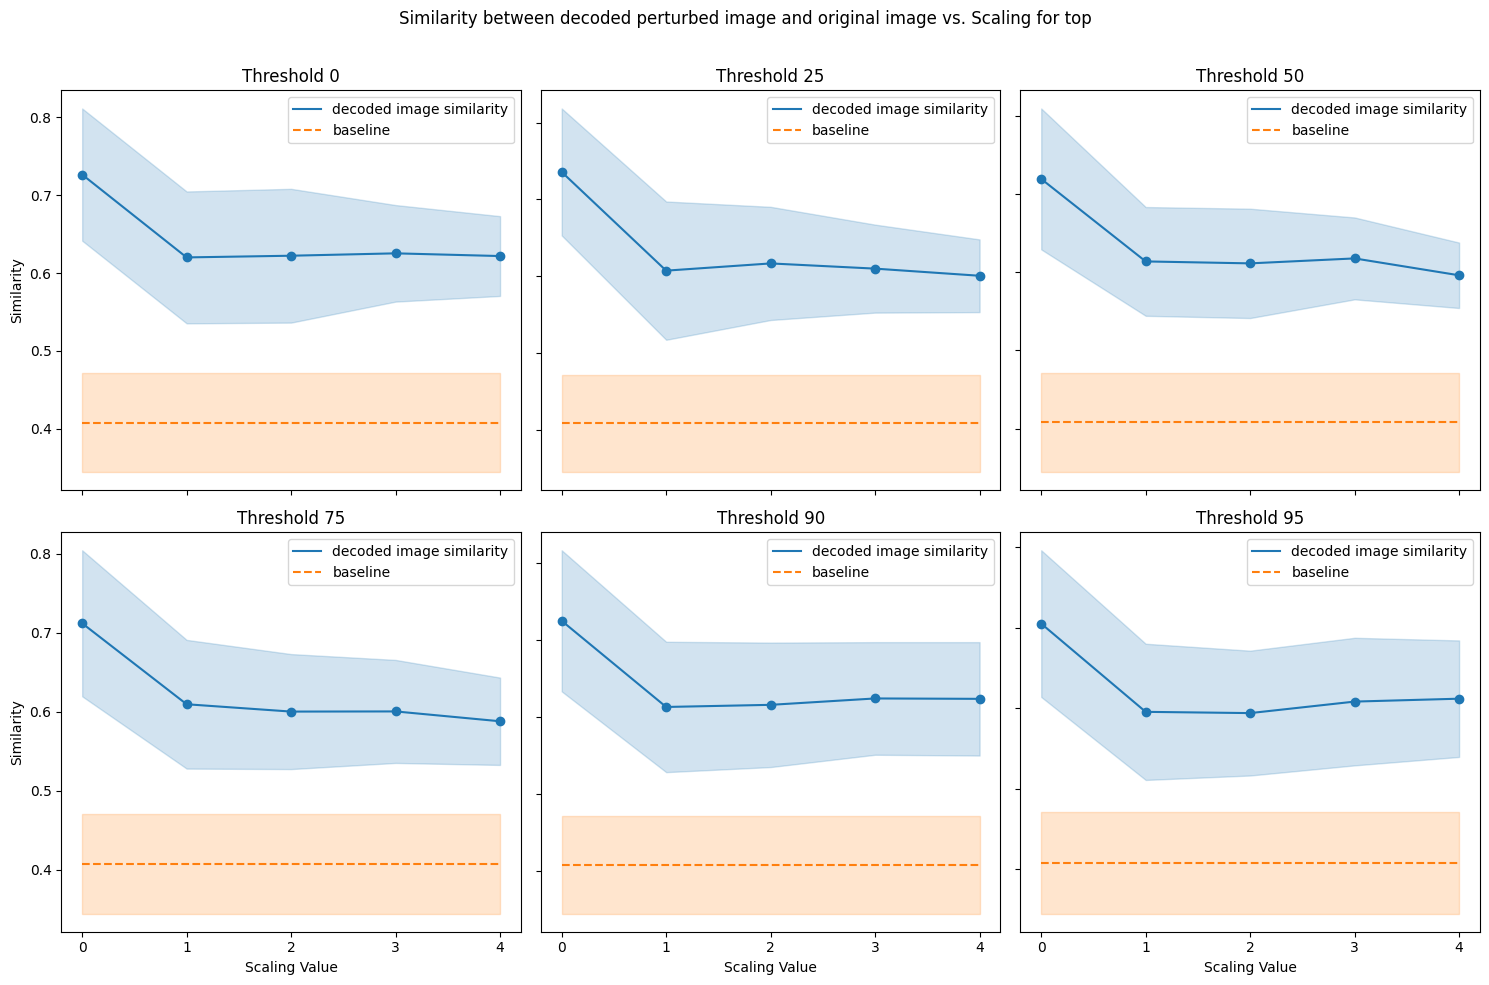

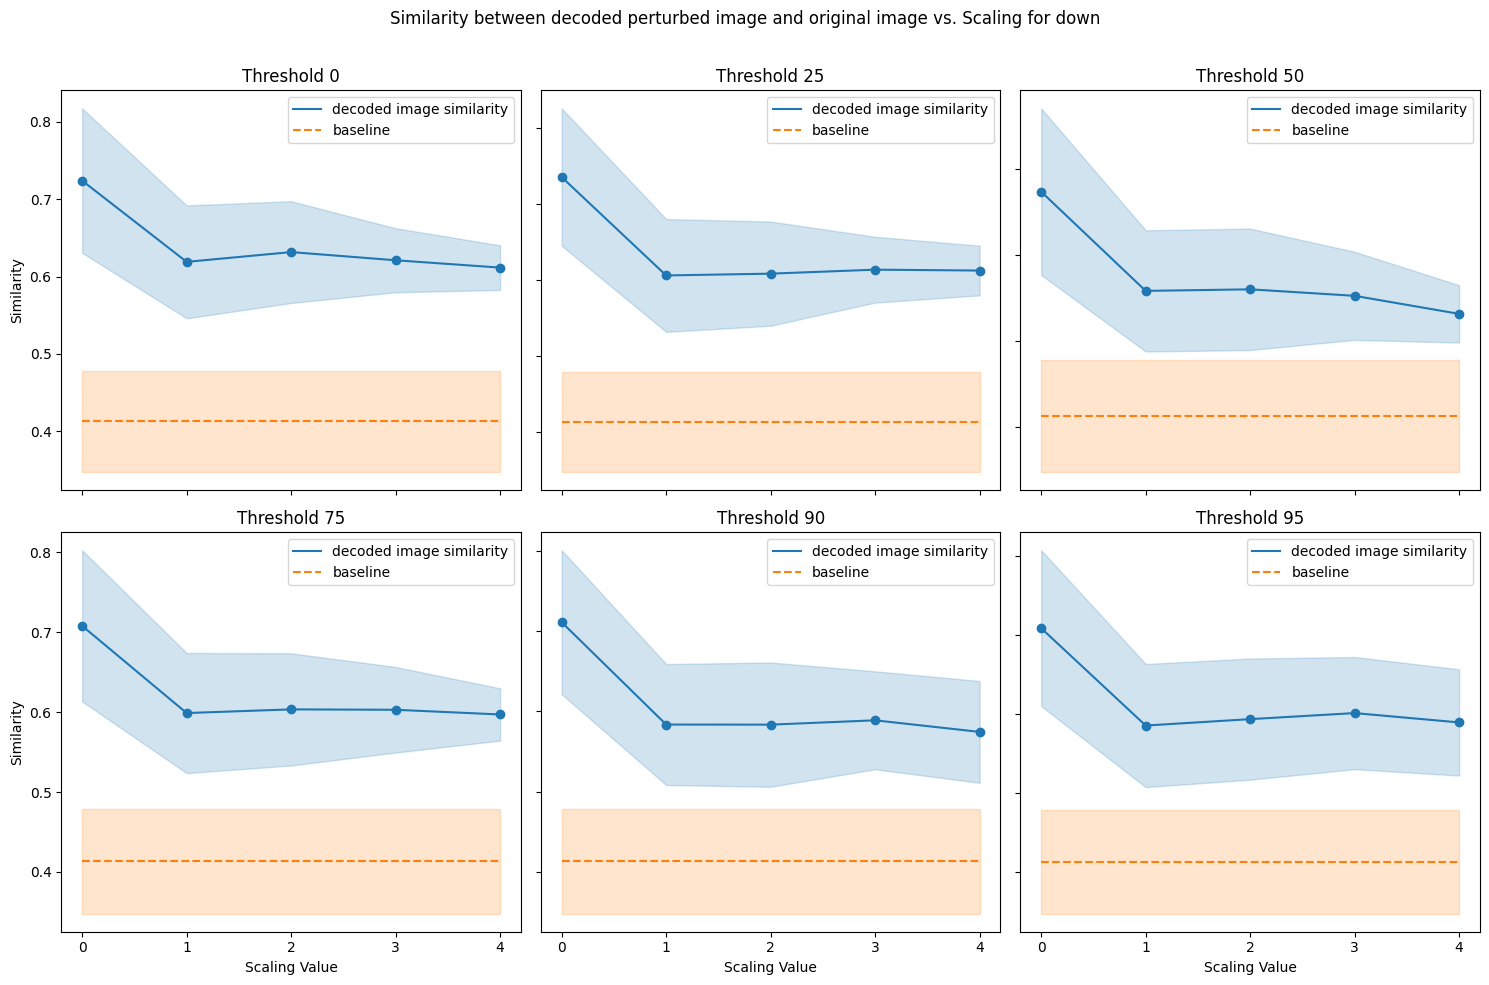

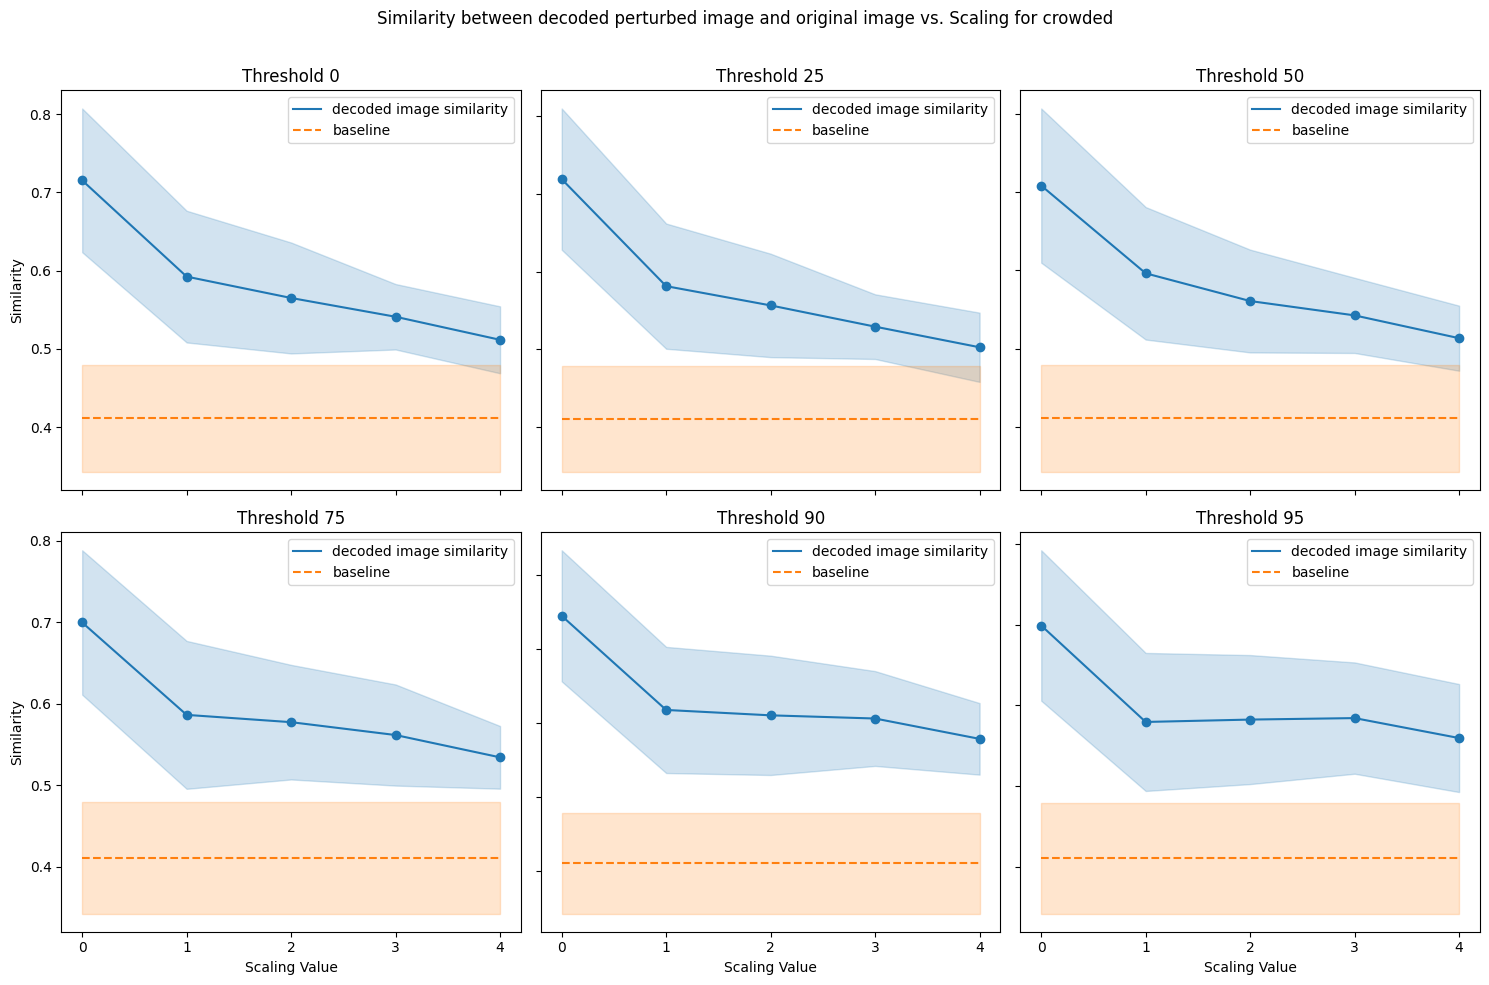

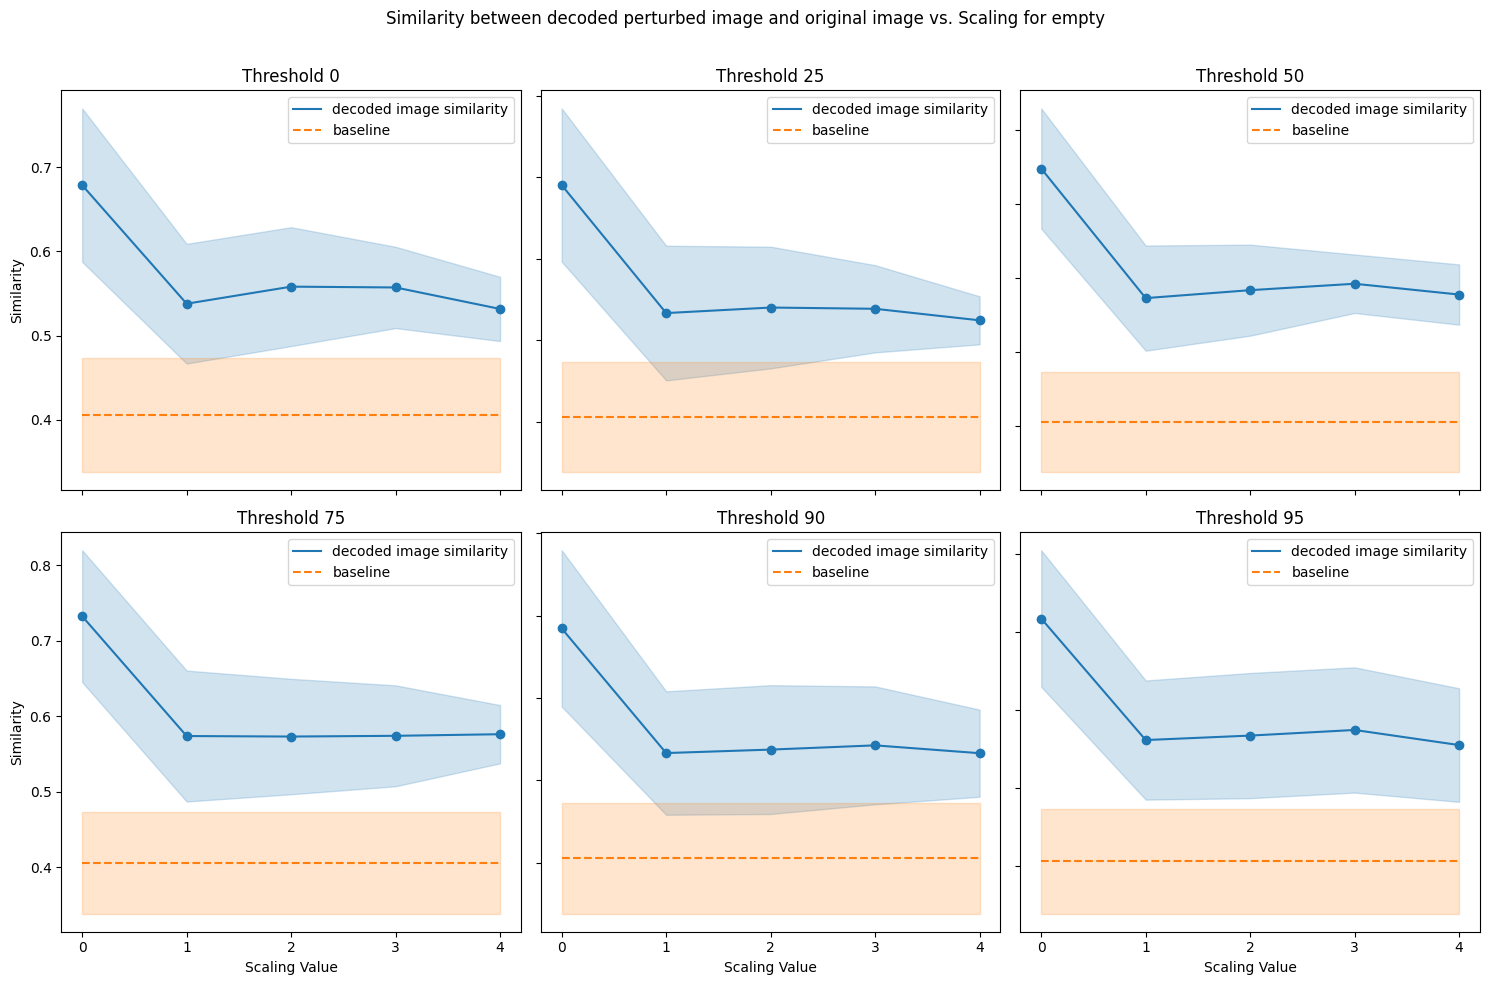

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj

# Assuming subjs is a list of subjects and all_results_sub is a dictionary containing the results for each subject

scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]

# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

# Initialize dictionaries to store results across subjects
group_y1_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y1_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Collect data across all subjects
for sub in subjs:
    all_results = all_results_sub[sub]
    
    for pair in unrolled_concepts:
        for thr in thrs:
            for key in all_keys:
                img_embeds = all_results[thr][pair][key]
                group_y1_means[thr][pair][key].append(img_embeds[:, 0].mean())
                group_y2_means[thr][pair][key].append(img_embeds[:, 1].mean())
                group_y1_stds[thr][pair][key].append(img_embeds[:, 0].std())
                group_y2_stds[thr][pair][key].append(img_embeds[:, 1].std())

# Calculate group means and average of STDs
group_means_y1 = {thr: {pair: {key: np.mean(group_y1_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_means_y2 = {thr: {pair: {key: np.mean(group_y2_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y1 = {thr: {pair: {key: np.mean(group_y1_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y2 = {thr: {pair: {key: np.mean(group_y2_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Now plot the group averages with their average standard deviations
for pair in unrolled_concepts:
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}")

    for idx, thr in enumerate(thrs):
        row = idx // n_cols
        col = idx % n_cols

        y1_means = [group_means_y1[thr][pair][key] for key in all_keys]
        y2_means = [group_means_y2[thr][pair][key] for key in all_keys]
        y1_avg_stds = [average_stds_y1[thr][pair][key] for key in all_keys]
        y2_avg_stds = [average_stds_y2[thr][pair][key] for key in all_keys]

        axs[row, col].plot(scaling_values, y2_means, label=f"decoded image similarity")
        axs[row, col].scatter(scaling_values, y2_means)
        axs[row, col].fill_between(scaling_values, 
                                   np.array(y2_means) - np.array(y2_avg_stds), 
                                   np.array(y2_means) + np.array(y2_avg_stds), alpha=0.2,color="tab:blue")
        axs[row,col].set_xticks(scaling_values)
        
        axs[row,col].hlines(baselines[pair]["baseline_img_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:orange",label="baseline")
        axs[row, col].fill_between(x=scaling_values, y1=baselines[pair]["baseline_img_similarities_mean"].mean()-baselines[pair]["baseline_img_similarities_std"].mean(), 
                                   y2=baselines[pair]["baseline_img_similarities_mean"].mean()+baselines[pair]["baseline_img_similarities_std"].mean(),color="tab:orange",alpha=0.2)

        axs[row, col].set_ylabel("Similarity")
        axs[row, col].set_title(f"Threshold {thr}")
        axs[row, col].legend()



    # Set common x-axis label
    for ax in axs.flat:
        ax.label_outer()  # Hide inner labels to avoid clutter

    axs[-1, 0].set_xlabel("Scaling Value")
    axs[-1, 1].set_xlabel("Scaling Value")
    axs[-1, 2].set_xlabel("Scaling Value")
    
#     plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
#     plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}.png"))
#     plt.show()

    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
    plt.savefig(opj("results_group", f"Group Similarity between decoded perturbed image and original image vs. Scaling for {pair}.png"))
    plt.show()


## GROUP - Similarity with concept

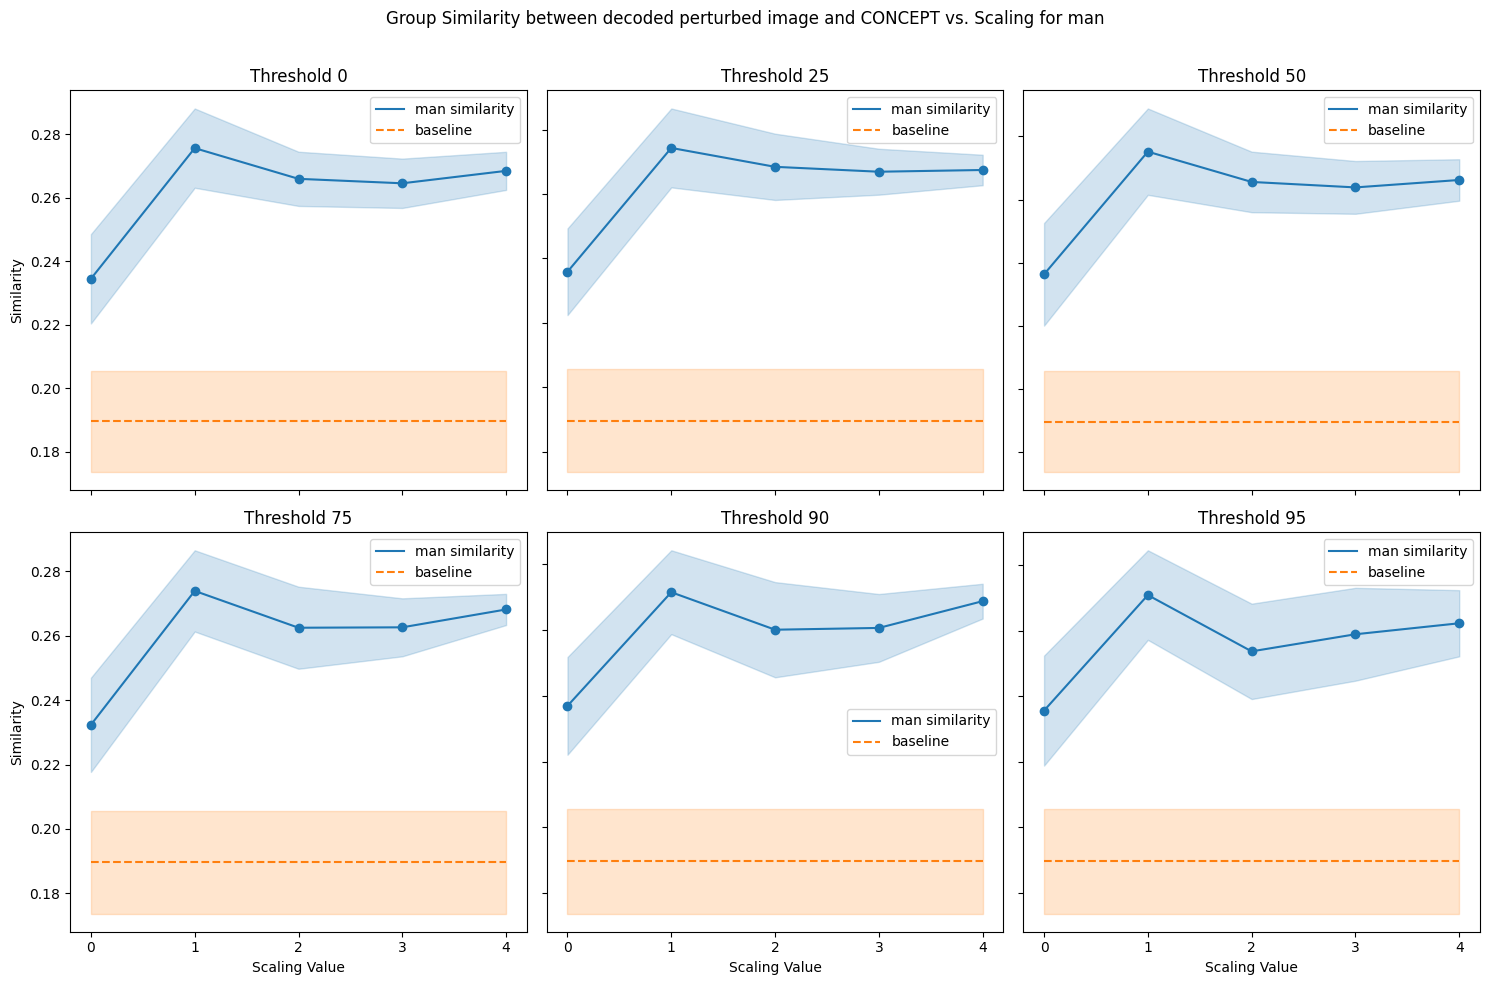

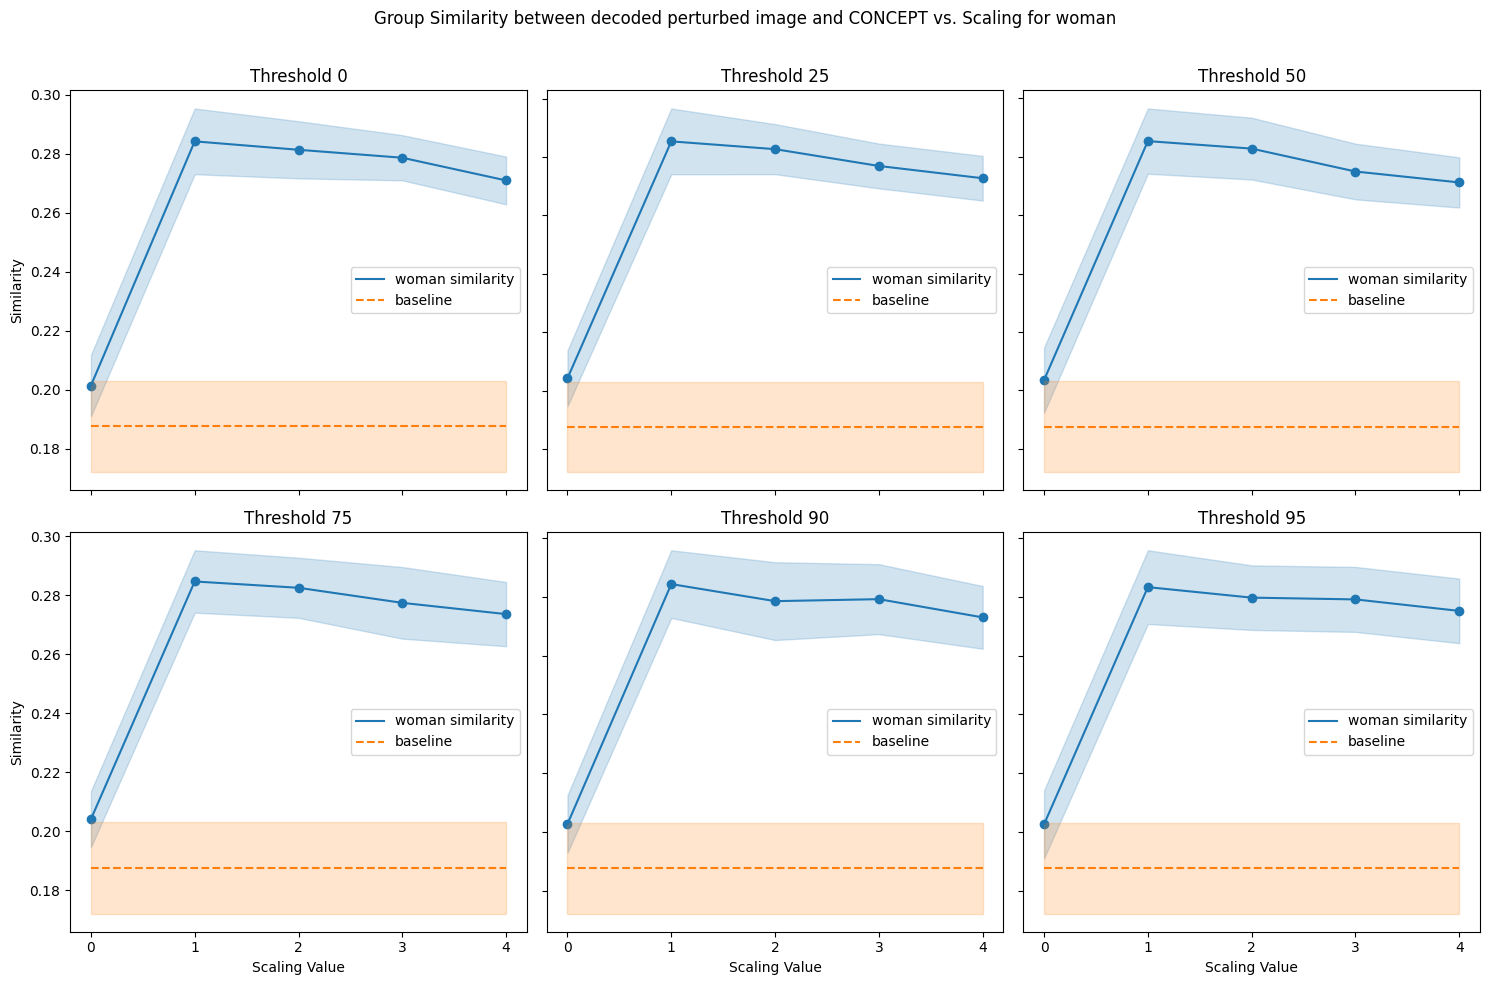

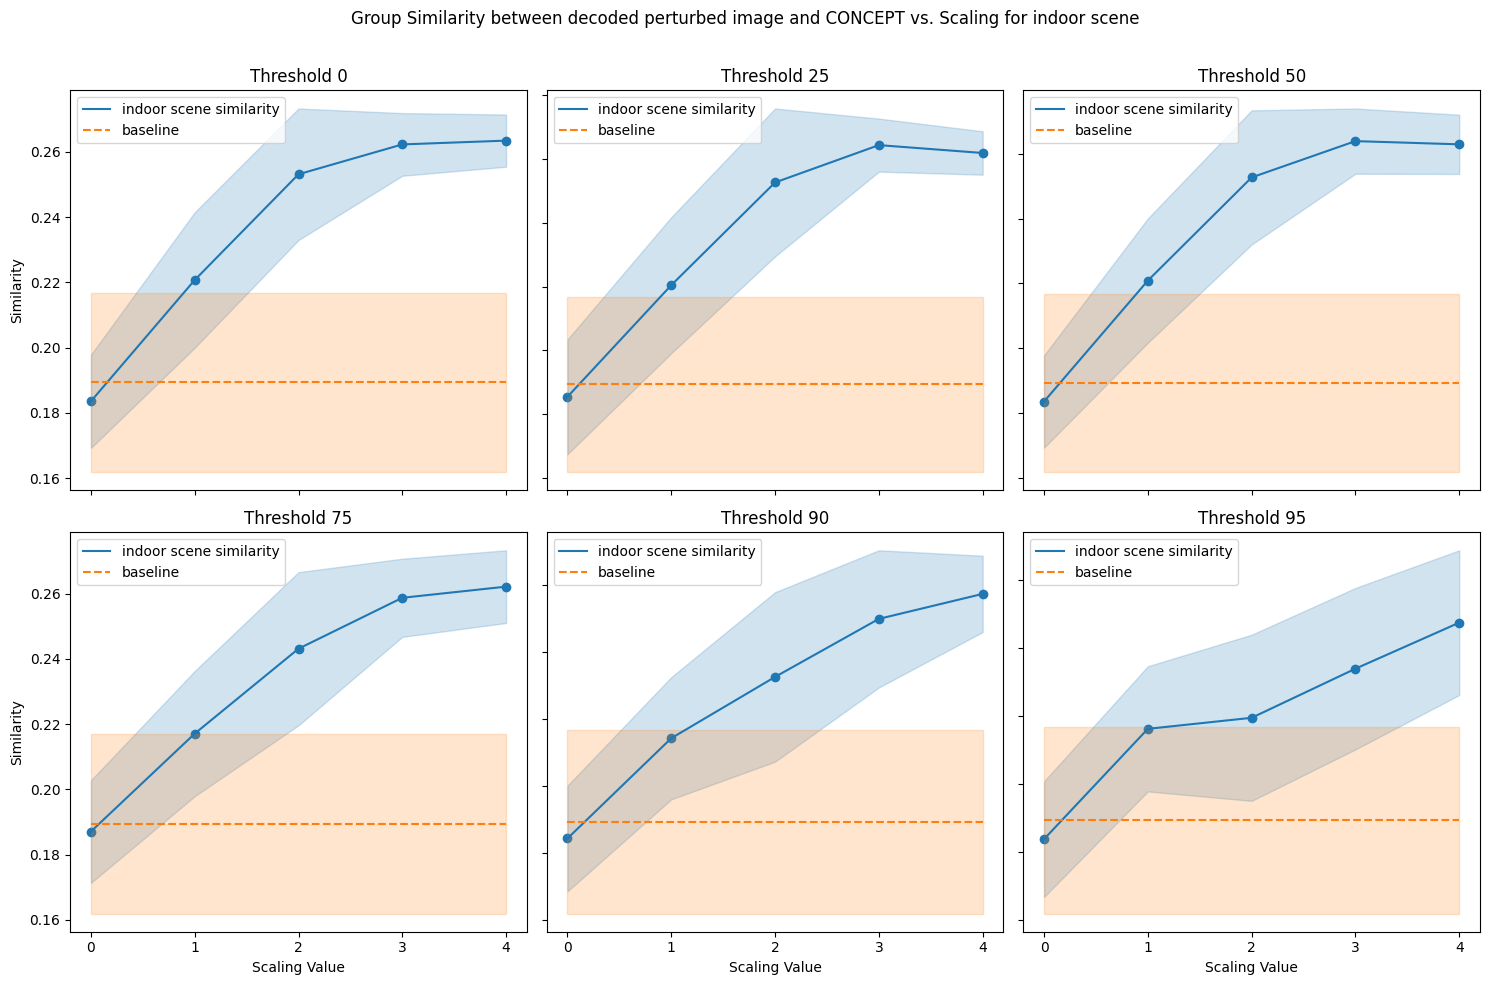

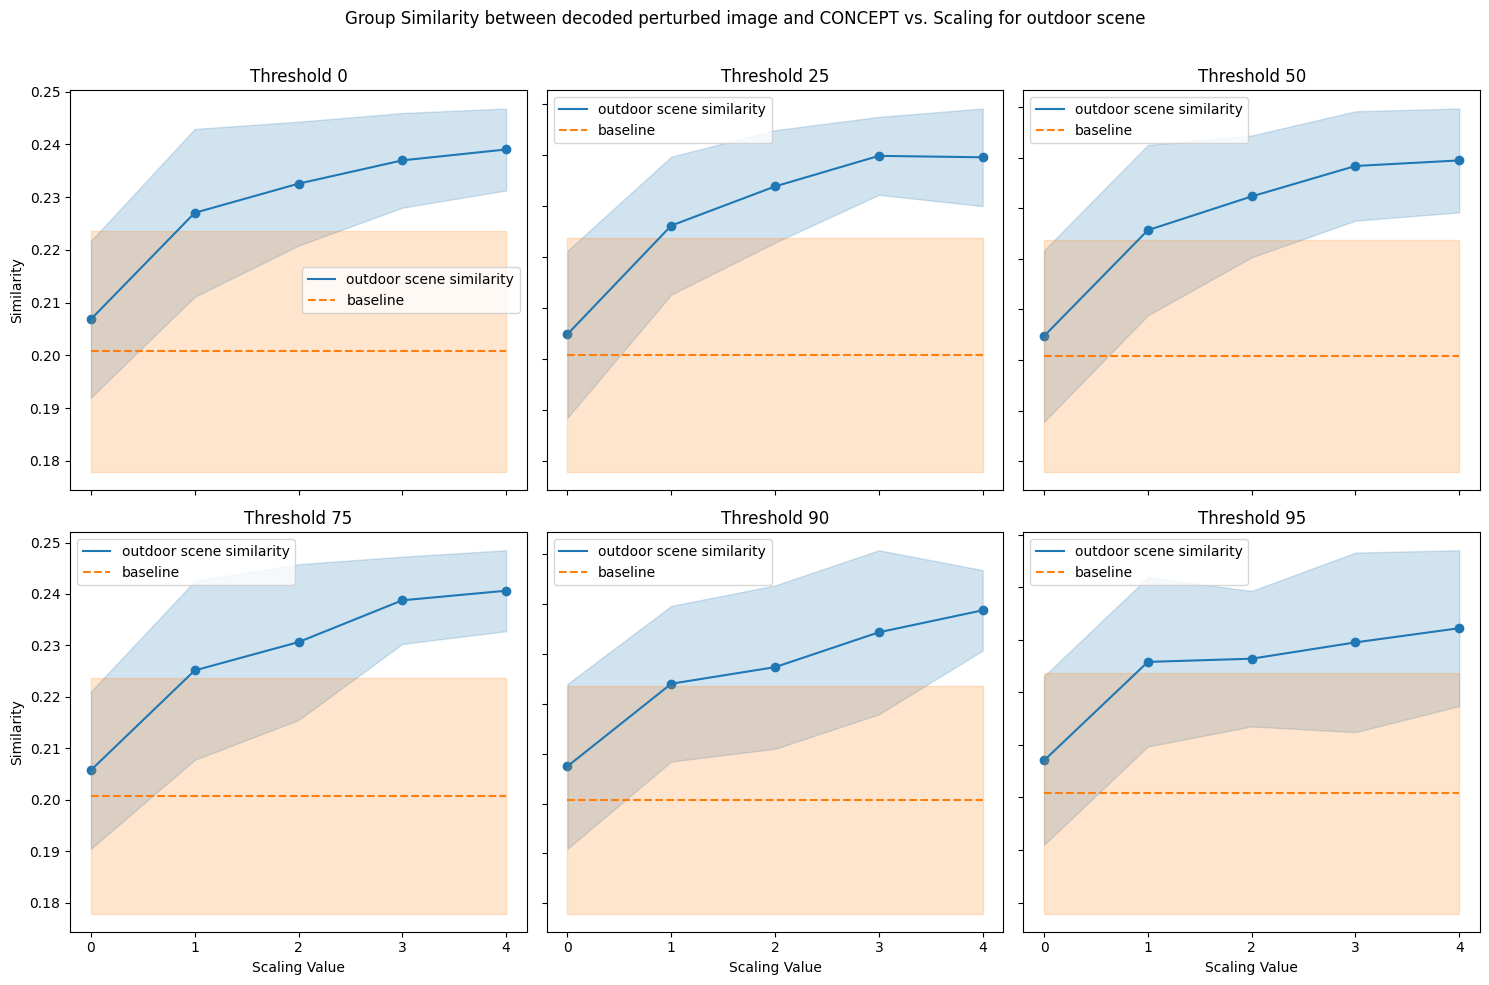

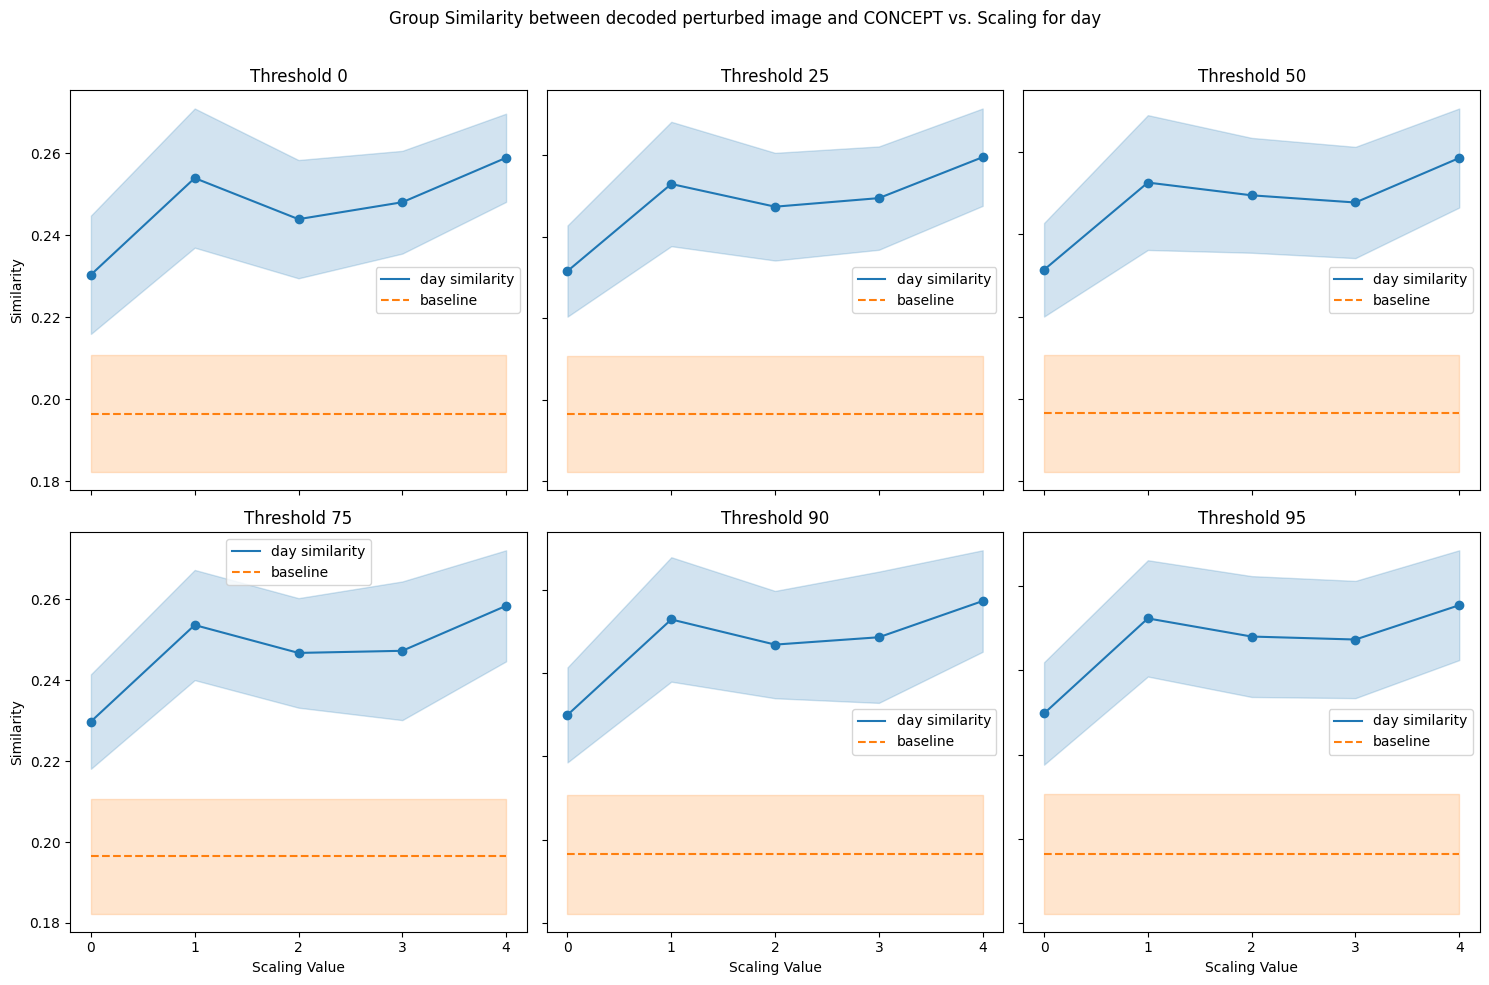

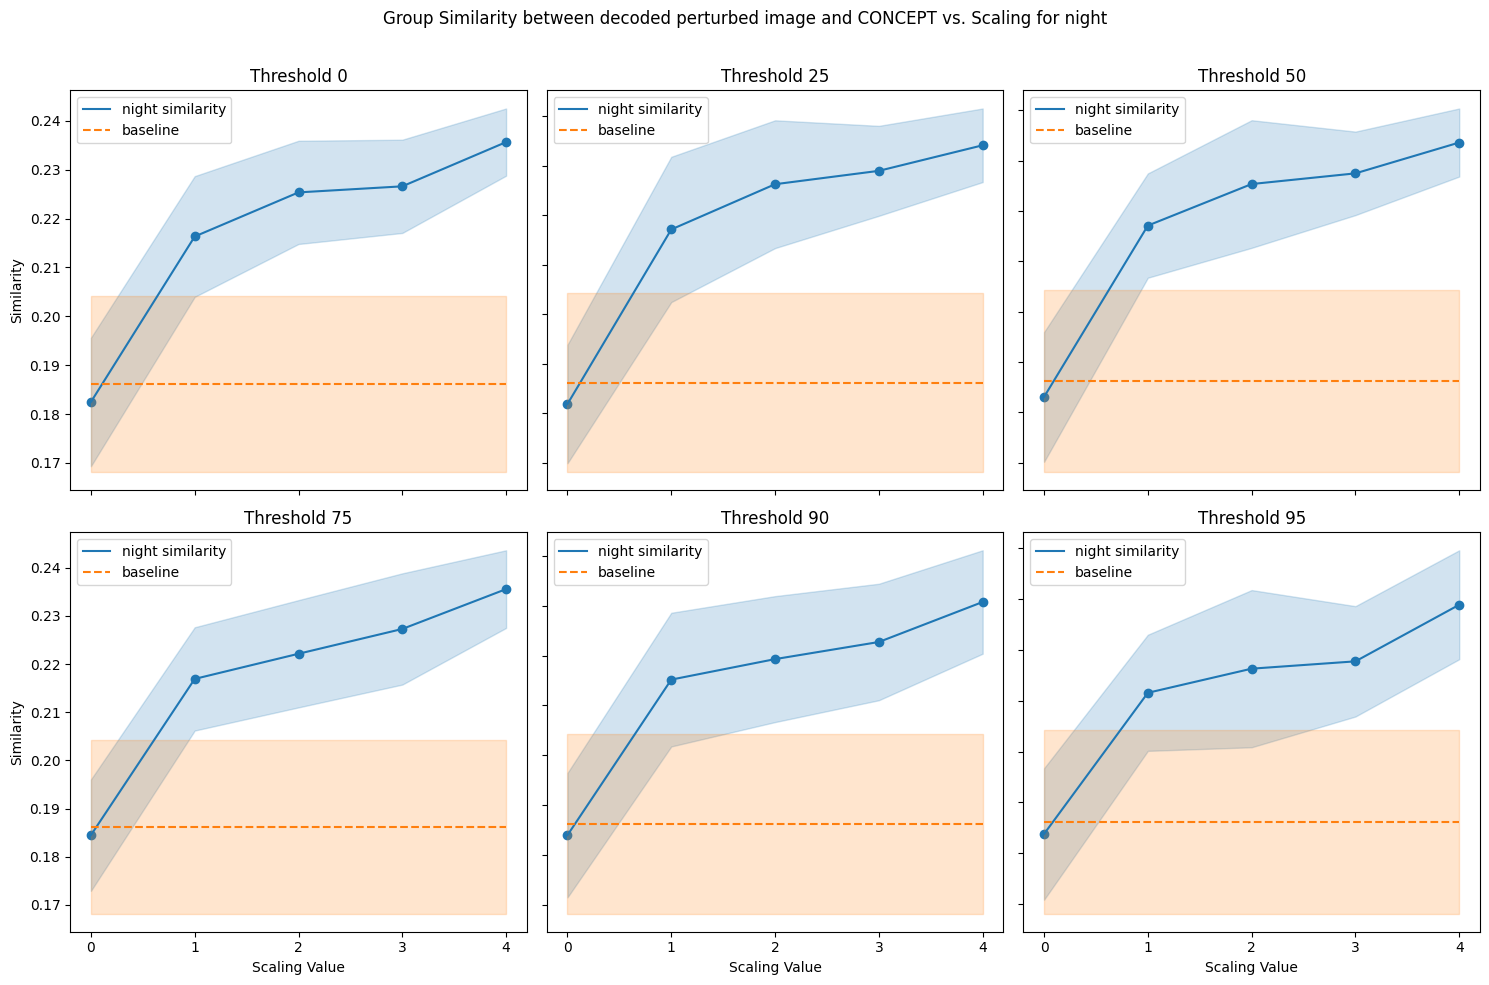

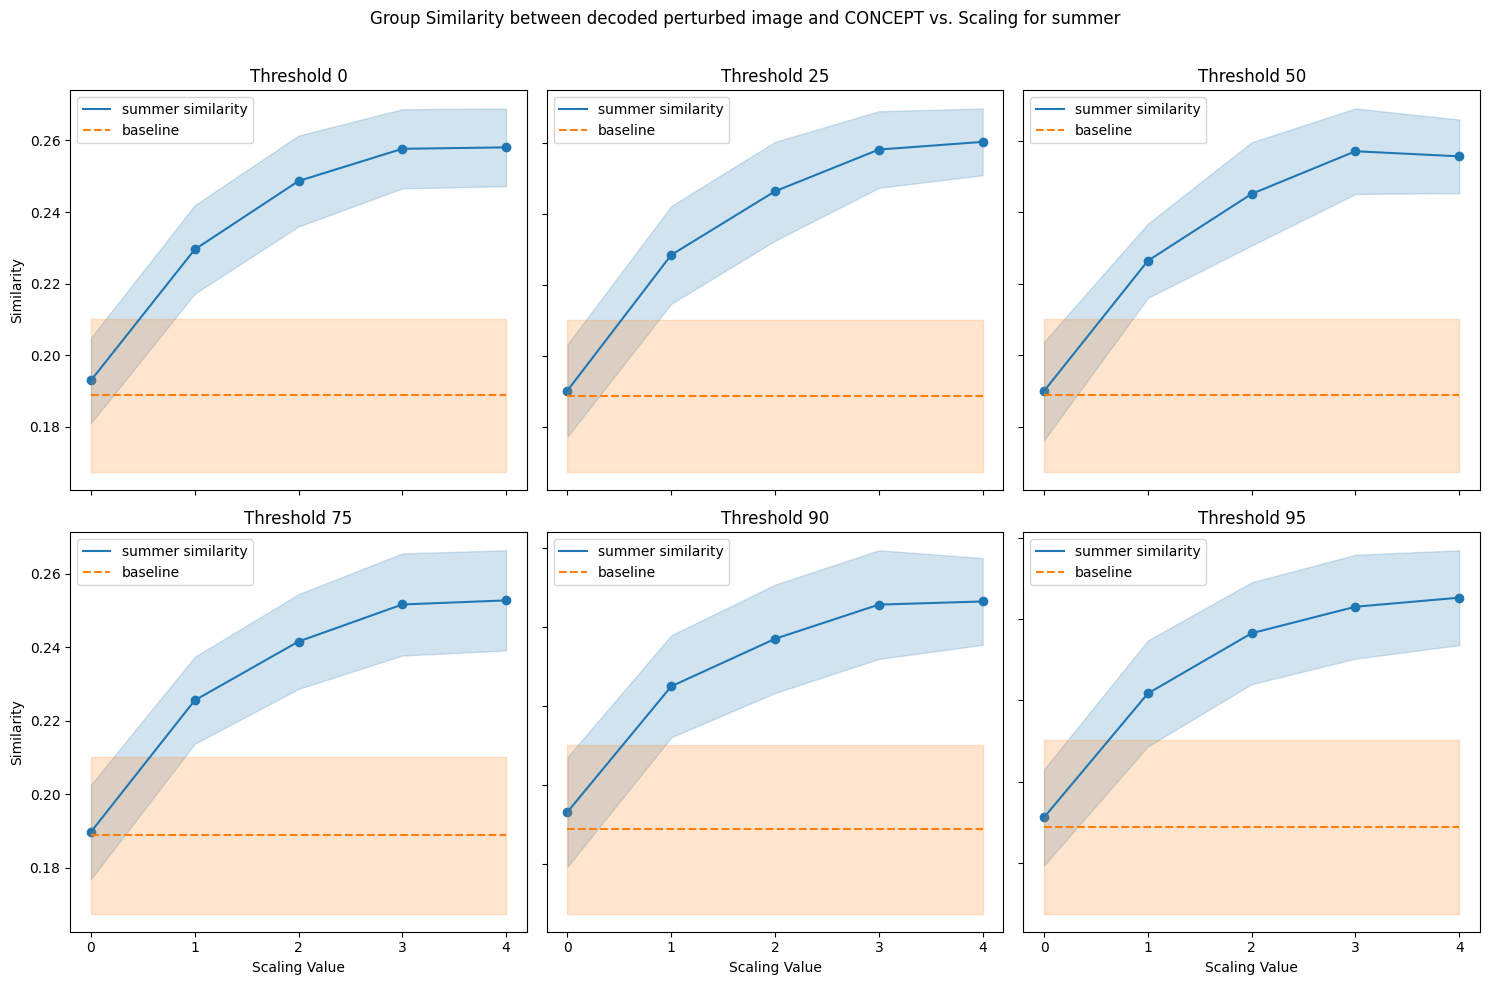

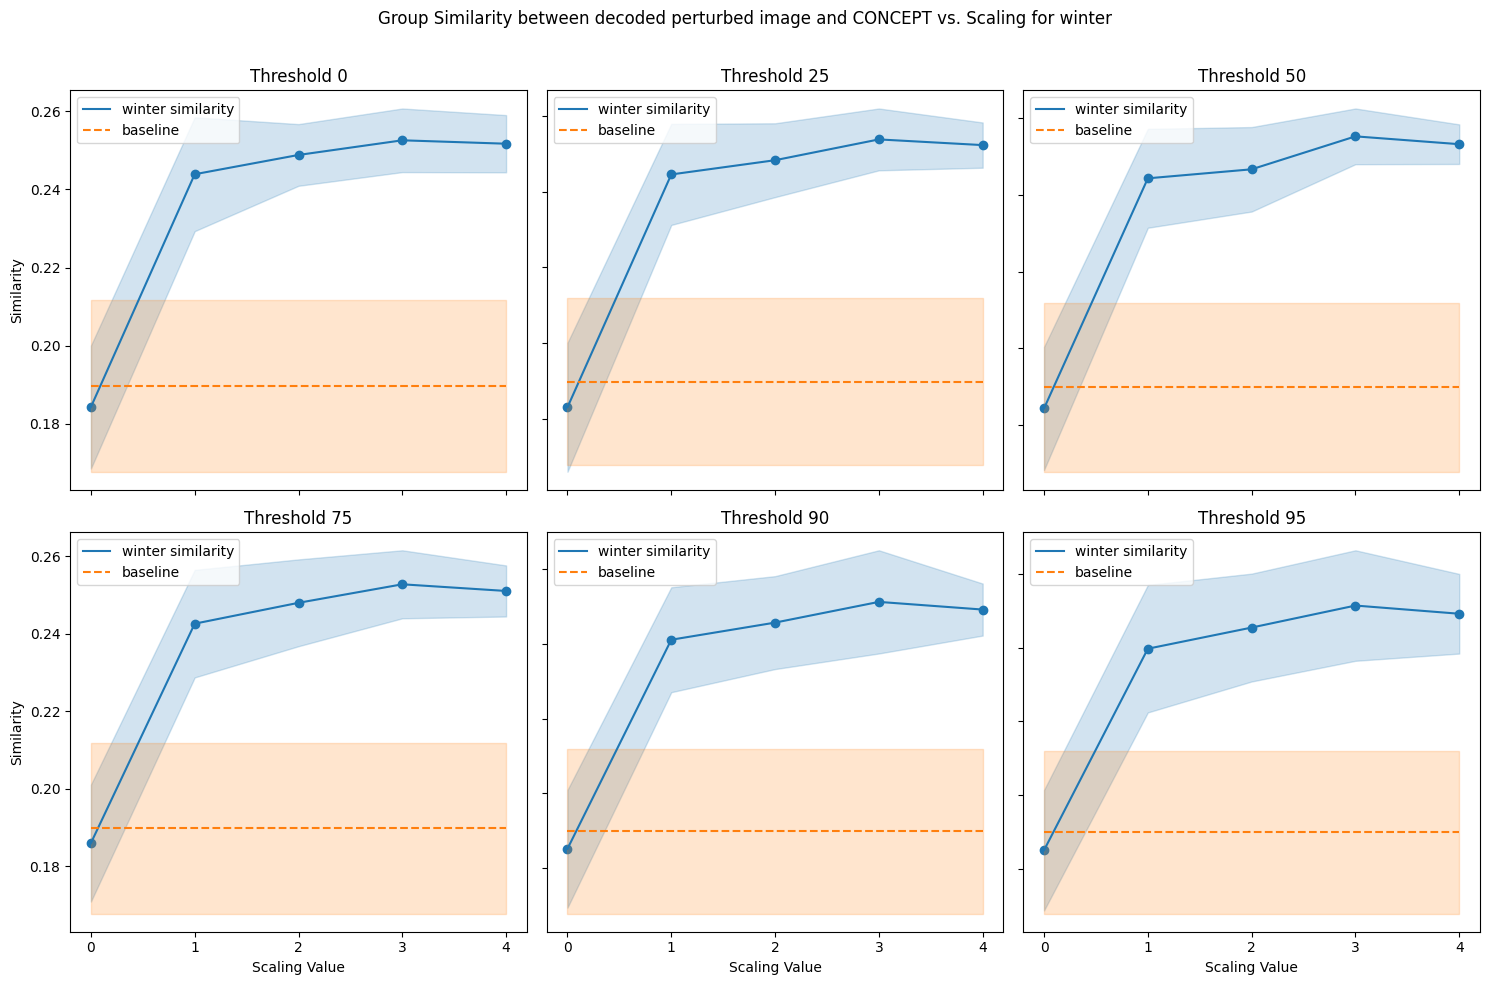

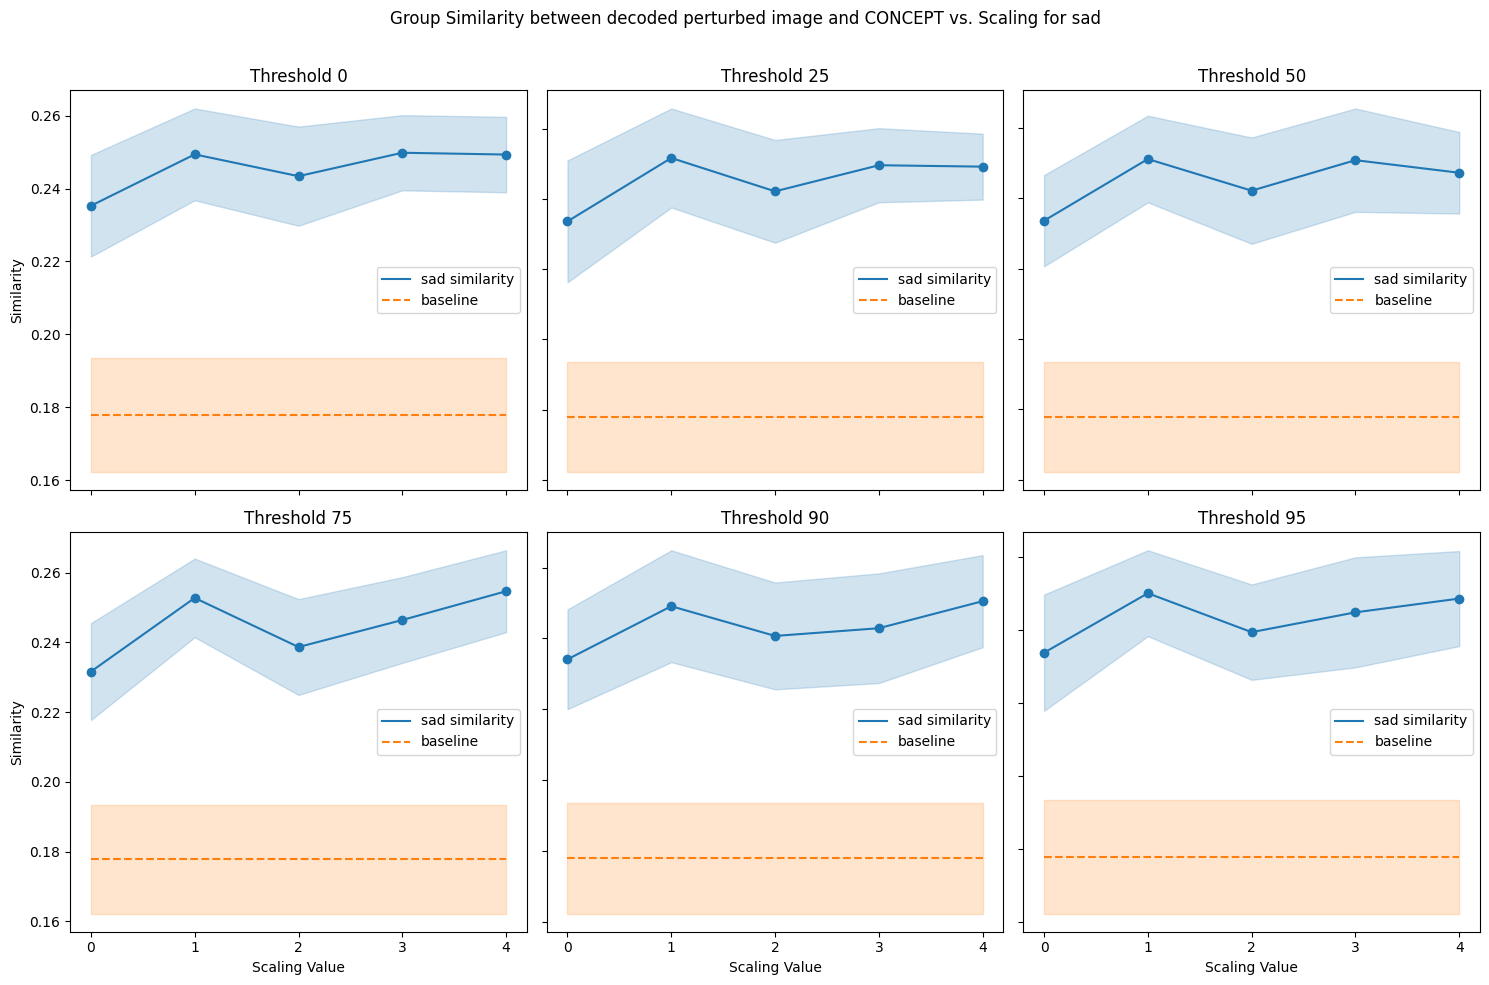

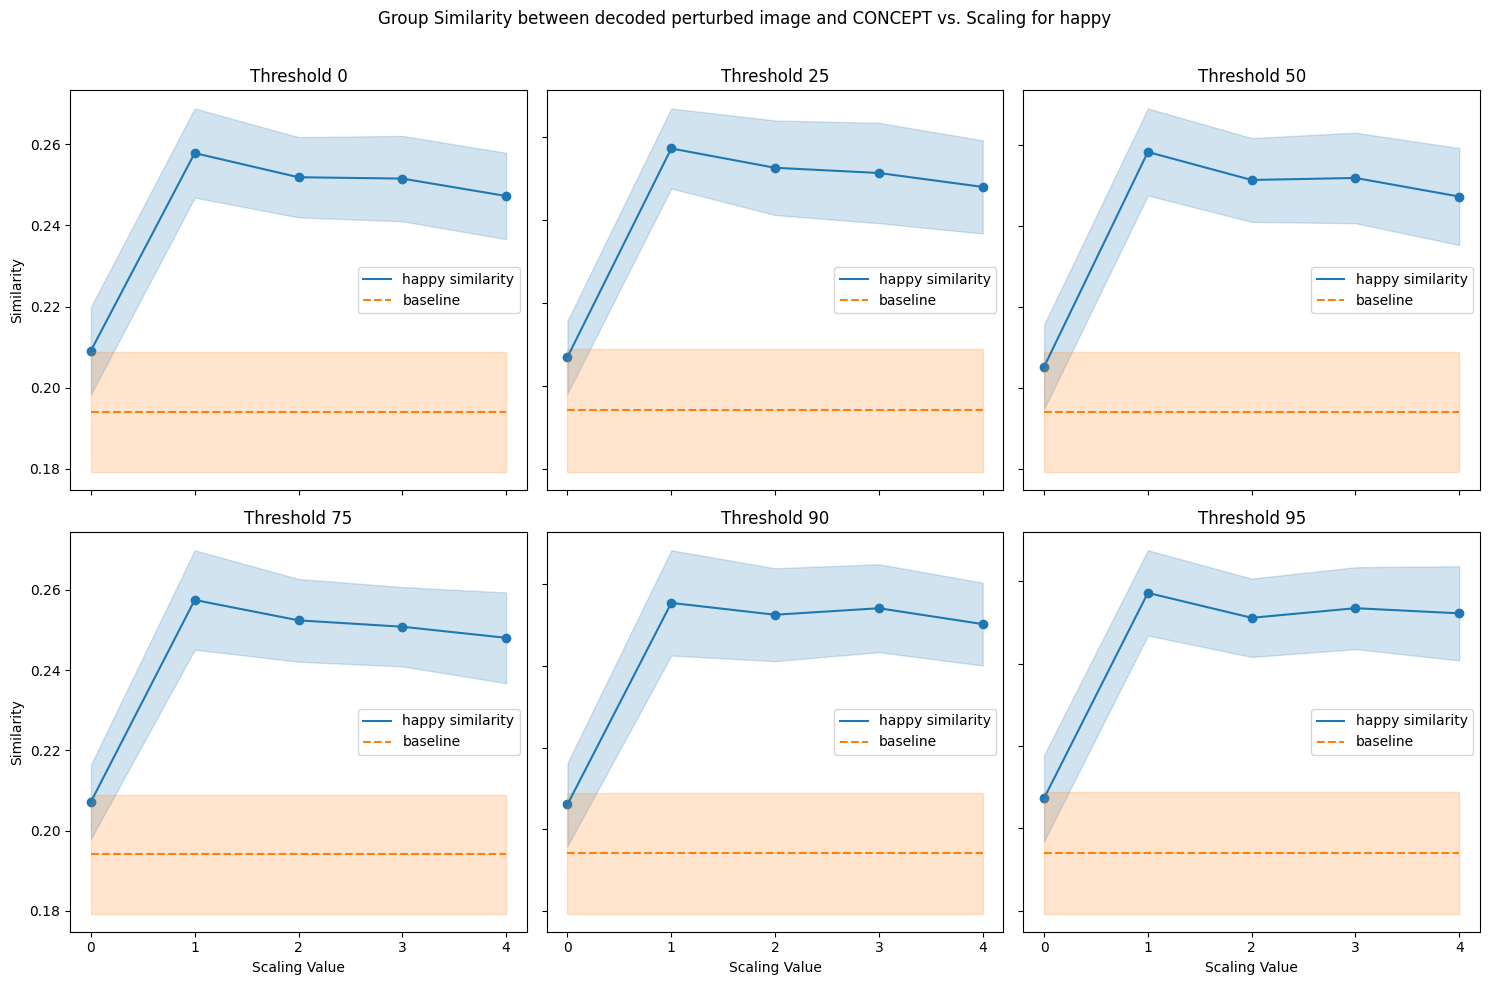

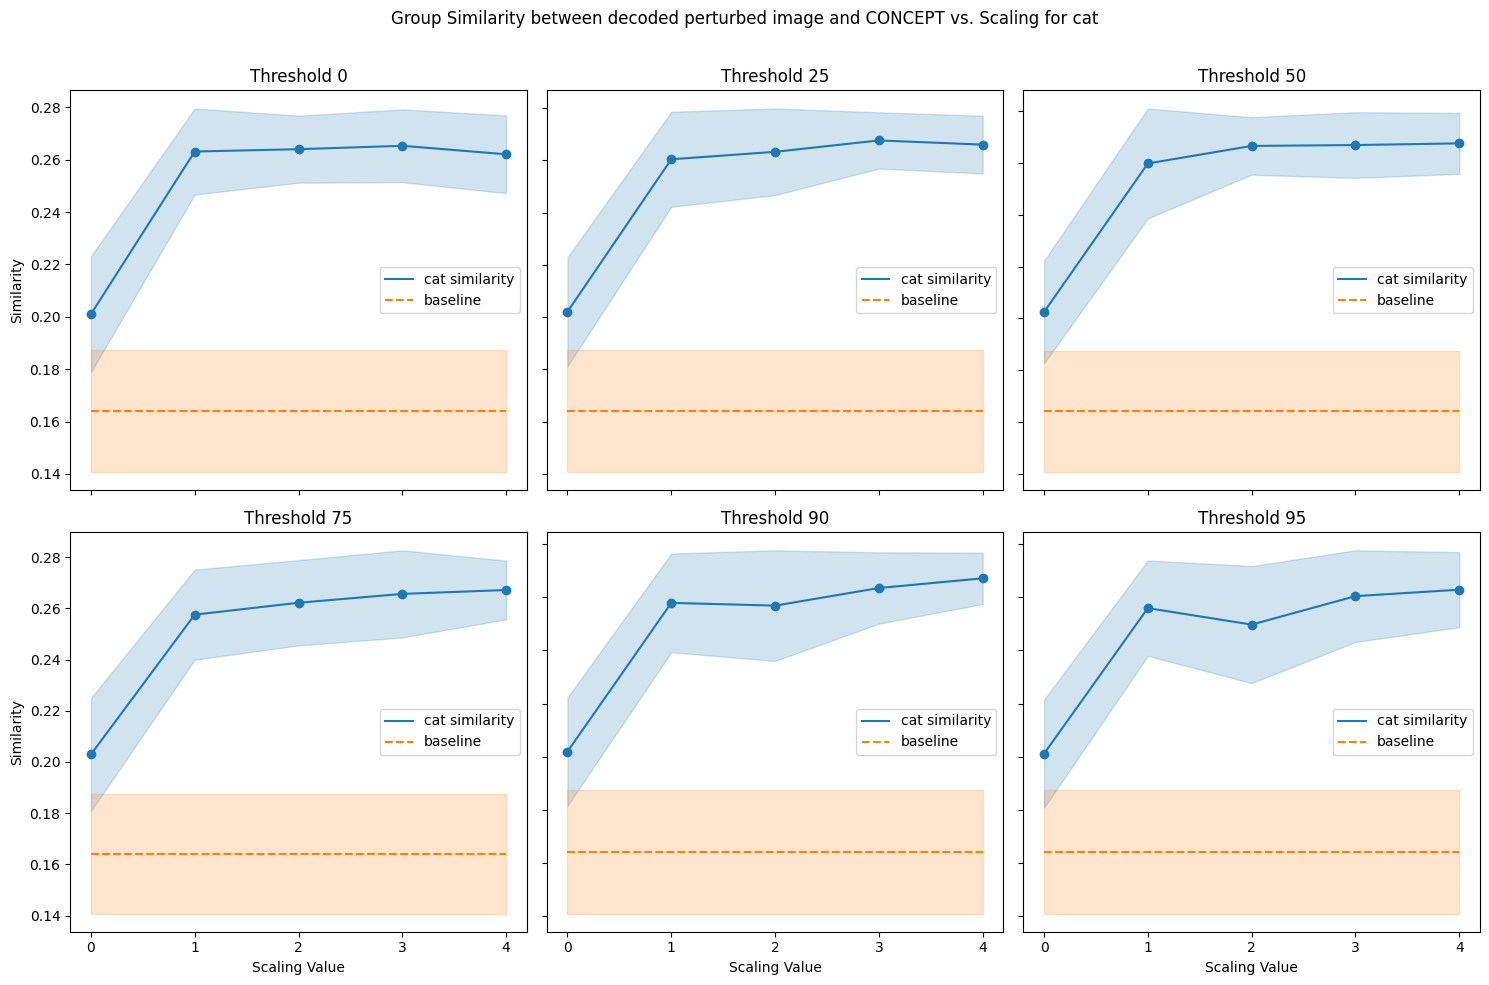

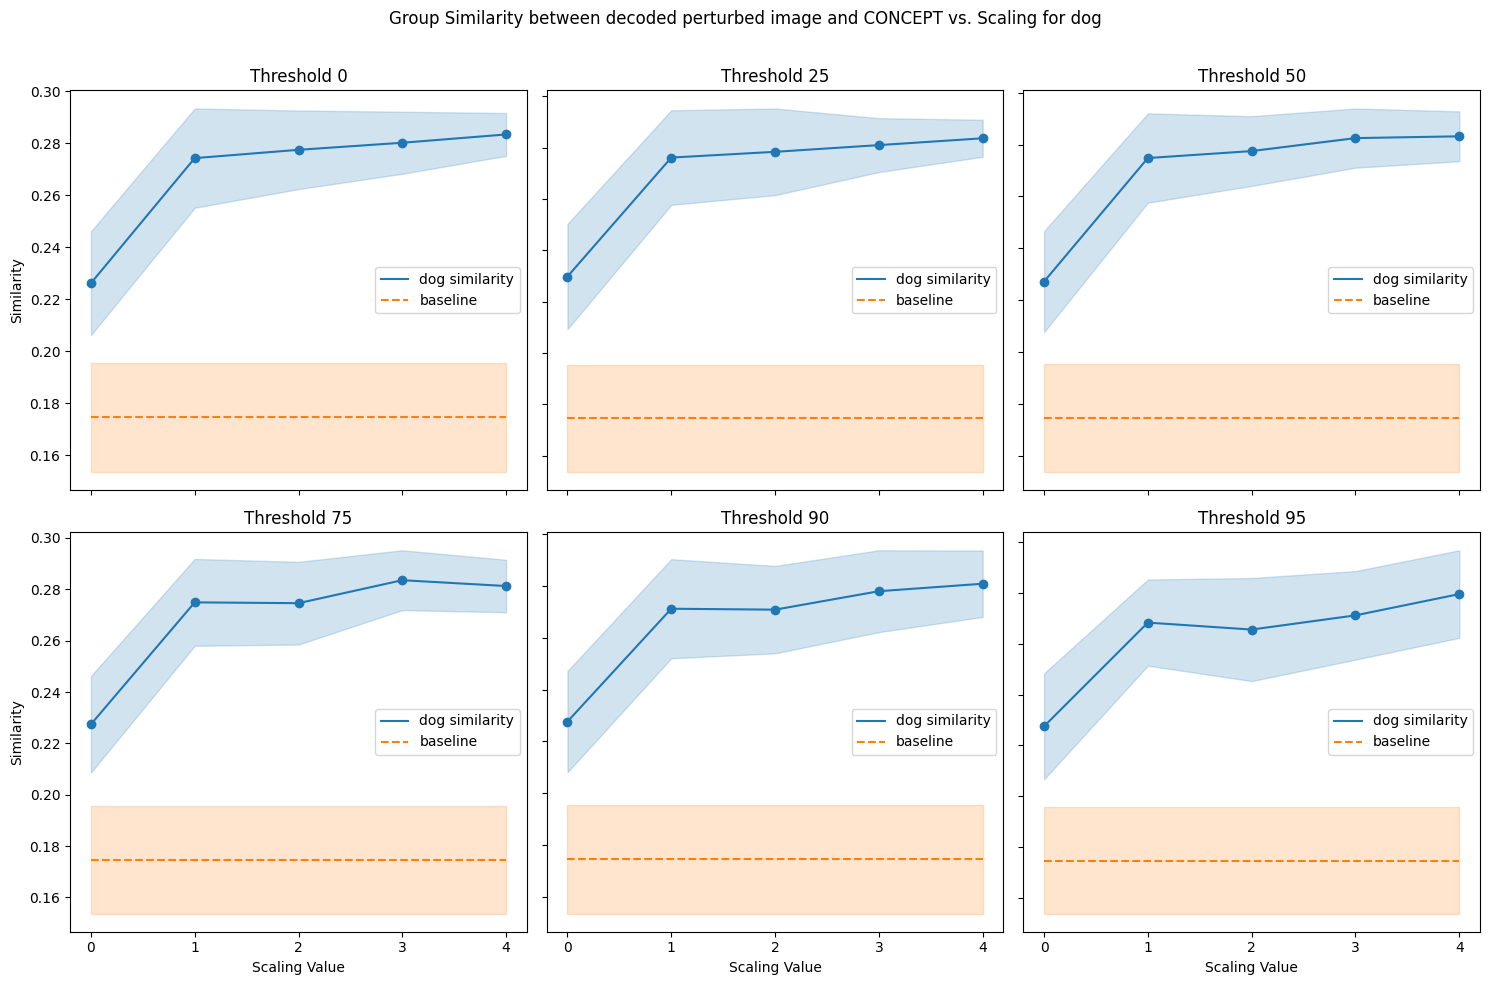

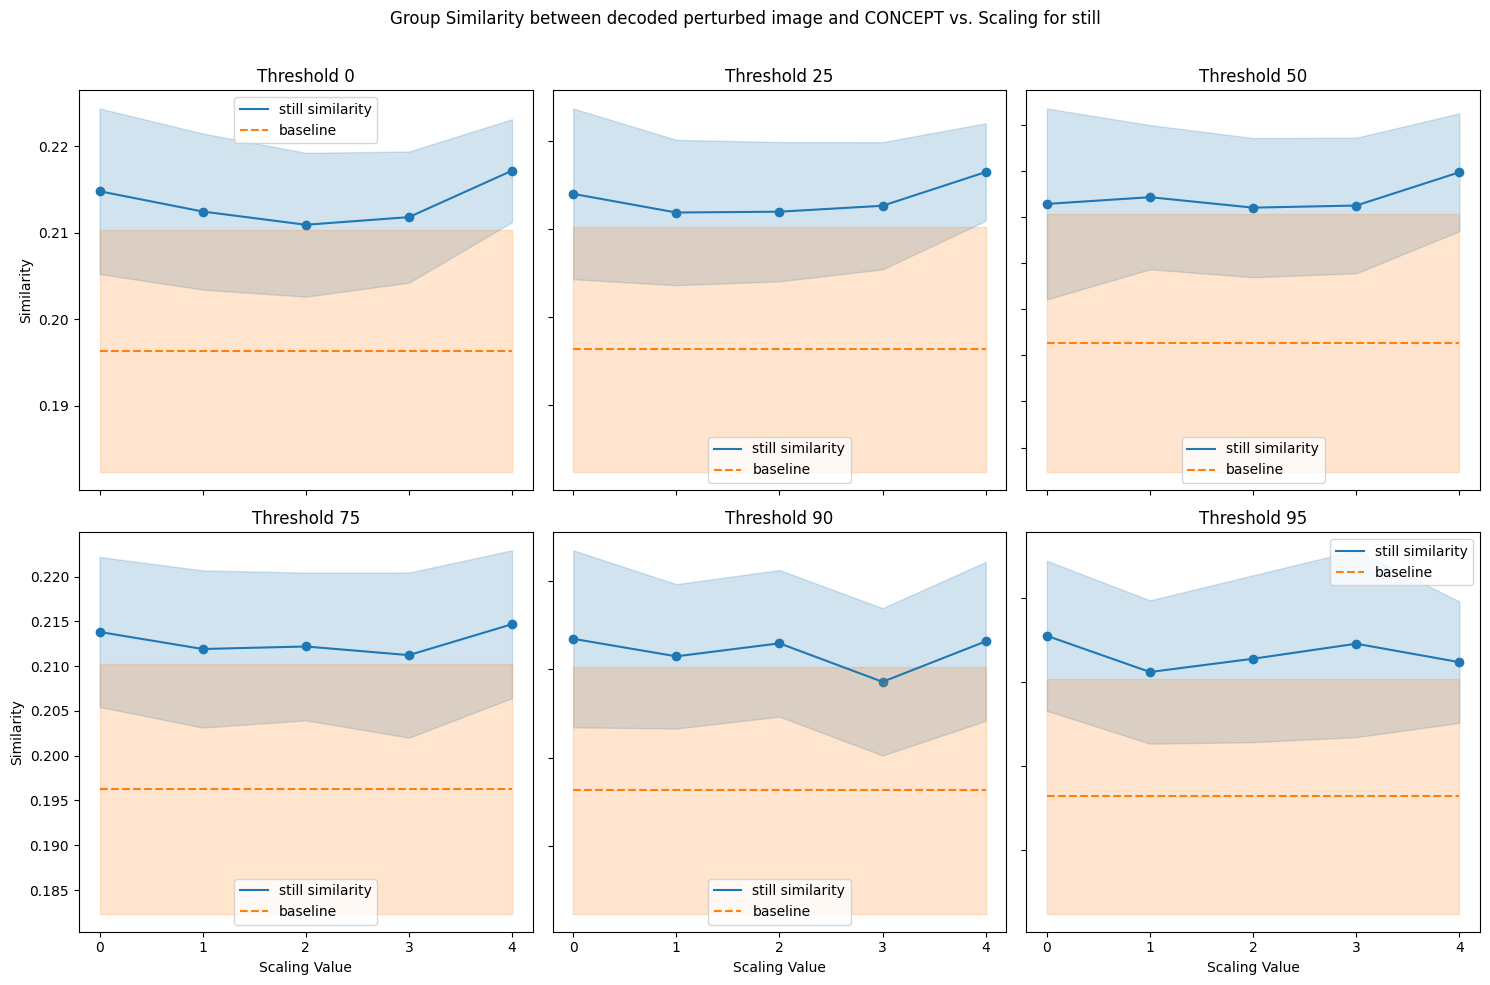

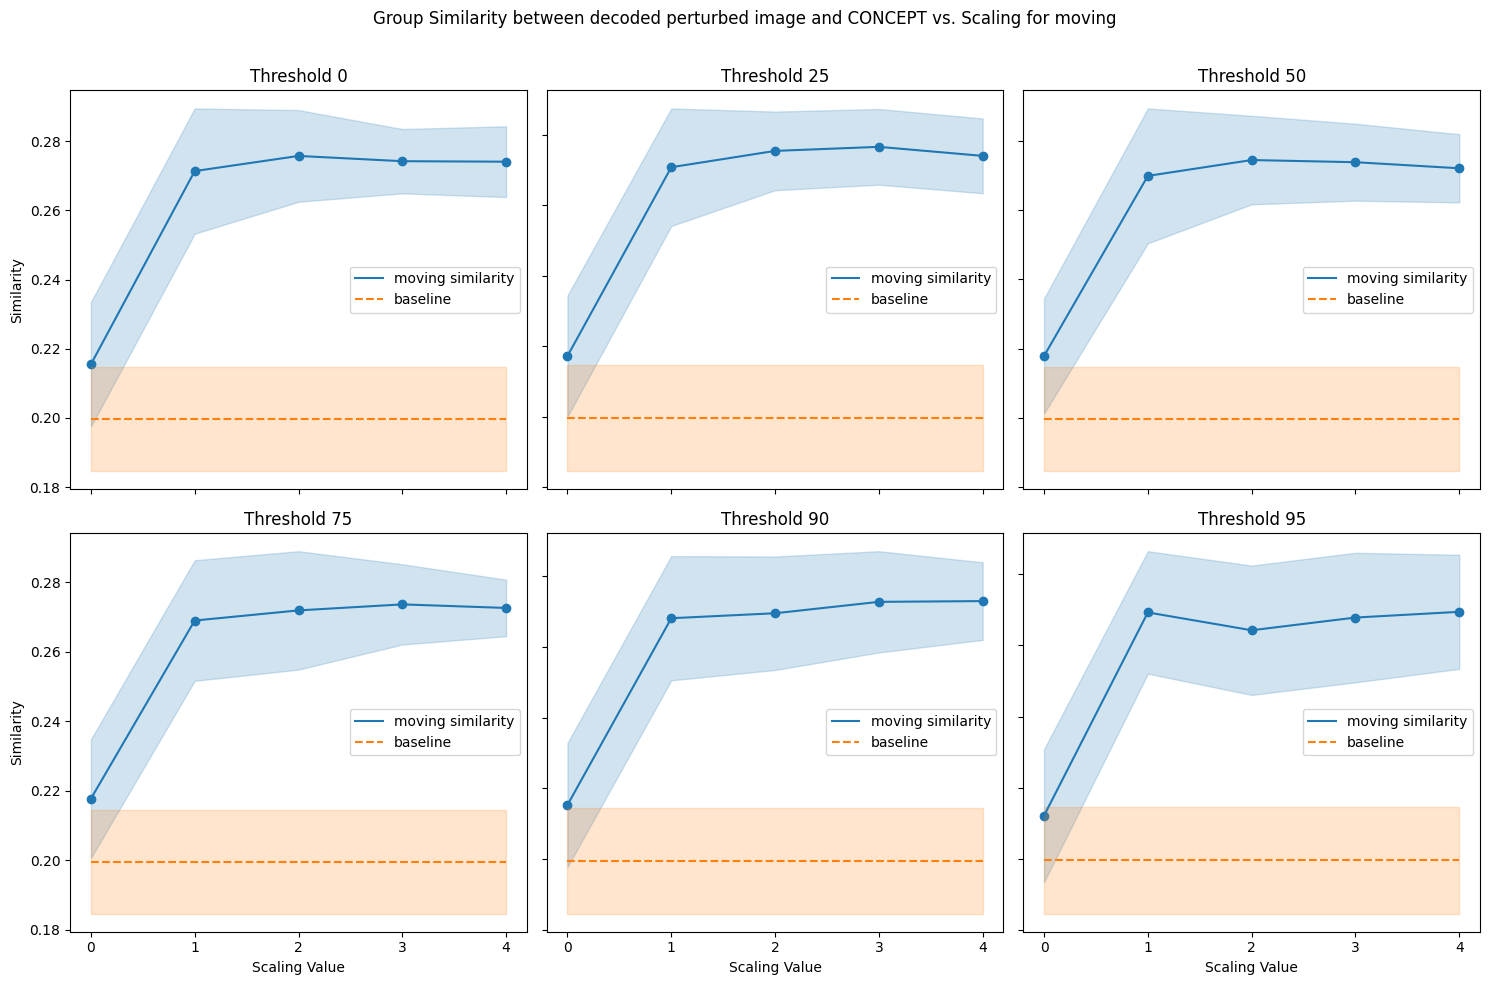

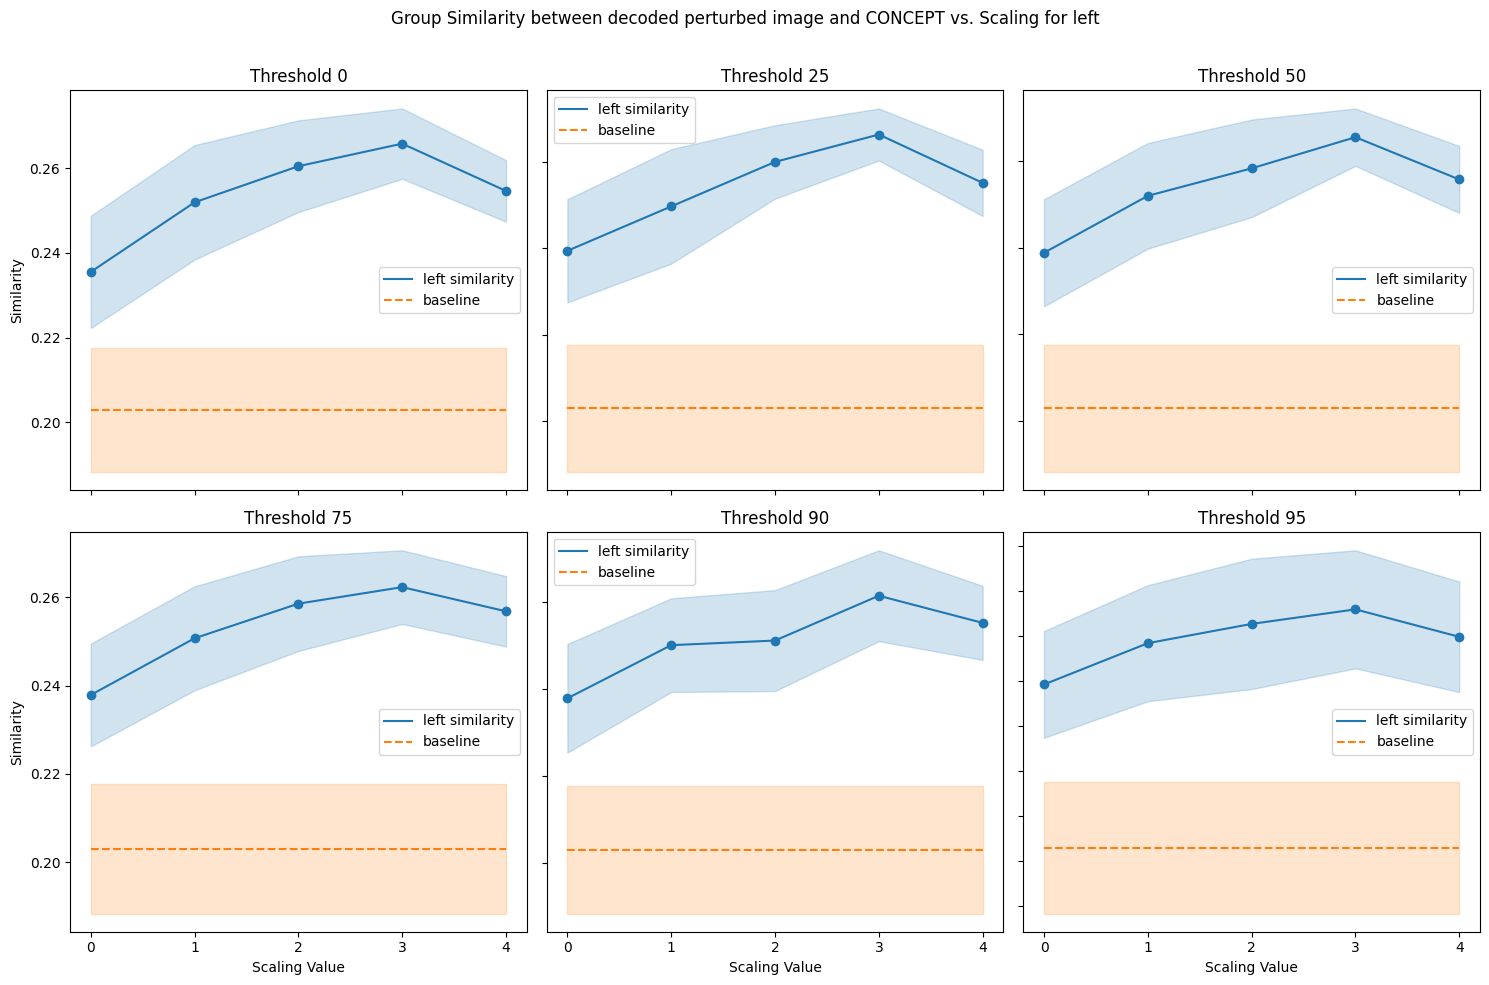

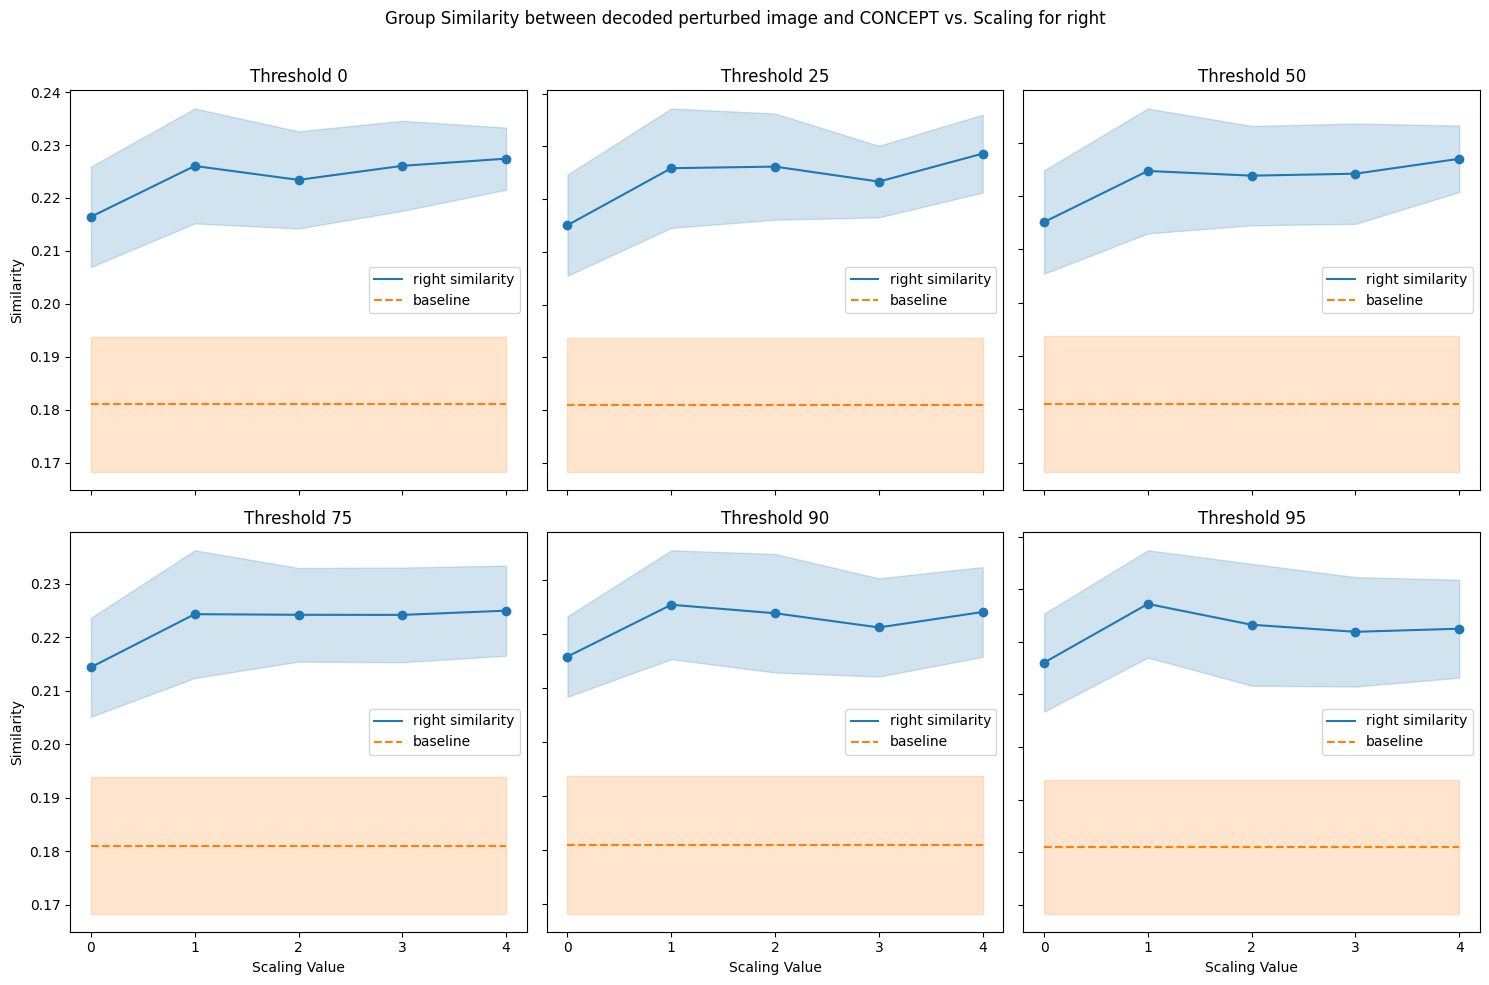

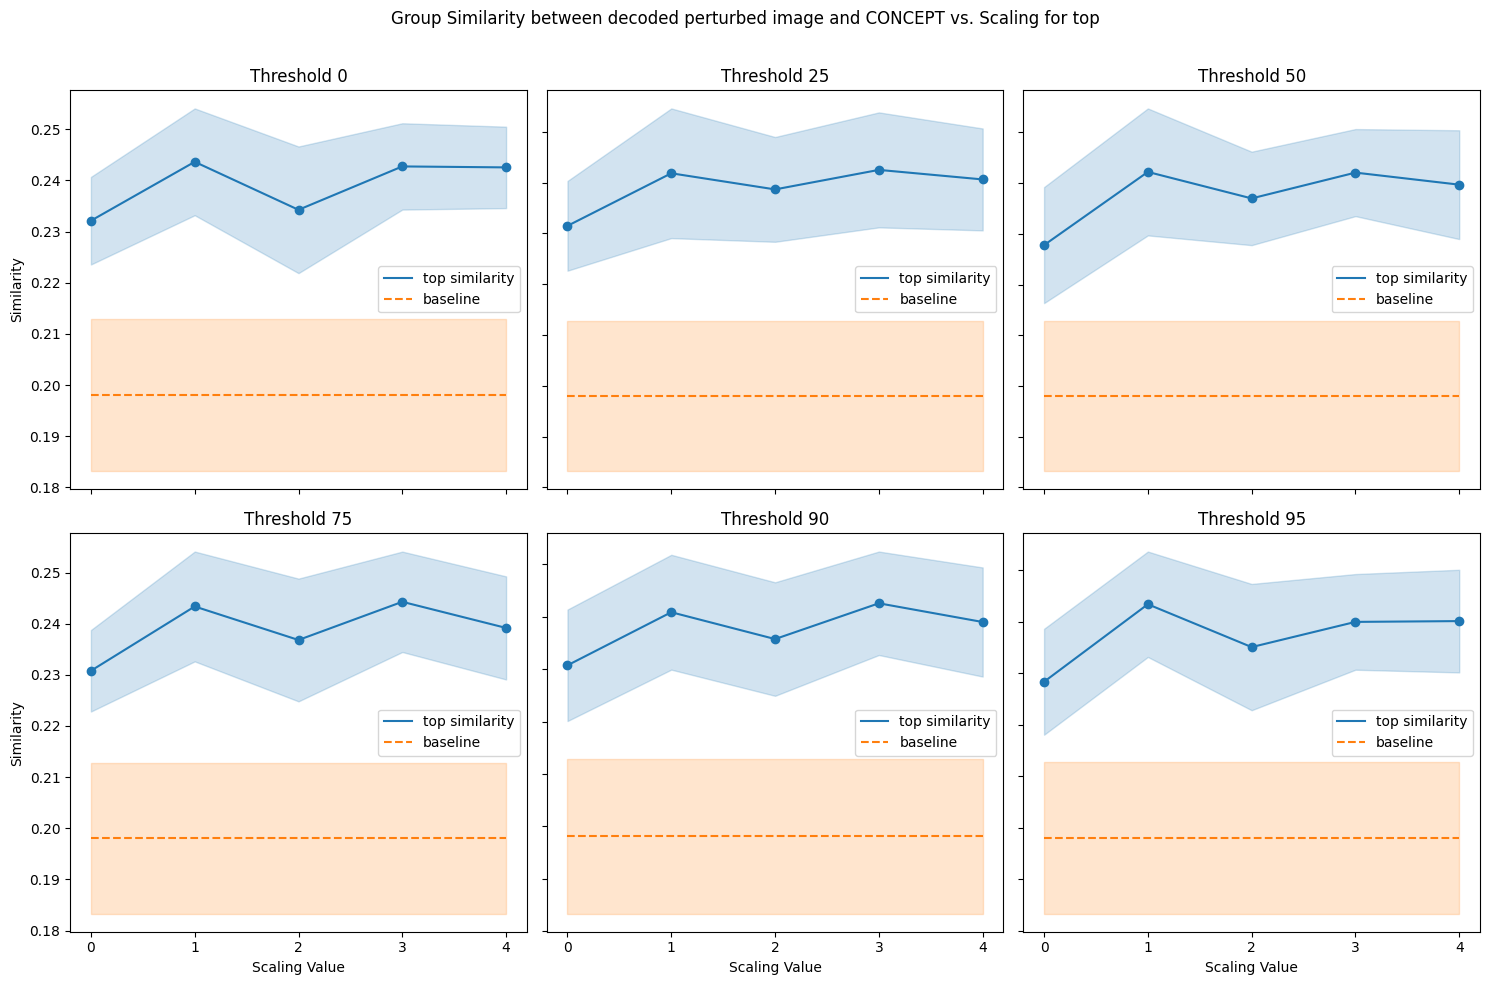

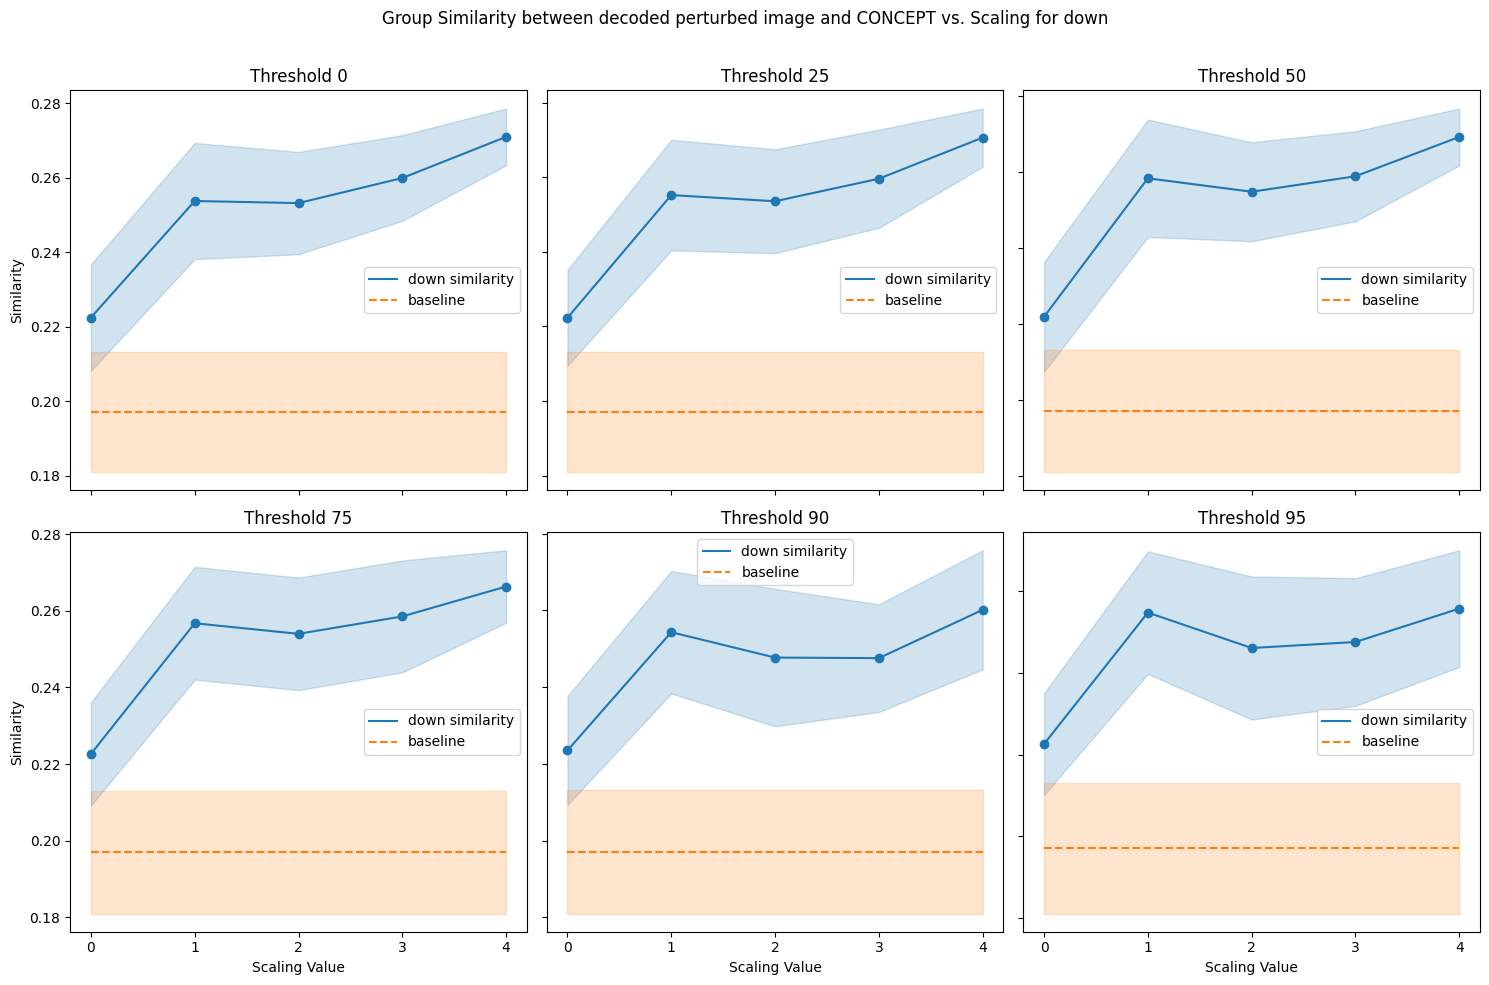

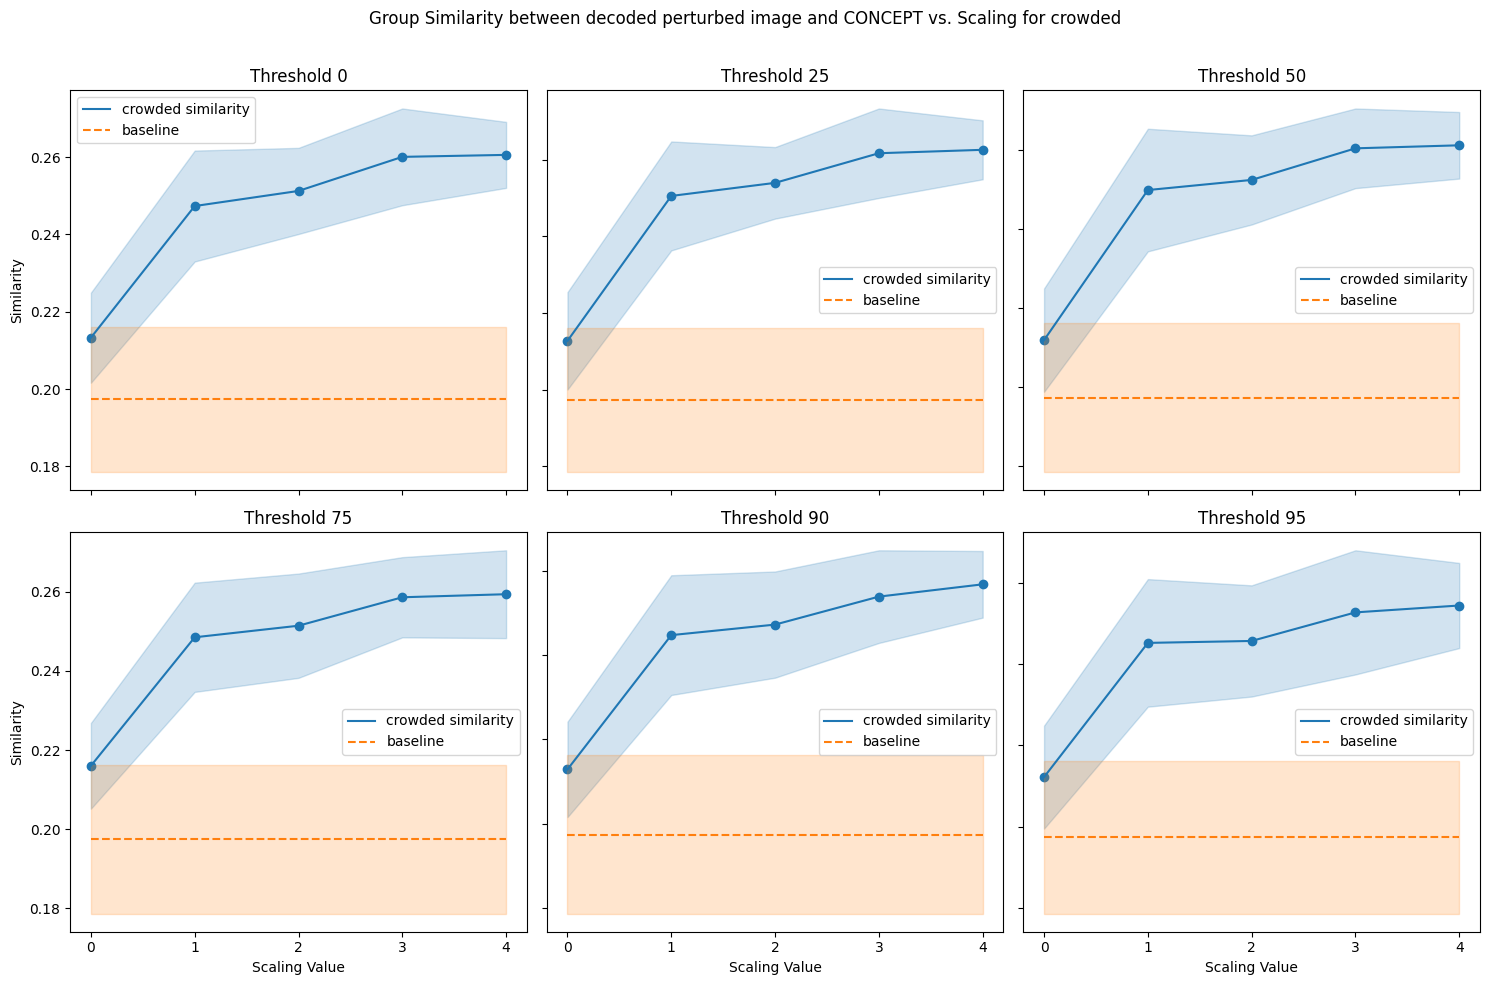

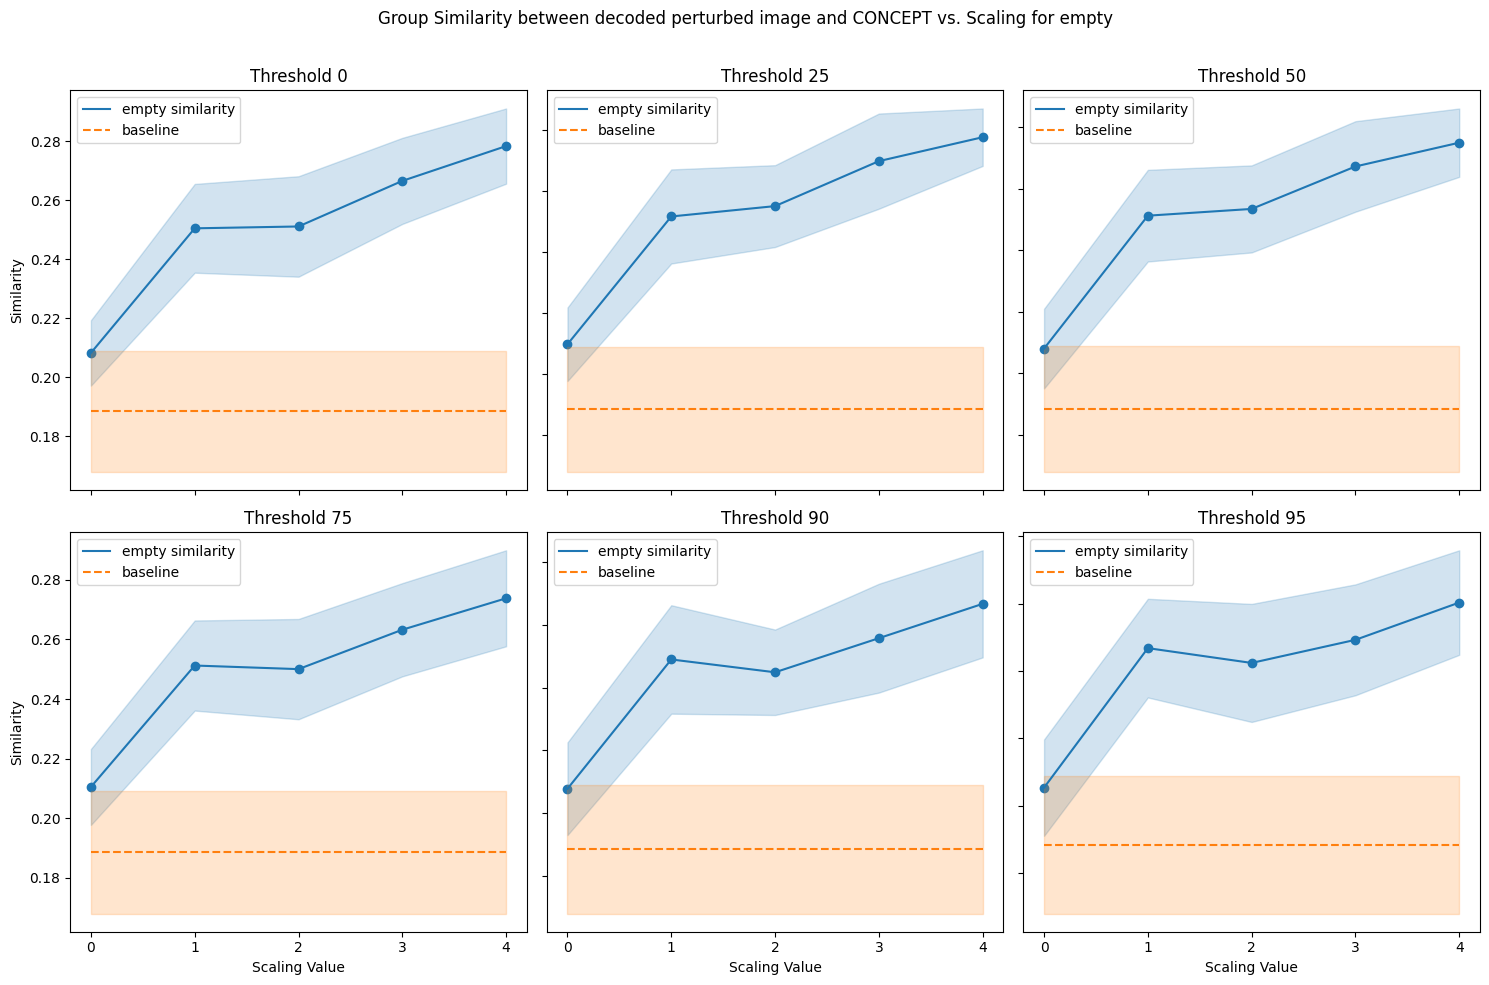

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj

# Assuming subjs is a list of subjects and all_results_sub is a dictionary containing the results for each subject

scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]

# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

# Initialize dictionaries to store results across subjects
group_y1_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y1_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Collect data across all subjects
for sub in subjs:
    all_results = all_results_sub[sub]
    
    for pair in unrolled_concepts:
        for thr in thrs:
            for key in all_keys:
                img_embeds = all_results[thr][pair][key]
                group_y1_means[thr][pair][key].append(img_embeds[:, 0].mean())
                group_y2_means[thr][pair][key].append(img_embeds[:, 1].mean())
                group_y1_stds[thr][pair][key].append(img_embeds[:, 0].std())
                group_y2_stds[thr][pair][key].append(img_embeds[:, 1].std())

# Calculate group means and average of STDs
group_means_y1 = {thr: {pair: {key: np.mean(group_y1_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_means_y2 = {thr: {pair: {key: np.mean(group_y2_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y1 = {thr: {pair: {key: np.mean(group_y1_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y2 = {thr: {pair: {key: np.mean(group_y2_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Now plot the group averages with their average standard deviations
for pair in unrolled_concepts:
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Group Similarity between decoded perturbed image and CONCEPT vs. Scaling for {pair}")

    for idx, thr in enumerate(thrs):
        row = idx // n_cols
        col = idx % n_cols

        y1_means = [group_means_y1[thr][pair][key] for key in all_keys]
        y2_means = [group_means_y2[thr][pair][key] for key in all_keys]
        y1_avg_stds = [average_stds_y1[thr][pair][key] for key in all_keys]
        y2_avg_stds = [average_stds_y2[thr][pair][key] for key in all_keys]

        
        axs[row, col].plot(scaling_values, y1_means, label=f"{pair} similarity")
        axs[row, col].scatter(scaling_values, y1_means)
        
        axs[row, col].fill_between(scaling_values, 
                                   np.array(y1_means) - np.array(y1_avg_stds), 
                                   np.array(y1_means) + np.array(y1_avg_stds), alpha=0.2,color="tab:blue")
        
        axs[row,col].set_xticks(scaling_values)

                
            
        axs[row,col].hlines(baselines[pair]["baseline_concept_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:orange",label="baseline")

        
        axs[row, col].fill_between(x=scaling_values, y1=baselines[pair]["baseline_concept_similarities_mean"].mean()-baselines[pair]["baseline_concept_similarities_std"].mean(), 
                                   y2=baselines[pair]["baseline_concept_similarities_mean"].mean()+baselines[pair]["baseline_concept_similarities_std"].mean(),color="tab:orange",alpha=0.2)

        axs[row, col].set_ylabel("Similarity")
        axs[row, col].set_title(f"Threshold {thr}")
        axs[row, col].legend()

        # Add arrows to indicate concept directions
        center = 0  # Index of 0 on the x-axis

    for ax in axs.flat:
        ax.label_outer()  # Hide inner labels to avoid clutter

    axs[-1, 0].set_xlabel("Scaling Value")
    axs[-1, 1].set_xlabel("Scaling Value")
    axs[-1, 2].set_xlabel("Scaling Value")
    
    # plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
    # plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and CONCEPT Scaling for {pair}.png"))
    # plt.show()

    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
    plt.savefig(opj("results_group", f"Group Similarity between decoded perturbed image and CONCEPT Scaling for {pair}.png"))
    plt.show()


## CONCEPT AVERAGING

In [55]:
baselines_aggregated = {}

img_sim_mean=[]
img_sim_std=[]
concept_sim_mean=[]
concept_sim_std=[]

for pair in unrolled_concepts:
    img_sim_mean.append(baselines[pair]["baseline_img_similarities_mean"])
    img_sim_std.append(baselines[pair]["baseline_img_similarities_std"])
    concept_sim_mean.append(baselines[pair]["baseline_concept_similarities_mean"])
    concept_sim_std.append(baselines[pair]["baseline_concept_similarities_std"])
    
baselines_aggregated = {"baseline_img_similarities_mean": torch.stack(img_sim_mean).mean(0),
                        "baseline_img_similarities_std": torch.stack(img_sim_std).mean(0),
                        "baseline_concept_similarities_mean": torch.stack(concept_sim_mean).mean(0),
                        "baseline_concept_similarities_std": torch.stack(concept_sim_std).mean(0),
                       }
    

In [59]:
baselines[pair]["baseline_concept_similarities_std"]

tensor([0.0205])

In [60]:
baselines_aggregated["baseline_concept_similarities_std"]

tensor([0.0179])

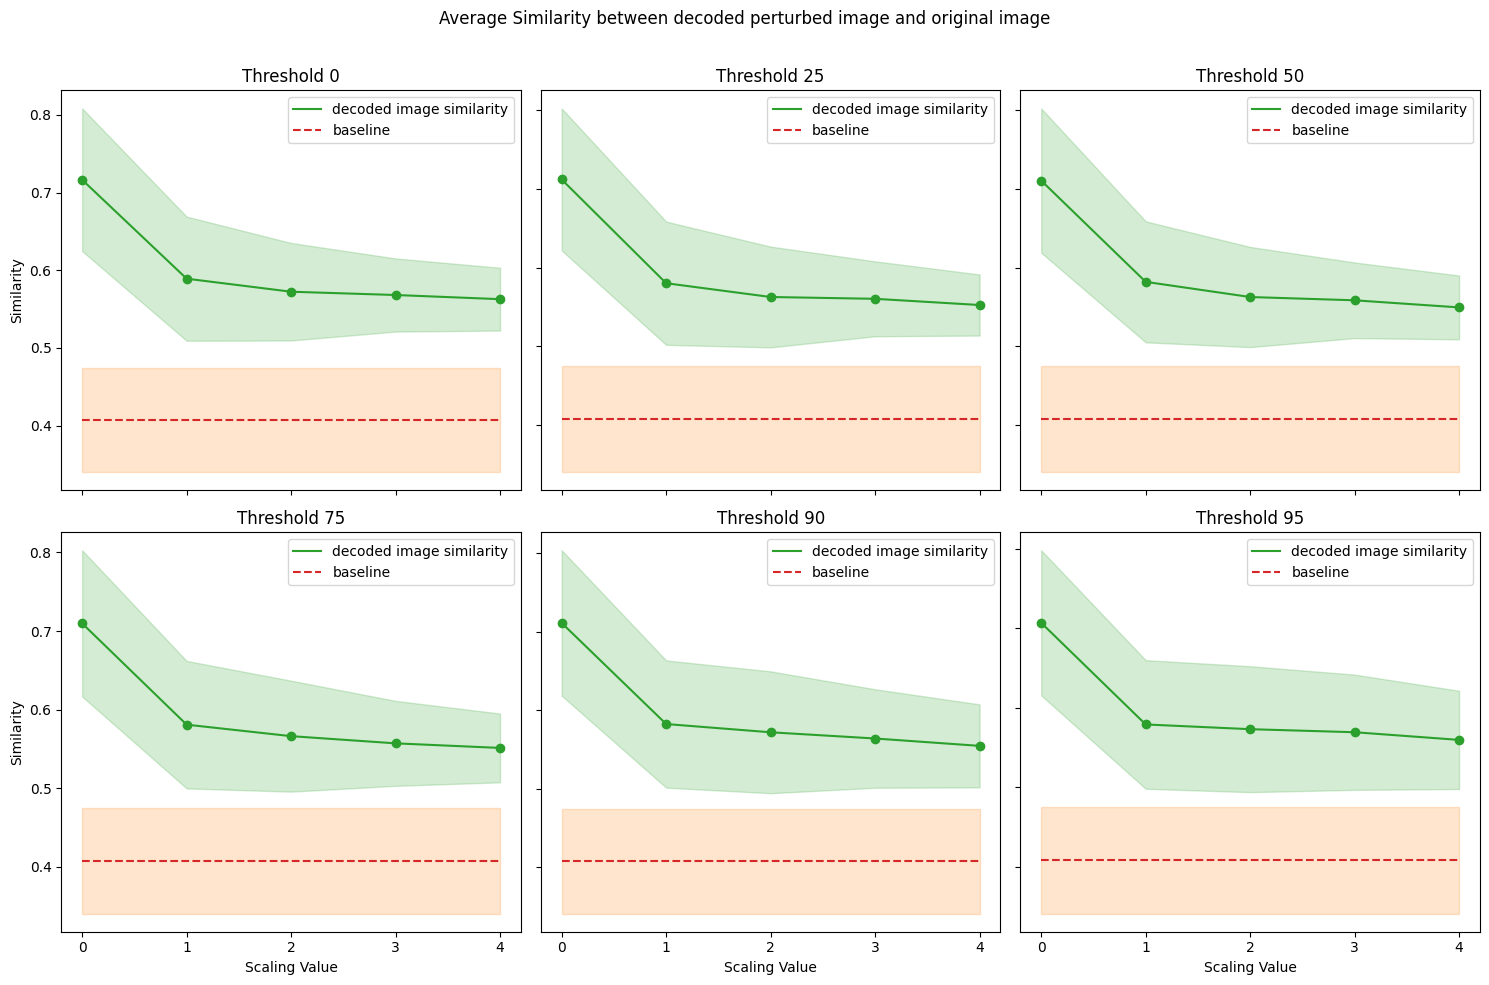

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj

# Assuming subjs is a list of subjects and all_results_sub is a dictionary containing the results for each subject

scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]

# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

# Initialize dictionaries to store results across subjects
group_y1_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y1_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Collect data across all subjects
for sub in subjs:
    all_results = all_results_sub[sub]
    
    for pair in unrolled_concepts:
        for thr in thrs:
            for key in all_keys:
                img_embeds = all_results[thr][pair][key]
                group_y1_means[thr][pair][key].append(img_embeds[:, 0].mean())
                group_y2_means[thr][pair][key].append(img_embeds[:, 1].mean())
                group_y1_stds[thr][pair][key].append(img_embeds[:, 0].std())
                group_y2_stds[thr][pair][key].append(img_embeds[:, 1].std())

# Calculate group means and average of STDs
group_means_y1 = {thr: {pair: {key: np.mean(group_y1_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_means_y2 = {thr: {pair: {key: np.mean(group_y2_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y1 = {thr: {pair: {key: np.mean(group_y1_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y2 = {thr: {pair: {key: np.mean(group_y2_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}


fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)


fig.suptitle(f"Average Similarity between decoded perturbed image and original image")

for idx, thr in enumerate(thrs):
    row = idx // n_cols
    col = idx % n_cols

    y1_means = np.array([[group_means_y1[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0) ## all concpets
    y2_means = np.array([[group_means_y2[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)
    y1_avg_stds = np.array([[average_stds_y1[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)
    y2_avg_stds = np.array([[average_stds_y2[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)

    axs[row, col].plot(scaling_values, y2_means, label=f"decoded image similarity",color="tab:green")
    axs[row, col].scatter(scaling_values, y2_means,color="tab:green")
    axs[row, col].fill_between(scaling_values, 
                               np.array(y2_means) - np.array(y2_avg_stds), 
                               np.array(y2_means) + np.array(y2_avg_stds), alpha=0.2,color="tab:green")
    axs[row,col].set_xticks(scaling_values)

    axs[row,col].hlines(baselines_aggregated["baseline_img_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:red",label="baseline")
    axs[row, col].fill_between(x=scaling_values, y1=baselines_aggregated["baseline_img_similarities_mean"].mean()-baselines_aggregated["baseline_img_similarities_std"].mean(), 
                               y2=baselines_aggregated["baseline_img_similarities_mean"].mean()+baselines_aggregated["baseline_img_similarities_std"].mean(),color="tab:orange",alpha=0.2)

    axs[row, col].set_ylabel("Similarity")
    axs[row, col].set_title(f"Threshold {thr}")
    axs[row, col].legend()



# Set common x-axis label
for ax in axs.flat:
    ax.label_outer()  # Hide inner labels to avoid clutter

axs[-1, 0].set_xlabel("Scaling Value")
axs[-1, 1].set_xlabel("Scaling Value")
axs[-1, 2].set_xlabel("Scaling Value")

#     plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
#     plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}.png"))
#     plt.show()

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
plt.savefig(opj("results_group", f"[AVERAGE] Group Similarity between decoded perturbed image and original image.png"))
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj

# Assuming subjs is a list of subjects and all_results_sub is a dictionary containing the results for each subject

scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]

# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

# Initialize dictionaries to store results across subjects
group_y1_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_means = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y1_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_y2_stds = {thr: {pair: {key: [] for key in all_keys} for pair in unrolled_concepts} for thr in thrs}

# Collect data across all subjects
for sub in subjs:
    all_results = all_results_sub[sub]
    
    for pair in unrolled_concepts:
        for thr in thrs:
            for key in all_keys:
                img_embeds = all_results[thr][pair][key]
                group_y1_means[thr][pair][key].append(img_embeds[:, 0].mean())
                group_y2_means[thr][pair][key].append(img_embeds[:, 1].mean())
                group_y1_stds[thr][pair][key].append(img_embeds[:, 0].std())
                group_y2_stds[thr][pair][key].append(img_embeds[:, 1].std())

# Calculate group means and average of STDs
group_means_y1 = {thr: {pair: {key: np.mean(group_y1_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
group_means_y2 = {thr: {pair: {key: np.mean(group_y2_means[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y1 = {thr: {pair: {key: np.mean(group_y1_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}
average_stds_y2 = {thr: {pair: {key: np.mean(group_y2_stds[thr][pair][key]) for key in all_keys} for pair in unrolled_concepts} for thr in thrs}


fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)


fig.suptitle(f"Average Similarity between decoded perturbed image and CONCEPT")

for idx, thr in enumerate(thrs):
    row = idx // n_cols
    col = idx % n_cols

    y1_means = np.array([[group_means_y1[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0) ## all concpets
    y2_means = np.array([[group_means_y2[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)
    y1_avg_stds = np.array([[average_stds_y1[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)
    y2_avg_stds = np.array([[average_stds_y2[thr][pair][key] for key in all_keys] for pair in unrolled_concepts]).mean(0)

    axs[row, col].plot(scaling_values, y1_means, label=f"decoded image similarity",color="tab:green")
    axs[row, col].scatter(scaling_values, y1_means,color="tab:green")
    axs[row, col].fill_between(scaling_values, 
                               np.array(y1_means) - np.array(y1_avg_stds), 
                               np.array(y1_means) + np.array(y1_avg_stds), alpha=0.2,color="tab:green")
    axs[row,col].set_xticks(scaling_values)

    axs[row,col].hlines(baselines_aggregated["baseline_concept_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:red",label="baseline")
    axs[row, col].fill_between(x=scaling_values, y1=baselines_aggregated["baseline_concept_similarities_mean"].mean()-baselines_aggregated["baseline_concept_similarities_std"].mean(), 
                               y2=baselines_aggregated["baseline_concept_similarities_mean"].mean()+baselines_aggregated["baseline_concept_similarities_std"].mean(),color="tab:orange",alpha=0.2)

    axs[row, col].set_ylabel("Similarity")
    axs[row, col].set_title(f"Threshold {thr}")
    axs[row, col].legend()



# Set common x-axis label
for ax in axs.flat:
    ax.label_outer()  # Hide inner labels to avoid clutter

axs[-1, 0].set_xlabel("Scaling Value")
axs[-1, 1].set_xlabel("Scaling Value")
axs[-1, 2].set_xlabel("Scaling Value")

#     plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
#     plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}.png"))
#     plt.show()

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
plt.savefig(opj("results_group", f"[AVERAGE] Group Similarity between decoded perturbed image and CONCEPTS.png"))
plt.show()
